## Import libraries and dataframes and define paths

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import pandas as pd
import sys
import os
from plots import *
import warnings

import matplotlib
from matplotlib.backends.backend_pdf import PdfPages

# Set PDF backend to preserve text
plt.rcParams.update({
    'pdf.fonttype': 42,  # Output Type 42 (TrueType) fonts instead of Type 3
    'ps.fonttype': 42,   # Also for PostScript
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
    'font.size': 10,
    'text.usetex': False  # Don't use LaTeX rendering
})
import seaborn as sns
from scipy import stats

basepath = r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\spikes2lfp'
attr_path = r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\spikes2lfp\avr_attrs'
spont_attr_path = r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\spikes2lfp\avr_attrs_spont'
r2_scores_path = r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\spikes2lfp\r2_all'
spectral_r2_scores_path = r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\spikes2lfp\spectral_R2_analysis_all'
regional_dominance_path = r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\spikes2lfp\regional_dominance_scores'
stim_psth_path = r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\spikes2lfp\stim_psth'

df = pd.read_csv('tables/units_info.csv')

units_all = pd.read_csv(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\units.csv')
borders   = pd.read_csv('tables/layer_4_borders.csv')
visp_depths = pd.read_csv('tables/VISp_depths.csv')
all_ses = visp_depths['session'].unique().tolist()

# merge the structure_acrunym column from the units_all dataframe into the df dataframe using the unit_id column in df and the unit_id column in units_all
df = df.merge(units_all[['unit_id', 'structure_acronym']], on='unit_id', how='left')

# where the structure_acronym is either LGd or LGv, set to LG
df.loc[df['structure_acronym'].isin(['LGd', 'LGv']), 'structure_acronym'] = 'LG'
# where the structure_acronym is either MGv, MGd or MGm, set to MG
df.loc[df['structure_acronym'].isin(['MGv', 'MGd', 'MGm']), 'structure_acronym'] = 'MG'
# where the structure_acronym is either SCig or SCiw, set to SC
df.loc[df['structure_acronym'].isin(['SCig', 'SCiw']), 'structure_acronym'] = 'SC'

# df['has_output'] = (df['num_conn_e_to_e'] > 0) | (df['num_conn_e_to_i'] > 0) | (df['num_conn_i_to_e'] > 0) | (df['num_conn_i_to_i'] > 0)
# df['receives_input'] = (df['num_conn_e_from_e'] > 0) | (df['num_conn_i_from_e'] > 0) | (df['num_conn_e_from_i'] > 0) | (df['num_conn_i_from_i'] > 0)
# # change from boolean to numeric
# df['has_output'] = df['has_output'].astype(int)
# df['receives_input'] = df['receives_input'].astype(int)

# print(units_all.head())
# print(borders.head())
# print(visp_depths.head())

chans2keep = 16
channel_indices = np.arange(chans2keep)

bands = [(0.5, 4), (4, 8), (8, 12), (12, 25), (25, 50), (50, 100), (100, 200), (200, 400)]

figures_folder = r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\spikes2lfp\figures'


## Define middle layers borders

In [3]:
for i, row in borders.iterrows():
    session = row['session']
    
    if session in visp_depths['session']  .unique():
        ses_chans = visp_depths[visp_depths['session'] == session]
        upper_border_index = np.where(ses_chans['depths'] == row['upper'])[0][0]
        lower_border_index = np.where(ses_chans['depths'] == row['lower'])[0][0]
        
        num_channels = len(ses_chans)
        
        # Most superficial channel (highest index) = upper_border + 5
        # Deepest channel (lowest index) = upper_border - 10
        most_superficial_index = np.min((num_channels - 1, upper_border_index + 5))
        deepest_index = np.max((0, upper_border_index - 10))
        
        # For array slicing: first_channel should be the LOWER index (deeper)
        first_channel_index = deepest_index  # This is upper_border - 10
        last_channel_index = most_superficial_index  # This is upper_border + 5
        
        # Calculate start_index for alignment
        start_index = 0 if upper_border_index - 10 >= 0 else 10 - upper_border_index
        
        # Update borders table
        borders.at[i, 'upper_border_index'] = int(upper_border_index)
        borders.at[i, 'lower_border_index'] = int(lower_border_index)
        borders.at[i, 'first_channel_index'] = int(first_channel_index)  # Deepest (lower index)
        borders.at[i, 'last_channel_index'] = int(last_channel_index)    # Most superficial (higher index)
        borders.at[i, 'start_index'] = int(start_index)
  
cols = borders.columns.tolist()
for col in cols:
    borders[col] = borders[col].astype('Int64')
    
# print(borders.head())
# get the average numer of channels between the upper and lower borders
print('Average number of channels between upper and lower borders:',
      int(np.ceil(np.mean(borders['upper_border_index'] - borders['lower_border_index']))))

# save as csv file
borders.to_csv('tables/layer_4_borders_aligned.csv', index=False)


Average number of channels between upper and lower borders: 3


## Trim the attribution matrices according to the bordes and save in a dictionary where the keys are the session numbers

In [4]:
avr_attr_trimmed = {}
avr_attr_spont_trimmed = {} 

for i, row in borders.iterrows():
    session = row['session']
    if session in visp_depths['session'].unique():
        # load the attribution matrix
        attr_file       = Path(attr_path) / f'{session}_attribution_scores_ipi_mean.npy'
        attr_file_spont = Path(spont_attr_path) / f'{session}_attribution_scores_spontaneous_ipi_mean.npy'

        if attr_file.exists():
            attr       = np.load(attr_file)
            attr_spont = np.load(attr_file_spont)
            
            # Handle potential size mismatch
            num_chans_attr = attr.shape[0]
            num_chans_tbl = len(visp_depths[visp_depths['session'] == session])
            if num_chans_attr > num_chans_tbl:
                diff = num_chans_attr - num_chans_tbl
                attr = attr[:-diff, :, :]
                attr_spont = attr_spont[:-diff, :, :]
                
            # Get indices (CORRECTED - no +1)
            start_index = row['start_index']
            first_channel_index = row['first_channel_index']
            last_channel_index = row['last_channel_index']  # Remove the +1
            
            # Calculate actual number of channels to copy (inclusive range)
            available_channels = attr.shape[0]
            channels_to_copy = last_channel_index - first_channel_index + 1  # +1 for inclusive
            
            # Ensure we don't exceed source array bounds
            if first_channel_index + channels_to_copy > available_channels:
                channels_to_copy = available_channels - first_channel_index
                
            # Ensure we don't exceed target array bounds  
            if start_index + channels_to_copy > chans2keep:
                channels_to_copy = chans2keep - start_index
            
            # Initialize output arrays
            trimmed = np.full((chans2keep, len(bands)+1, attr.shape[2]), np.nan)
            trimmed_spont = np.full((chans2keep, len(bands)+1, attr_spont.shape[2]), np.nan)
            
            # Copy the data with bounds checking
            if channels_to_copy > 0:
                trimmed[start_index:start_index + channels_to_copy, :, :] = \
                    attr[first_channel_index:first_channel_index + channels_to_copy, :, :]
                trimmed_spont[start_index:start_index + channels_to_copy, :, :] = \
                    attr_spont[first_channel_index:first_channel_index + channels_to_copy, :, :]
            
            avr_attr_trimmed[session] = trimmed
            avr_attr_spont_trimmed[session] = trimmed_spont

## Load the R2 scores and trim them according to the borders like the attribution scores

In [5]:
r2_scores = {}
r2_scores_spontaneous = {}
r2_scores_passive = {}

for i, row in borders.iterrows():
    session = row['session']
    if session in visp_depths['session'].unique():
        r2_file = Path(r2_scores_path) / f'{session}_r2_scores.npy'
        r2_file_spont = Path(r2_scores_path) / f'{session}_r2_scores_spont.npy'
        r2_file_passive = Path(r2_scores_path) / f'{session}_r2_scores_passive.npy'
        
        if r2_file.exists():
            r2 = np.load(r2_file)
            r2_spont = np.load(r2_file_spont)
            r2_passive = np.load(r2_file_passive)
            num_chans_r2 = r2.shape[0]
            num_chans_tbl = len(visp_depths[visp_depths['session'] == session])
            if num_chans_r2 > num_chans_tbl:
                diff = num_chans_r2 - num_chans_tbl
                # trim the last diff channels
                r2 = r2[:-diff, :]
                r2_spont = r2_spont[:-diff, :]
                r2_passive = r2_passive[:-diff, :]
            start_index = row['start_index']
            first_channel_index = row['first_channel_index']
            last_channel_index  = row['last_channel_index'] + 1
            trimmed = np.full((chans2keep, len(bands)+1), np.nan)
            trimmed_spont = np.full((chans2keep, len(bands)+1), np.nan)
            trimmed_passive = np.full((chans2keep, len(bands)+1), np.nan)
            m = np.min((last_channel_index, r2[first_channel_index:last_channel_index, :].shape[0]))
            trimmed[start_index:start_index + m,:] = r2[first_channel_index:last_channel_index, :]
            trimmed_spont[start_index:start_index + m,:] = r2_spont[first_channel_index:last_channel_index, :]
            trimmed_passive[start_index:start_index + m,:] = r2_passive[first_channel_index:last_channel_index, :]
            r2_scores[session] = trimmed
            r2_scores_spontaneous[session] = trimmed_spont
            r2_scores_passive[session] = trimmed_passive

## Control for the correlation between R^2 and the total attribution of a channel 

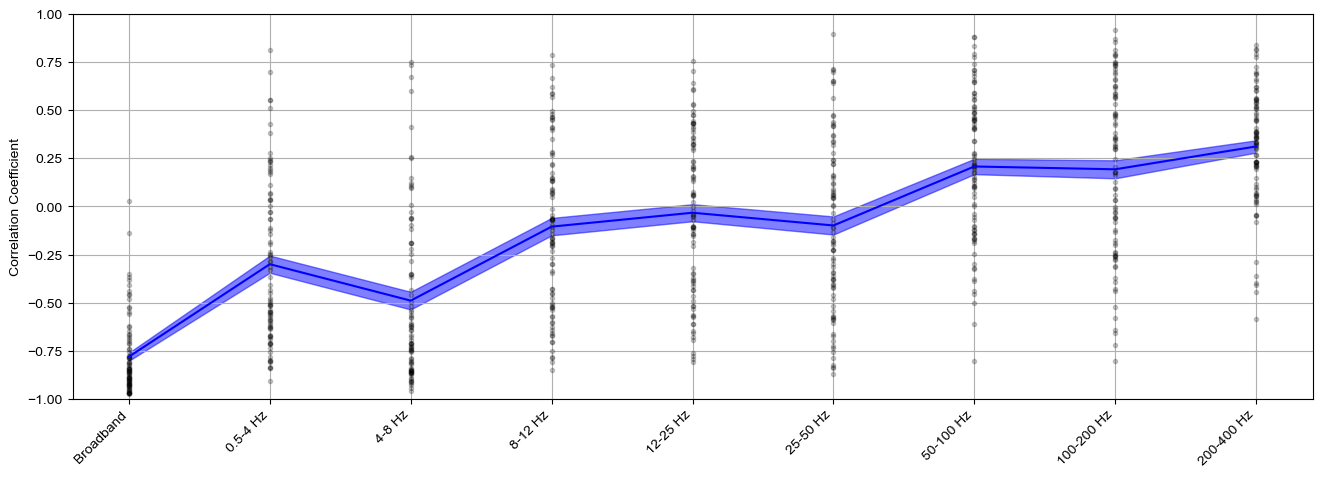

In [61]:
sessions = np.intersect1d(list(avr_attr_trimmed.keys()), list(r2_scores.keys()))
r2_attr_corr = np.zeros((len(sessions), len(bands)+1))

for i, session in enumerate(sessions):
    total_attr = np.nansum(np.abs(avr_attr_trimmed[session]), axis=2)
    this_ses_r = r2_scores[session]
    for bandi in range(len(bands)+1):
        # Remove NaN and infinite values from both arrays
        attr_vals = total_attr[:,bandi]
        r2_vals = this_ses_r[:,bandi]
        valid_mask = (~np.isnan(attr_vals)) & (~np.isinf(attr_vals)) & (~np.isnan(r2_vals)) & (~np.isinf(r2_vals))
        
        if np.sum(valid_mask) > 1:  # Need at least 2 valid points for correlation
            corr, pval = stats.pearsonr(attr_vals[valid_mask], r2_vals[valid_mask])
            r2_attr_corr[i, bandi] = corr
            # if pval < 0.05:
            #     r2_attr_corr[i, bandi] = corr
            # else:
            #     r2_attr_corr[i, bandi] = np.nan
        else:
            r2_attr_corr[i, bandi] = np.nan
            
# plot the results
fig, ax = plt.subplots(1,1, figsize = (16,5))
ax.plot(np.arange(len(bands)+1), r2_attr_corr.T,'.' ,color = 'k', alpha = .2)
ax.plot(np.arange(len(bands)+1), np.nanmean(r2_attr_corr, axis=0), color = 'b')
ax.fill_between(np.arange(len(bands)+1), 
                np.nanmean(r2_attr_corr, axis=0) - stats.sem(r2_attr_corr, axis=0, nan_policy='omit'), 
                np.nanmean(r2_attr_corr, axis=0) + stats.sem(r2_attr_corr, axis=0, nan_policy='omit'),
                alpha = .5, color = 'b'
                )         
ax.set_xticks(np.arange(len(bands)+1))
ax.set_xticklabels(['Broadband'] + [f'{band[0]}-{band[1]} Hz' for band in bands], rotation=45, ha='right')
ax.grid(visible=True)
ax.set_ylabel("Correlation Coefficient")
ax.set_ylim(-1, 1)
plt.savefig(Path(figures_folder) / 'r2_attr_correlation.pdf', bbox_inches='tight')
plt.show()    

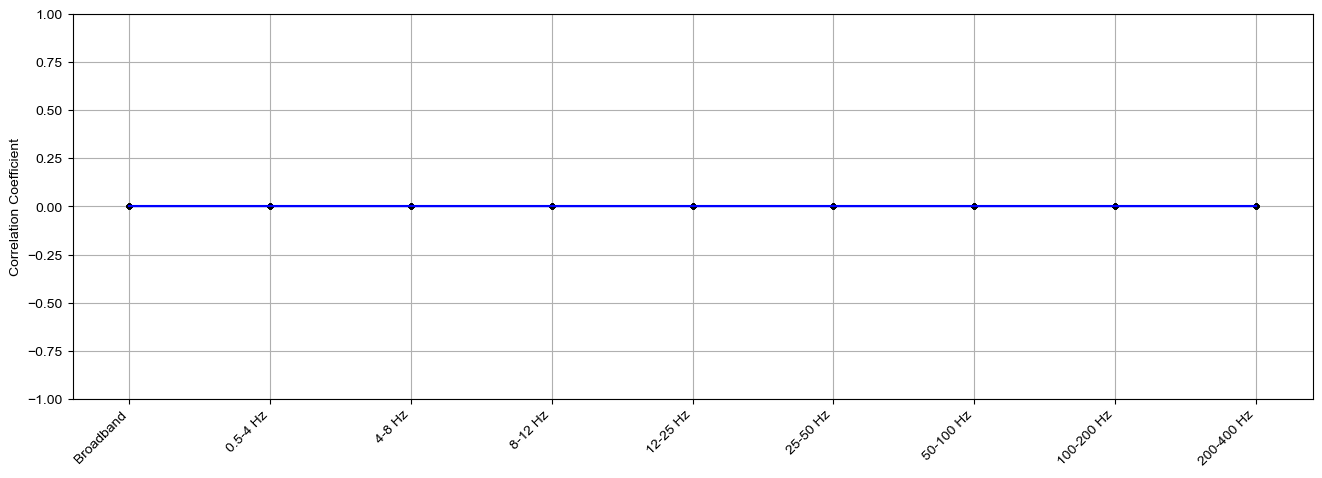

In [62]:
# Now perform weighting to remove correlation
from scipy import stats
avr_attr_weighted = {}
avr_attr_spont_weighted = {}

for session in sessions:
    attr = avr_attr_trimmed[session]
    attr_spont = avr_attr_spont_trimmed[session]
    r2 = r2_scores[session]
    r2_spont = r2_scores_spontaneous[session]
    
    # Initialize weighted arrays
    avr_attr_weighted[session] = np.zeros_like(attr)
    avr_attr_spont_weighted[session] = np.zeros_like(attr_spont)
    
    n_channels, n_bands, n_units = attr.shape
    
    for b_idx in range(n_bands):
        # The independent variable (X) is the R2 vector for this specific band
        x = r2[:, b_idx]  # Shape: (16,) - R2 across channels
        x_spont = r2_spont[:, b_idx]
        
        # Calculate TOTAL attribution per channel (this is what we correlate later)
        total_attr_per_channel = np.nansum(np.abs(attr[:, b_idx, :]), axis=1)  # Shape: (16,)
        total_attr_spont_per_channel = np.nansum(np.abs(attr_spont[:, b_idx, :]), axis=1)
        
        # Check if R2 has variance
        valid_mask = (~np.isnan(total_attr_per_channel)) & (~np.isinf(total_attr_per_channel)) & \
                     (~np.isnan(x)) & (~np.isinf(x))
        valid_mask_spont = (~np.isnan(total_attr_spont_per_channel)) & (~np.isinf(total_attr_spont_per_channel)) & \
                          (~np.isnan(x_spont)) & (~np.isinf(x_spont))
        
        if np.sum(valid_mask) > 1 and np.ptp(x[valid_mask]) > 0:
            # Regress TOTAL attribution against R2 (at the same level we measure correlation)
            slope, intercept, r_val, p_val, std_err = stats.linregress(x[valid_mask], total_attr_per_channel[valid_mask])
            
            # Calculate residuals for total attribution
            y_pred_total = intercept + slope * x
            residuals_total = total_attr_per_channel - y_pred_total
            
            # Add back mean to preserve magnitude
            corrected_total = residuals_total + np.nanmean(total_attr_per_channel[valid_mask])
            
            # Distribute corrected totals back to individual neurons proportionally
            for ch in range(n_channels):
                if valid_mask[ch] and total_attr_per_channel[ch] > 0:
                    # Calculate each neuron's proportion of original total
                    neuron_props = np.abs(attr[ch, b_idx, :]) / total_attr_per_channel[ch]
                    
                    # Distribute corrected total according to proportions, preserving signs
                    for u_idx in range(n_units):
                        original_sign = np.sign(attr[ch, b_idx, u_idx])
                        avr_attr_weighted[session][ch, b_idx, u_idx] = original_sign * neuron_props[u_idx] * corrected_total[ch]
                else:
                    avr_attr_weighted[session][ch, b_idx, :] = attr[ch, b_idx, :]
        else:
            avr_attr_weighted[session][:, b_idx, :] = attr[:, b_idx, :]
            
        # Same for spontaneous
        if np.sum(valid_mask_spont) > 1 and np.ptp(x_spont[valid_mask_spont]) > 0:
            slope_spont, intercept_spont, r_val_spont, p_val_spont, std_err_spont = stats.linregress(
                x_spont[valid_mask_spont], total_attr_spont_per_channel[valid_mask_spont])
            
            y_pred_total_spont = intercept_spont + slope_spont * x_spont
            residuals_total_spont = total_attr_spont_per_channel - y_pred_total_spont
            corrected_total_spont = residuals_total_spont + np.nanmean(total_attr_spont_per_channel[valid_mask_spont])
            
            for ch in range(n_channels):
                if valid_mask_spont[ch] and total_attr_spont_per_channel[ch] > 0:
                    neuron_props_spont = np.abs(attr_spont[ch, b_idx, :]) / total_attr_spont_per_channel[ch]
                    
                    for u_idx in range(n_units):
                        original_sign = np.sign(attr_spont[ch, b_idx, u_idx])
                        avr_attr_spont_weighted[session][ch, b_idx, u_idx] = original_sign * neuron_props_spont[u_idx] * corrected_total_spont[ch]
                else:
                    avr_attr_spont_weighted[session][ch, b_idx, :] = attr_spont[ch, b_idx, :]
        else:
            avr_attr_spont_weighted[session][:, b_idx, :] = attr_spont[:, b_idx, :]
            
# # Now calculate correlation (should be near zero)
r2_weighted_attr_corr = np.zeros((len(sessions), len(bands)+1))
for i, session in enumerate(sessions):
    total_attr = np.nansum(np.abs(avr_attr_weighted[session]), axis=2)  # Sum across neurons
    this_ses_r = r2_scores[session]
    for bandi in range(len(bands)+1):
        attr_vals = total_attr[:, bandi]  # Per channel
        r2_vals = this_ses_r[:, bandi]    # Per channel
        valid_mask = (~np.isnan(attr_vals)) & (~np.isinf(attr_vals)) & (~np.isnan(r2_vals)) & (~np.isinf(r2_vals))
        
        if np.sum(valid_mask) > 1:
            corr, pval = stats.pearsonr(attr_vals[valid_mask], r2_vals[valid_mask])
            r2_weighted_attr_corr[i, bandi] = corr
        else:
            r2_weighted_attr_corr[i, bandi] = np.nan
# plot the results
fig, ax = plt.subplots(1,1, figsize = (16,5))
ax.plot(np.arange(len(bands)+1), r2_weighted_attr_corr.T,'.' ,color = 'k', alpha = .2)
ax.plot(np.arange(len(bands)+1), np.nanmean(r2_weighted_attr_corr, axis=0), color = 'b')    
ax.fill_between(np.arange(len(bands)+1), 
                np.nanmean(r2_weighted_attr_corr, axis=0) - stats.sem(r2_weighted_attr_corr, axis=0, nan_policy='omit'), 
                np.nanmean(r2_weighted_attr_corr, axis=0) + stats.sem(r2_weighted_attr_corr, axis=0, nan_policy='omit'),
                alpha = .5, color = 'b'
                )
ax.set_xticks(np.arange(len(bands)+1))
ax.set_xticklabels(['Broadband'] + [f'{band[0]}-{band[1]} Hz' for band in bands], rotation=45, ha='right')
ax.grid(visible=True)
ax.set_ylabel("Correlation Coefficient")
ax.set_ylim(-1, 1)
plt.savefig(Path(figures_folder) / 'r2_attr_correlation_weighted.pdf', bbox_inches='tight')
plt.show()

## load the spectral r2 scores, saved in csv files with colummns channel_0, channel_1, channel_2 etc and index as frequency bands + broadband


In [56]:
spectral_r2_scores = {}
spectral_r2_cortex = {}
spectral_r2_cortex_no_visp = {}
spectral_r2_hpc = {}
spectral_r2_subcortical = {}

for i, row in borders.iterrows():
    session = row['session']
    if session in visp_depths['session'].unique():
        spectral_r2_file = Path(spectral_r2_scores_path, f'session_{session}_r2_results_full_model.csv')
        spectral_r2_cortex_file = Path(spectral_r2_scores_path, f'session_{session}_r2_results_cortex.csv')
        spectral_r2_cortex_no_visp_file = Path(spectral_r2_scores_path, f'session_{session}_r2_results_cortex_no_visp.csv')
        spectral_r2_hpc_file = Path(spectral_r2_scores_path, f'session_{session}_r2_results_hpc.csv')
        spectral_r2_subcortical_file = Path(spectral_r2_scores_path, f'session_{session}_r2_results_subcortical.csv')
        
        if spectral_r2_file.exists():
            spectral_r2_df = pd.read_csv(spectral_r2_file, index_col=0)
            spectral_r2_cortex_df = pd.read_csv(spectral_r2_cortex_file, index_col=0)
            spectral_r2_cortex_no_visp_df = pd.read_csv(spectral_r2_cortex_no_visp_file, index_col=0)
            spectral_r2_hpc_df = pd.read_csv(spectral_r2_hpc_file, index_col=0)
            spectral_r2_subcortical_df = pd.read_csv(spectral_r2_subcortical_file, index_col=0)
            
            # Handle potential size mismatch
            num_chans_spectral = spectral_r2_df.shape[1]
            num_chans_tbl = len(visp_depths[visp_depths['session'] == session])
            if num_chans_spectral > num_chans_tbl:
                diff = num_chans_spectral - num_chans_tbl
                spectral_r2_df = spectral_r2_df.iloc[:, :-diff]
                spectral_r2_cortex_df = spectral_r2_cortex_df.iloc[:, :-diff]
                spectral_r2_cortex_no_visp_df = spectral_r2_cortex_no_visp_df.iloc[:, :-diff]
                spectral_r2_hpc_df = spectral_r2_hpc_df.iloc[:, :-diff]
                spectral_r2_subcortical_df = spectral_r2_subcortical_df.iloc[:, :-diff]
            
            # Get indices (CORRECTED - no +1)
            start_index = row['start_index']
            first_channel_index = row['first_channel_index']
            last_channel_index = row['last_channel_index']  
            
            # Calculate actual number of channels to copy
            available_channels = spectral_r2_df.shape[1]
            channels_to_copy = last_channel_index - first_channel_index +1
            
            # Ensure we don't exceed source array bounds
            if first_channel_index + channels_to_copy > available_channels:
                channels_to_copy = available_channels - first_channel_index
                
            # Ensure we don't exceed target array bounds  
            if start_index + channels_to_copy > chans2keep:
                channels_to_copy = chans2keep - start_index
            
            # Initialize output arrays
            trimmed = np.full((7, chans2keep), np.nan)
            trimmed_cortex = np.full((7, chans2keep), np.nan)
            trimmed_cortex_no_visp = np.full((7, chans2keep), np.nan)
            trimmed_hpc = np.full((7, chans2keep), np.nan)
            trimmed_subcortical = np.full((7, chans2keep), np.nan)
            
            # Copy the data with bounds checking
            if channels_to_copy > 0:
                trimmed[:, start_index:start_index + channels_to_copy] = \
                    spectral_r2_df.iloc[:, first_channel_index:first_channel_index + channels_to_copy].values
                trimmed_cortex[:, start_index:start_index + channels_to_copy] = \
                    spectral_r2_cortex_df.iloc[:, first_channel_index:first_channel_index + channels_to_copy].values
                trimmed_cortex_no_visp[:, start_index:start_index + channels_to_copy] = \
                    spectral_r2_cortex_no_visp_df.iloc[:, first_channel_index:first_channel_index + channels_to_copy].values
                trimmed_hpc[:, start_index:start_index + channels_to_copy] = \
                    spectral_r2_hpc_df.iloc[:, first_channel_index:first_channel_index + channels_to_copy].values
                trimmed_subcortical[:, start_index:start_index + channels_to_copy] = \
                    spectral_r2_subcortical_df.iloc[:, first_channel_index:first_channel_index + channels_to_copy].values
            
            spectral_r2_scores[session] = trimmed
            spectral_r2_cortex[session] = trimmed_cortex
            spectral_r2_cortex_no_visp[session] = trimmed_cortex_no_visp
            spectral_r2_hpc[session] = trimmed_hpc
            spectral_r2_subcortical[session] = trimmed_subcortical

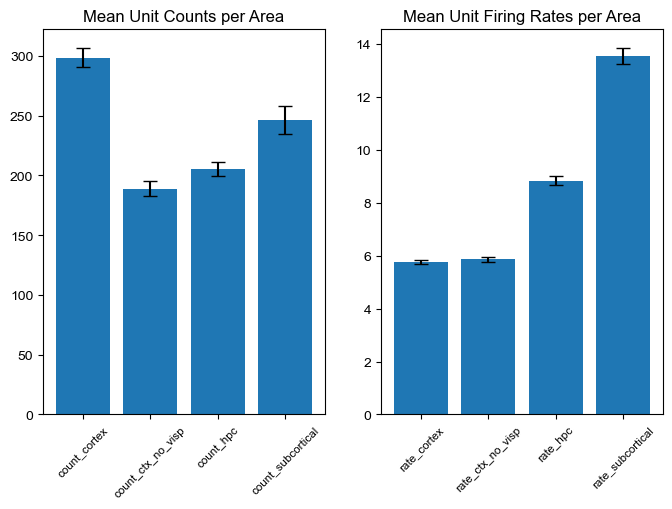

In [60]:
# for each session, load the unit count and avg firing rate per area
# initizlize a dataframe with sessions as index, and columns: count_cortex, count_ctx_no_visp, count_hpc,
#  count_subcortical, rate_cortex, rate_ctx_no_visp rate_hpc, rate_subcortical
area_unit_stats = pd.DataFrame(columns=[
    'count_cortex', 'count_ctx_no_visp', 'count_hpc', 'count_subcortical',
    'rate_cortex', 'rate_ctx_no_visp', 'rate_hpc', 'rate_subcortical'
], index=all_ses)

for session in all_ses:
    ses_df_path = Path(spectral_r2_scores_path, f'session_{session}_units_counts_and_rates.csv')
    if ses_df_path.exists():
        ses_df = pd.read_csv(ses_df_path, index_col=0)
        area_unit_stats.at[session, 'count_cortex'] = ses_df.loc['cortex', 'num_units']
        area_unit_stats.at[session, 'count_ctx_no_visp'] = ses_df.loc['cortex_no_visp', 'num_units']
        area_unit_stats.at[session, 'count_hpc'] = ses_df.loc['hippocampus', 'num_units']
        area_unit_stats.at[session, 'count_subcortical'] = ses_df.loc['subcortical', 'num_units']
        area_unit_stats.at[session, 'rate_cortex'] = ses_df.loc['cortex', 'mean_firing_rate']
        area_unit_stats.at[session, 'rate_ctx_no_visp'] = ses_df.loc['cortex_no_visp', 'mean_firing_rate']
        area_unit_stats.at[session, 'rate_hpc'] = ses_df.loc['hippocampus', 'mean_firing_rate']
        area_unit_stats.at[session, 'rate_subcortical'] = ses_df.loc['subcortical', 'mean_firing_rate']
        
# print(area_unit_stats.head())

# compute the mean count and rate per area across sessions
mean_area_unit_stats = area_unit_stats.mean() # type: ignore
std_area_unit_stats = area_unit_stats.std() / np.sqrt(area_unit_stats.count()) # type: ignore
# print(mean_area_unit_stats)
# print(std_area_unit_stats)

# plot the mean and std of unit counts and rates per area as a bar plot with error bars
fig, axs = plt.subplots(1, 2, figsize=(8, 5))
axs[0].bar(mean_area_unit_stats.index[:4], mean_area_unit_stats.values[:4], yerr=std_area_unit_stats.values[:4], capsize=5)
axs[0].set_title('Mean Unit Counts per Area')
axs[0].tick_params(axis='x', rotation=45, labelsize='small')
axs[1].bar(mean_area_unit_stats.index[4:], mean_area_unit_stats.values[4:], yerr=std_area_unit_stats.values[4:], capsize=5)
axs[1].set_title('Mean Unit Firing Rates per Area')
axs[1].tick_params(axis='x', rotation=45, labelsize='small')
plt.savefig(Path(figures_folder) / 'unit_counts_and_rates_per_area.pdf', bbox_inches='tight')
plt.show()

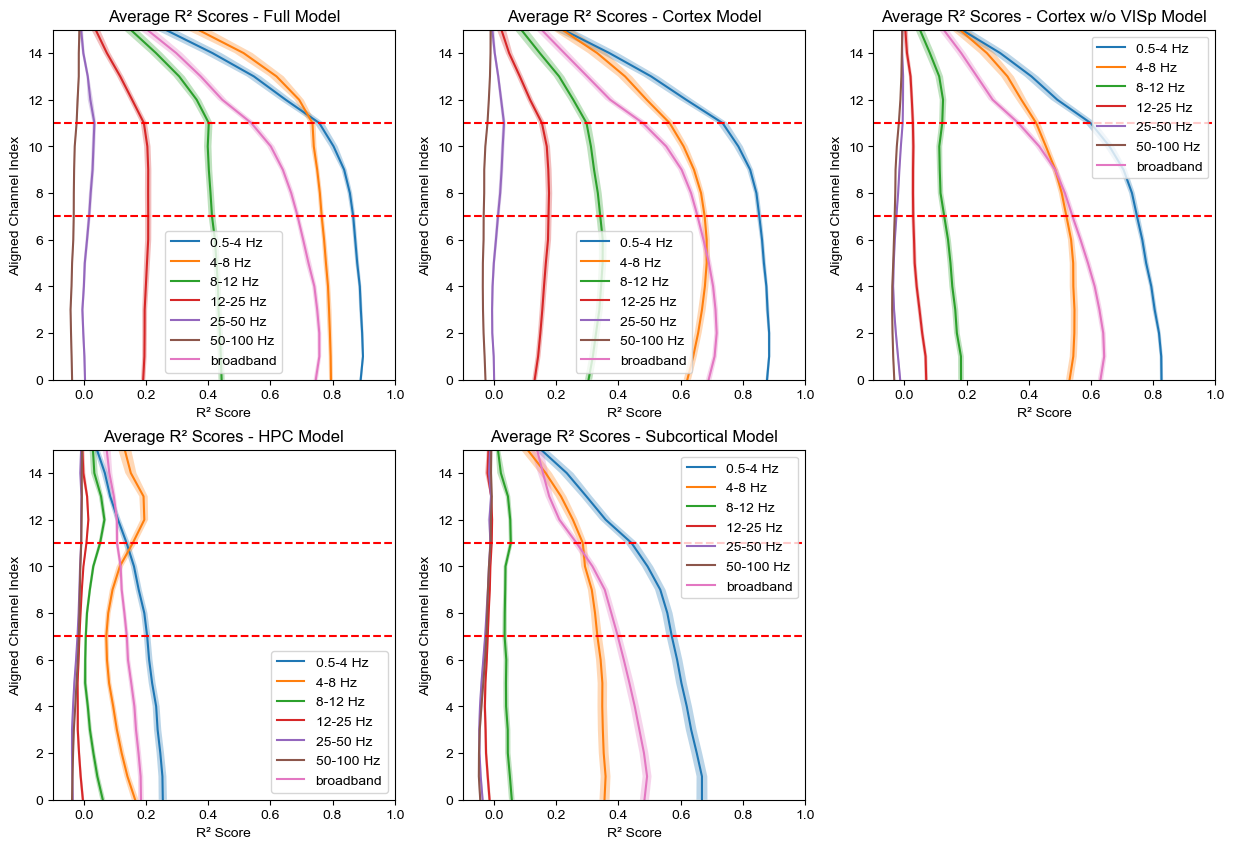

In [58]:
r2_full_all = np.zeros((len(spectral_r2_scores), 7,chans2keep))
for i, r2 in enumerate(spectral_r2_scores.items()):
    r2_full_all[i,:,:] = r2[1]
r2_avg = np.nanmean(r2_full_all, axis=0)
r2_avg_se = stats.sem(r2_full_all, axis=0, nan_policy='omit')

r2_cortex_all = np.zeros((len(spectral_r2_cortex), 7,chans2keep))
for i, r2 in enumerate(spectral_r2_cortex.items()):
    r2_cortex_all[i,:,:] = r2[1]
r2_cortex_avg = np.nanmean(r2_cortex_all, axis=0)
r2_cortex_avg_se = stats.sem(r2_cortex_all, axis=0, nan_policy='omit')

r2_cortex_no_visp_all = np.zeros((len(spectral_r2_cortex_no_visp), 7,chans2keep))
for i, r2 in enumerate(spectral_r2_cortex_no_visp.items()):
    r2_cortex_no_visp_all[i,:,:] = r2[1]
r2_cortex_no_visp_avg = np.nanmean(r2_cortex_no_visp_all, axis=0)
r2_cortex_no_visp_avg_se = stats.sem(r2_cortex_no_visp_all, axis=0, nan_policy='omit')

r2_hpc_all = np.zeros((len(spectral_r2_hpc), 7,chans2keep))
for i, r2 in enumerate(spectral_r2_hpc.items()):
    r2_hpc_all[i,:,:] = r2[1]
r2_hpc_avg = np.nanmean(r2_hpc_all, axis=0)
r2_hpc_avg_se = stats.sem(r2_hpc_all, axis=0, nan_policy='omit')

r2_subcortical_all = np.zeros((len(spectral_r2_subcortical), 7,chans2keep))
for i, r2 in enumerate(spectral_r2_subcortical.items()):
    r2_subcortical_all[i,:,:] = r2[1]
r2_subcortical_avg = np.nanmean(r2_subcortical_all, axis=0)
r2_subcortical_avg_se = stats.sem(r2_subcortical_all, axis=0, nan_policy='omit')

# for each model (full, cortex, cortex w/o visp, hpc, subcortical), plot the average r2 scores for each frequency band (0.5-4 Hz, 4-8 Hz, 8-12 Hz
#12-25 Hz, 25-50 Hz, 50-100 Hz, broadband) the shape of the r2_avg is (7, chans2keep)
frequency_band_names = ['0.5-4 Hz', '4-8 Hz', '8-12 Hz', '12-25 Hz', '25-50 Hz', '50-100 Hz', 'broadband']
channel_indices = np.arange(chans2keep)
models = ['Full Model', 'Cortex Model', 'Cortex w/o VISp Model', 'HPC Model', 'Subcortical Model']
plt.figure(figsize=(15,10))
for i in range(len(models)):
    plt.subplot(2,3,i+1)
    if models[i] == 'Full Model':
        r2_avg_plot = r2_avg
        r2_se_plot = r2_avg_se
    elif models[i] == 'Cortex Model':
        r2_avg_plot = r2_cortex_avg
        r2_se_plot = r2_cortex_avg_se
    elif models[i] == 'Cortex w/o VISp Model':
        r2_avg_plot = r2_cortex_no_visp_avg
        r2_se_plot = r2_cortex_no_visp_avg_se
    elif models[i] == 'HPC Model':
        r2_avg_plot = r2_hpc_avg
        r2_se_plot = r2_hpc_avg_se
    elif models[i] == 'Subcortical Model':
        r2_avg_plot = r2_subcortical_avg
        r2_se_plot = r2_subcortical_avg_se
        
    for j in range(r2_avg_plot.shape[0]):
        plt.plot( r2_avg_plot[j,:], channel_indices, label=frequency_band_names[j])
        plt.fill_betweenx(channel_indices, 
                         r2_avg_plot[j,:] - r2_se_plot[j,:],
                         r2_avg_plot[j,:] + r2_se_plot[j,:],
                         alpha=0.3)
    plt.title(f'Average R² Scores - {models[i]}')
    plt.axhline(y=11, color='r', linestyle='--')
    plt.axhline(y=7, color='r', linestyle='--')
    plt.ylabel('Aligned Channel Index')
    plt.ylim(0, chans2keep-1)
    plt.xlabel('R² Score')
    plt.xlim(-0.1, 1)
    plt.legend()
    
plt.savefig(Path(figures_folder) / 'r2_scores_spectral.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()


## Average r2 scores across all sessions


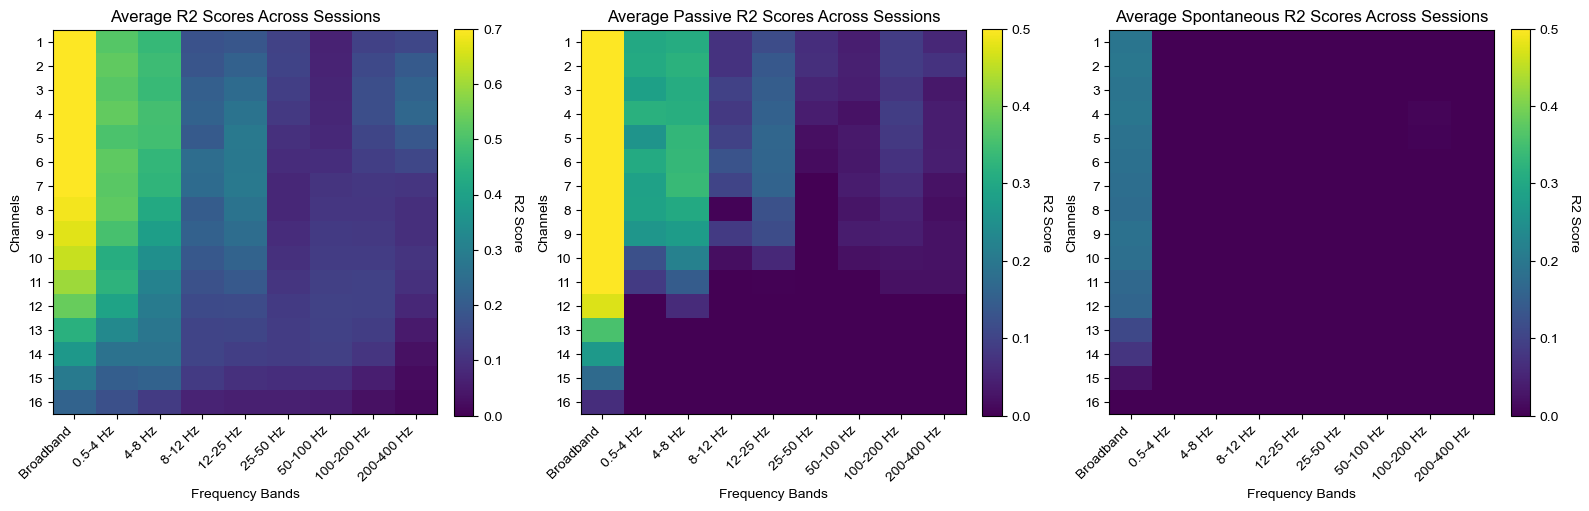

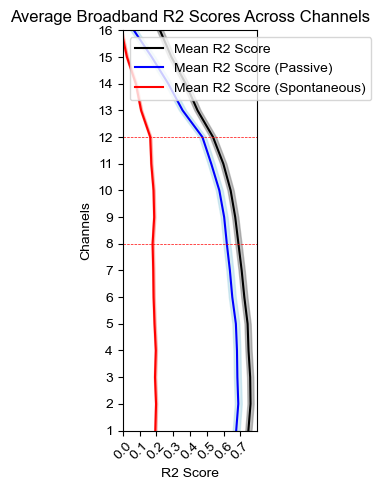

In [68]:
r2_avg = np.zeros((len(r2_scores) ,chans2keep, len(bands)+1))
for i, r2 in enumerate(r2_scores.items()):
    r2_avg[i,:,:] = r2[1]
r2_avg = np.nanmean(r2_avg, axis=0)

r2_passive_avg = np.zeros((len(r2_scores_passive) ,chans2keep, len(bands)+1))
for i, r2 in enumerate(r2_scores_passive.items()):
    r2_passive_avg[i,:,:] = r2[1]
r2_passive_avg = np.nanmean(r2_passive_avg, axis=0)

r2_spont_avg = np.zeros((len(r2_scores_spontaneous) ,chans2keep, len(bands)+1))
for i, r2 in enumerate(r2_scores_spontaneous.items()):
    r2_spont_avg[i,:,:] = r2[1]
r2_spont_avg = np.nanmean(r2_spont_avg, axis=0)

# plot the average r2 scores
fig, ax = plt.subplots(1, 3, figsize=(16, 10))
ax[0].imshow(r2_avg, aspect='auto', cmap='viridis', vmin=0, vmax=.7)
ax[0].set_title('Average R2 Scores Across Sessions')
ax[0].set_xlabel('Frequency Bands')
ax[0].set_ylabel('Channels')
ax[0].set_xticks(np.arange(len(bands)+1))
ax[0].set_xticklabels(['Broadband'] + [f'{band[0]}-{band[1]} Hz' for band in bands], rotation=45, ha='right')
ax[0].set_yticks(np.arange(chans2keep))
ax[0].set_yticklabels(np.arange(1, chans2keep + 1), rotation=0)
ax[0].set_aspect(1.0/ax[0].get_data_ratio(), adjustable='box')
cbar = plt.colorbar(ax[0].images[0], ax=ax[0], orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('R2 Score', rotation=270, labelpad=15)

ax[1].imshow(r2_passive_avg, aspect='auto', cmap='viridis', vmin=0, vmax=.5)
ax[1].set_title('Average Passive R2 Scores Across Sessions')
ax[1].set_xlabel('Frequency Bands')
ax[1].set_ylabel('Channels')
ax[1].set_xticks(np.arange(len(bands)+1))
ax[1].set_xticklabels(['Broadband'] + [f'{band[0]}-{band[1]} Hz' for band in bands], rotation=45, ha='right')
ax[1].set_yticks(np.arange(chans2keep))
ax[1].set_yticklabels(np.arange(1, chans2keep + 1), rotation=0)
ax[1].set_aspect(1.0/ax[1].get_data_ratio(), adjustable='box')
cbar = plt.colorbar(ax[1].images[0], ax=ax[1], orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('R2 Score', rotation=270, labelpad=15)

ax[2].imshow(r2_spont_avg, aspect='auto', cmap='viridis', vmin=0, vmax=.5)
ax[2].set_title('Average Spontaneous R2 Scores Across Sessions')
ax[2].set_xlabel('Frequency Bands')
ax[2].set_ylabel('Channels')
ax[2].set_xticks(np.arange(len(bands)+1))
ax[2].set_xticklabels(['Broadband'] + [f'{band[0]}-{band[1]} Hz' for band in bands], rotation=45, ha='right')
ax[2].set_yticks(np.arange(chans2keep))
ax[2].set_yticklabels(np.arange(1, chans2keep + 1), rotation=0)
ax[2].set_aspect(1.0/ax[2].get_data_ratio(), adjustable='box')
cbar = plt.colorbar(ax[2].images[0], ax=ax[2], orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('R2 Score', rotation=270, labelpad=15)
plt.savefig(Path(figures_folder) / 'average_r2_scores_across_sessions.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

# add a plot for just the broadband r2 scores across channels with mean and std shading
mean_r2_broadband = r2_avg[:,0]
sem_r2_broadband = np.nanstd(r2_avg[:,0], axis=0) / np.sqrt(len(r2_scores))
mean_r2_passive = r2_passive_avg[:,0]
sem_r2_passive = np.nanstd(r2_passive_avg[:,0], axis=0) / np.sqrt(len(r2_scores_passive))
mean_r2_spont = r2_spont_avg[:,0]
sem_r2_spont = np.nanstd(r2_spont_avg[:,0], axis=0) / np.sqrt(len(r2_scores_spontaneous))


fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(mean_r2_broadband, np.arange(1, chans2keep + 1), 'k-', label='Mean R2 Score')
ax.fill_betweenx(np.arange(1, chans2keep + 1),
                mean_r2_broadband - sem_r2_broadband,
                mean_r2_broadband + sem_r2_broadband,
                color='gray', alpha=0.5)

ax.plot(mean_r2_passive, np.arange(1, chans2keep + 1), 'b-', label='Mean R2 Score (Passive)')
ax.fill_betweenx(np.arange(1, chans2keep + 1),
                mean_r2_passive - sem_r2_passive,
                mean_r2_passive + sem_r2_passive,
                color='lightblue', alpha=0.5)
ax.plot(mean_r2_spont, np.arange(1, chans2keep + 1), 'r-', label='Mean R2 Score (Spontaneous)')
ax.fill_betweenx(np.arange(1, chans2keep + 1),
                mean_r2_spont - sem_r2_spont,
                mean_r2_spont + sem_r2_spont,
                color='salmon', alpha=0.5)

ax.set_aspect(3.0/ax.get_data_ratio(), adjustable='box')
ax.set_xlim(0, 0.8)
ax.set_ylim(1, chans2keep)
ax.set_title('Average Broadband R2 Scores Across Channels')
ax.set_ylabel('Channels')
ax.set_xlabel('R2 Score')
ax.set_xticks(np.arange(0, 0.8, 0.1))
ax.set_xticklabels([f'{x:.1f}' for x in np.arange(0, 0.8, 0.1)], rotation=45)
ax.set_yticks(np.arange(1, chans2keep + 1))
ax.axhline(8, color='r', linestyle='--', linewidth=0.5)
ax.axhline(12, color='r', linestyle='--', linewidth=0.5)
ax.legend()
plt.tight_layout()
plt.savefig(Path(figures_folder) / 'average_broadband_r2_scores_across_channels.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

## Import, trim and plot ablation experiments R2 results

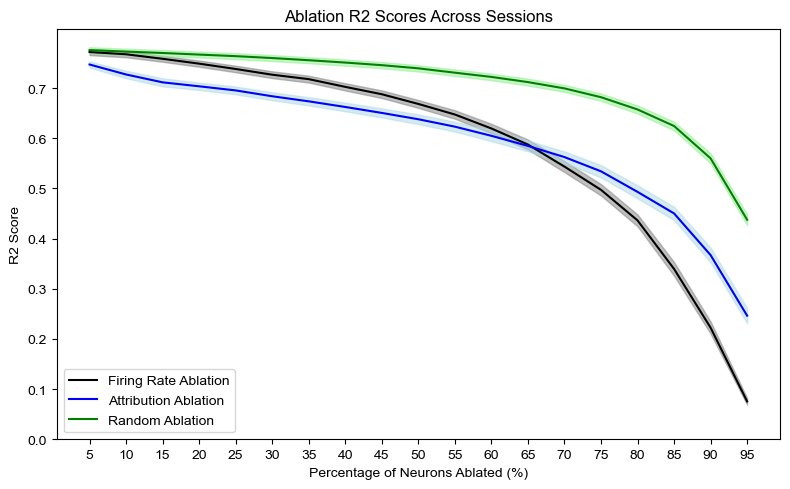

In [16]:
steps = np.arange(5,100,5)

# collect per-session vectors in lists, then stack into arrays
r2_scores_fr = []
r2_scores_attr = []
r2_scores_rand = []

for i, row in borders.iterrows():
    session = row['session']
    if session in visp_depths['session'].unique():
        r2_file_fr = Path(r2_scores_path) / f'{session}_r2_scores_fr.npy'
        r2_file_attr = Path(r2_scores_path) / f'{session}_r2_scores_attr.npy'
        r2_file_rand = Path(r2_scores_path) / f'{session}_r2_scores_rand.npy'

        if r2_file_fr.exists():
            r2 = np.load(r2_file_fr)
            r2_attr = np.load(r2_file_attr)
            r2_rand = np.load(r2_file_rand)
            r2_rand = np.mean(r2_rand, axis=1)  # average across random permutations

            # ensure 1D arrays before appending
            r2_scores_fr.append(np.asarray(r2).squeeze().reshape(-1))
            r2_scores_attr.append(np.asarray(r2_attr).squeeze().reshape(-1))
            r2_scores_rand.append(np.asarray(r2_rand).squeeze().reshape(-1))

# convert lists to 2D arrays: shape (n_sessions, len(steps))
def stack_or_empty(lst, n_steps):
    if len(lst) == 0:
        return np.empty((0, n_steps))
    return np.vstack([np.asarray(x).reshape(1, -1) for x in lst])

r2_scores_fr_arr = stack_or_empty(r2_scores_fr, len(steps))
r2_scores_attr_arr = stack_or_empty(r2_scores_attr, len(steps))
r2_scores_rand_arr = stack_or_empty(r2_scores_rand, len(steps))

# get the mean and standard error across sessions and plot
if r2_scores_fr_arr.shape[0] > 0:
    r2_fr_mean = np.mean(r2_scores_fr_arr, axis=0)
    r2_fr_sem = np.std(r2_scores_fr_arr, axis=0) / np.sqrt(r2_scores_fr_arr.shape[0])
else:
    r2_fr_mean = np.full(len(steps), np.nan)
    r2_fr_sem = np.full(len(steps), np.nan)

if r2_scores_attr_arr.shape[0] > 0:
    r2_attr_mean = np.mean(r2_scores_attr_arr, axis=0)
    r2_attr_sem = np.std(r2_scores_attr_arr, axis=0) / np.sqrt(r2_scores_attr_arr.shape[0])
else:
    r2_attr_mean = np.full(len(steps), np.nan)
    r2_attr_sem = np.full(len(steps), np.nan)

if r2_scores_rand_arr.shape[0] > 0:
    r2_rand_mean = np.mean(r2_scores_rand_arr, axis=0)
    r2_rand_sem = np.std(r2_scores_rand_arr, axis=0) / np.sqrt(r2_scores_rand_arr.shape[0])
else:
    r2_rand_mean = np.full(len(steps), np.nan)
    r2_rand_sem = np.full(len(steps), np.nan)


# plot 
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(steps, r2_fr_mean, 'k-', label='Firing Rate Ablation')
ax.fill_between(steps,
                r2_fr_mean - r2_fr_sem,
                r2_fr_mean + r2_fr_sem,
                color='gray', alpha=0.5)    
ax.plot(steps, r2_attr_mean, 'b-', label='Attribution Ablation')
ax.fill_between(steps,
                r2_attr_mean - r2_attr_sem,
                r2_attr_mean + r2_attr_sem,
                color='lightblue', alpha=0.5)
ax.plot(steps, r2_rand_mean, 'g-', label='Random Ablation')
ax.fill_between(steps,
                r2_rand_mean - r2_rand_sem,
                r2_rand_mean + r2_rand_sem,
                color='lightgreen', alpha=0.5)
ax.set_title('Ablation R2 Scores Across Sessions')
ax.set_xlabel('Percentage of Neurons Ablated (%)')
ax.set_ylabel('R2 Score')
ax.set_xticks(steps)
ax.set_yticks(np.arange(0, 0.8, 0.1))
ax.legend()
plt.tight_layout()
plt.savefig(Path(figures_folder) / 'ablation_r2_scores_across_sessions.pdf', format='pdf', dpi=300, bbox_inches='tight')  
plt.show()

## Add the mean attribution to the dataframe, remove areas with few neurons and rename areas

In [8]:
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
# remove rows from df that of units that are not in list(avr_attr_weighted.keys()) ie the sessions we have attribution scores for
df = df[df['session_id'].isin(avr_attr_weighted.keys())]

# loop through the sessions and for each channel from 0-15 and each band from 0-8 add the atttribution scores to the units_all dataframe
for session, attr in avr_attr_weighted.items():
    attr_spont = avr_attr_spont_weighted[session]
    for chan in range(chans2keep):
        for band in range(len(bands)+1):
            attr_values = attr[chan, band, :]
            attr_spont_values = attr_spont[chan, band, :]
            # Store raw attribution values
            df.loc[df['session_id'] == session, f'attr_{chan}_{band}'] = attr_values
            df.loc[df['session_id'] == session, f'attr_spont_{chan}_{band}'] = attr_spont_values

            # Calculate inverse ranks for attribution values
            # Use absolute values for ranking, handle NaN values
            abs_attr_values = np.abs(attr_values)
            abs_attr_spont_values = np.abs(attr_spont_values)
            
            # Create masks for valid (non-NaN) values
            valid_mask_attr = ~np.isnan(abs_attr_values)
            valid_mask_spont = ~np.isnan(abs_attr_spont_values)
            
            # Initialize rank arrays with NaN
            attr_inv_ranks = np.full_like(attr_values, np.nan, dtype=float)
            attr_spont_inv_ranks = np.full_like(attr_spont_values, np.nan, dtype=float)
            
            # Calculate inverse ranks only for valid values
            if np.sum(valid_mask_attr) > 0:
                # Get ranks (1 = highest attribution, n = lowest attribution)
                # scipy.stats.rankdata with method='min' handles ties by giving the minimum rank
                from scipy.stats import rankdata
                ranks = rankdata(-abs_attr_values[valid_mask_attr], method='min')  # Negative for descending order
                # Convert to inverse ranks (highest attribution gets highest inverse rank)
                n_valid = len(ranks)
                inv_ranks = n_valid - ranks + 1
                attr_inv_ranks[valid_mask_attr] = inv_ranks
            
            if np.sum(valid_mask_spont) > 0:
                ranks_spont = rankdata(-abs_attr_spont_values[valid_mask_spont], method='min')
                n_valid_spont = len(ranks_spont)
                inv_ranks_spont = n_valid_spont - ranks_spont + 1
                attr_spont_inv_ranks[valid_mask_spont] = inv_ranks_spont
            
            # Store inverse rank values
            df.loc[df['session_id'] == session, f'attr_inv_rank_{chan}_{band}'] = attr_inv_ranks
            df.loc[df['session_id'] == session, f'attr_spont_inv_rank_{chan}_{band}'] = attr_spont_inv_ranks            
            
        
unique_areas = df['structure_acronym'].unique()
# remove from unique_areas 'root', 'CA2','RR', 'VISrll', 'RN', 'FF', 'grey', 'PRE', 'HY', 'IGL', 'DT', 'SSp', 'VPLpc', 'SPFp', 'HPF', 'VIS'
areas2remove = ['root', 'CA2', 'RR', 'VISrll', 'RN', 'FF', 'grey', 'PRE',
                                                              'HY', 'IGL', 'DT', 'SSp', 'VPLpc', 'SPFp', 'HPF', 
                                                              'VIS','SNr','SNc', 'PP', 'TH']

unique_areas = [area for area in unique_areas if area not in areas2remove]
unique_areas = sorted(unique_areas)
print(f'Unique areas: {unique_areas}')

# create a 3D numpy array to hold the grand mean for each area, channel and band
grand_mean               = np.zeros((len(unique_areas),len(bands)+1, chans2keep))
grand_mean_spont         = np.zeros_like(grand_mean)
grand_sem                = np.zeros_like(grand_mean)
grand_sem_spont          = np.zeros_like(grand_mean)
grand_inv_rank           = np.zeros_like(grand_mean)
grand_inv_rank_sem       = np.zeros_like(grand_mean)
grand_inv_rank_spont     = np.zeros_like(grand_mean)
grand_inv_rank_spont_sem = np.zeros_like(grand_mean)

# loop through the unique areas and for each area, channel and band, calculate the grand mean
for i, area in enumerate(unique_areas):
    for chan in range(chans2keep):
        for band in range(len(bands)+1):
            # get the mean of the attribution scores for the area, channel and band, ignoring NaN values
            all_vals = df.loc[df['structure_acronym'] == area, f'attr_{chan}_{band}'].values
            all_vals = np.abs(all_vals)
            grand_mean[i, band, chan] = np.nanmean(all_vals)
            grand_sem[i, band, chan]  = stats.sem(all_vals, nan_policy='omit')
            
            all_vals_rank = df.loc[df['structure_acronym'] == area, f'attr_inv_rank_{chan}_{band}'].values
            grand_inv_rank[i, band, chan] = np.nanmean(all_vals_rank)
            grand_inv_rank_sem[i, band, chan]  = stats.sem(all_vals_rank, nan_policy='omit')
            
            all_vals_spont = df.loc[df['structure_acronym'] == area, f'attr_spont_{chan}_{band}'].values
            all_vals_spont = np.abs(all_vals_spont)
            grand_mean_spont[i, band, chan] = np.nanmean(all_vals_spont)
            grand_sem_spont[i, band, chan]  = stats.sem(all_vals_spont, nan_policy='omit')

            all_vals_rank_spont = df.loc[df['structure_acronym'] == area, f'attr_spont_inv_rank_{chan}_{band}'].values
            grand_inv_rank_spont[i, band, chan] = np.nanmean(all_vals_rank_spont)
            grand_inv_rank_spont_sem[i, band, chan]  = stats.sem(all_vals_rank_spont, nan_policy='omit')            
            
            
area_count = dict(zip(unique_areas, np.zeros(len(unique_areas))))
# for each session if it includes an area, increment the count for that area
sessions = list(avr_attr_trimmed.keys())
for session in sessions:
    areas = df.loc[df['session_id'] == session, 'structure_acronym'].unique()
    for area in areas:
        if area in area_count:
            area_count[area] += 1

print(f'Area count: {area_count}')

# make a dataframe with areas as columns, sessions as index and the count of sessions for each area
unit_counts = pd.DataFrame(index=sessions, columns=unique_areas)
for session in sessions:
    areas = df.loc[df['session_id'] == session, 'structure_acronym'].unique()
    for area in areas:
        if area in unique_areas:
            unit_counts.at[session, area] = len(df.loc[(df['session_id'] == session) & (df['structure_acronym'] == area)])
            
unit_counts.head()

Unique areas: ['APN', 'CA1', 'CA3', 'DG', 'Eth', 'LG', 'LP', 'LT', 'MB', 'MG', 'MRN', 'NB', 'NOT', 'PIL', 'POL', 'POST', 'PPT', 'PoT', 'ProS', 'SC', 'SGN', 'SUB', 'VISal', 'VISam', 'VISl', 'VISp', 'VISpm', 'VISrl', 'ZI']
Area count: {'APN': 79.0, 'CA1': 88.0, 'CA3': 80.0, 'DG': 87.0, 'Eth': 11.0, 'LG': 47.0, 'LP': 68.0, 'LT': 9.0, 'MB': 75.0, 'MG': 73.0, 'MRN': 60.0, 'NB': 28.0, 'NOT': 40.0, 'PIL': 40.0, 'POL': 46.0, 'POST': 52.0, 'PPT': 14.0, 'PoT': 52.0, 'ProS': 43.0, 'SC': 34.0, 'SGN': 58.0, 'SUB': 57.0, 'VISal': 86.0, 'VISam': 85.0, 'VISl': 83.0, 'VISp': 88.0, 'VISpm': 88.0, 'VISrl': 85.0, 'ZI': 16.0}


,APN,CA1,CA3,DG,Eth,LG,LP,LT,MB,MG,...,SC,SGN,SUB,VISal,VISam,VISl,VISp,VISpm,VISrl,ZI
1047969464,45,150,26,21,NaN,14,NaN,NaN,22,65,...,NaN,NaN,33,67,58,65,21,49,65,33
1048189115,45,121,29,20,NaN,16,NaN,NaN,17,62,...,18,NaN,NaN,43,67,35,49,44,45,19
1049273528,61,97,11,19,NaN,NaN,NaN,5,48,74,...,NaN,NaN,7,32,51,15,81,38,40,NaN
1049514117,43,110,2,58,NaN,NaN,21,NaN,24,65,...,NaN,16,NaN,56,70,5,78,35,46,NaN
1051155866,66,139,9,23,NaN,3,1,NaN,9,NaN,...,13,32,11,21,23,24,75,59,31,9


## For each area, calculate the avergae attribution score for in each session for each channel and band


In [ ]:
# warnings.filterwarnings("ignore", category=RuntimeWarning)
# area_attr = {}
# area_attr_spont = {}
# # for each session if it includes an area, increment the count for that area
# sessions = list(avr_attr_trimmed.keys())
# for session in sessions:
#     areas = df.loc[df['session_id'] == session, 'structure_acronym'].unique()
#     for area in areas:
#         if area in unique_areas:
#             if area not in area_attr.keys():
#                 area_attr[area] = np.full((chans2keep, len(bands)+1, len(sessions)), np.nan)
#                 area_attr_spont[area] = np.full((chans2keep, len(bands)+1, len(sessions)), np.nan)
#             # get the attribution scores for the area, channel and band
#             for chan in range(chans2keep):
#                 for band in range(len(bands)+1):
#                     all_vals = df.loc[(df['session_id'] == session) & (df['structure_acronym'] == area), [f'attr_{chan}_{band}']].values
#                     all_vals = np.abs(all_vals)
#                     if all_vals.size > 0:
#                         area_attr[area][chan, band, sessions.index(session)] = np.nanmean(all_vals)
#                     all_vals_spont = df.loc[(df['session_id'] == session) & (df['structure_acronym'] == area), [f'attr_spont_{chan}_{band}']].values
#                     all_vals_spont = np.abs(all_vals_spont)
#                     if all_vals_spont.size > 0:
#                         area_attr_spont[area][chan, band, sessions.index(session)] = np.nanmean(all_vals_spont)

# # create a 3D numpy array to hold the grand mean for each area, channel and band, only for sessions with more than 10 units in the area                        
# grand_mean_sessions = np.zeros((len(unique_areas), len(bands)+1, chans2keep))
# # for each area, calculate the grand mean for each channel and band
# for i, area in enumerate(unique_areas):
#     for chan in range(chans2keep):
#         for band in range(len(bands)+1):
#             # make a mask for sessions with more than 10 units in the area
#             mask = unit_counts[area] > 10 
#             # get the mean of the attribution scores for the area, channel and band, ignoring NaN values
#             grand_mean_sessions[i, band, chan] = np.nanmean(area_attr[area][chan, band, mask])

# Plot the distribution of attribution scores for LG, VISp and CA1 for an example broadband channel

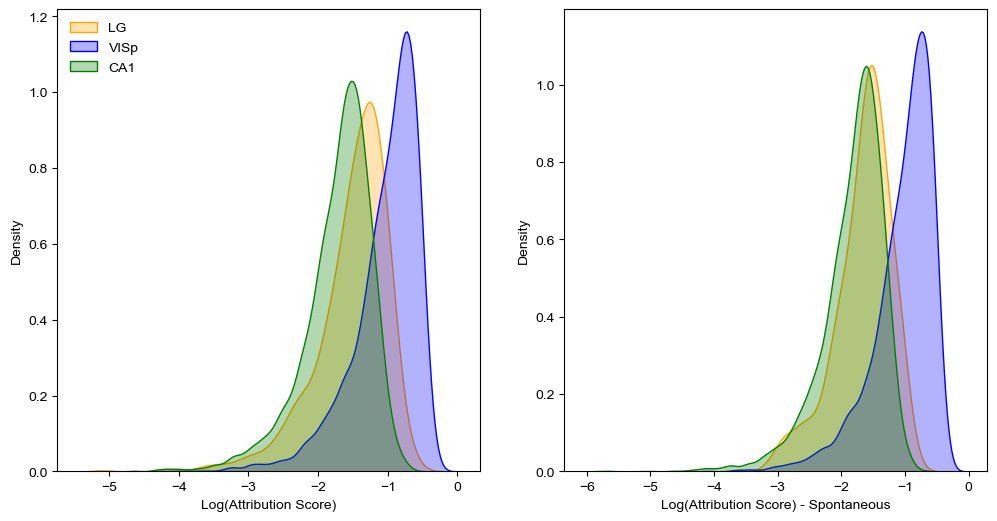

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

bandi = 0
chani = 5

# LG
all_vals = df.loc[(df['structure_acronym'] == 'LG'), [f'attr_{chani}_{bandi}']].values.ravel()
all_vals = all_vals[~np.isnan(all_vals) & ~np.isinf(all_vals)]
all_vals = np.abs(all_vals)
all_vals = all_vals[all_vals > 0]  # Remove zeros and negatives
sns.kdeplot(ax=ax[0], x=np.log10(all_vals), alpha=0.3, label='LG', fill=True, color='orange')

all_vals_spont = df.loc[(df['structure_acronym'] == 'NOT'), [f'attr_spont_{chani}_{bandi}']].values.ravel()
all_vals_spont = all_vals_spont[~np.isnan(all_vals_spont) & ~np.isinf(all_vals_spont)]
all_vals_spont = np.abs(all_vals_spont)
all_vals_spont = all_vals_spont[all_vals_spont > 0]  # Remove zeros and negatives
sns.kdeplot(ax=ax[1], x=np.log10(all_vals_spont), alpha=0.3, label='NOT', fill=True, color='orange')

# VISp
all_vals = df.loc[(df['structure_acronym'] == 'VISp'), [f'attr_{chani}_{bandi}']].values.ravel()
all_vals = all_vals[~np.isnan(all_vals) & ~np.isinf(all_vals)]
all_vals = np.abs(all_vals)
all_vals = all_vals[all_vals > 0]  # Remove zeros and negatives
sns.kdeplot(ax=ax[0], x=np.log10(all_vals), alpha=0.3, label='VISp', fill=True, color='blue')

all_vals_spont = df.loc[(df['structure_acronym'] == 'VISp'), [f'attr_spont_{chani}_{bandi}']].values.ravel()
all_vals_spont = all_vals_spont[~np.isnan(all_vals_spont) & ~np.isinf(all_vals_spont)]
all_vals_spont = np.abs(all_vals_spont)
all_vals_spont = all_vals_spont[all_vals_spont > 0]  # Remove zeros and negatives
sns.kdeplot(ax=ax[1], x=np.log10(all_vals_spont), alpha=0.3, label='VISp', fill=True, color='blue')
# CA1
all_vals = df.loc[(df['structure_acronym'] == 'CA1'), [f'attr_{chani}_{bandi}']].values.ravel()
all_vals = all_vals[~np.isnan(all_vals) & ~np.isinf(all_vals)]
all_vals = np.abs(all_vals)
all_vals = all_vals[all_vals > 0]  # Remove zeros and negatives
sns.kdeplot(ax=ax[0], x=np.log10(all_vals), alpha=0.3, label='CA1', fill=True, color='green')

all_vals_spont = df.loc[(df['structure_acronym'] == 'CA1'), [f'attr_spont_{chani}_{bandi}']].values.ravel()
all_vals_spont = all_vals_spont[~np.isnan(all_vals_spont) & ~np.isinf(all_vals_spont)]
all_vals_spont = np.abs(all_vals_spont)
all_vals_spont = all_vals_spont[all_vals_spont > 0]  # Remove zeros and negatives
sns.kdeplot(ax=ax[1], x=np.log10(all_vals_spont), alpha=0.3, label='CA1', fill=True, color='green')

ax[0].set_xlabel('Log(Attribution Score)')
ax[0].set_ylabel('Density')
ax[0].legend(frameon=False) # without frame
ax[1].set_xlabel('Log(Attribution Score) - Spontaneous')
ax[1].set_ylabel('Density')

plt.savefig(Path(figures_folder) / 'attribution_score_distributions_LGN_VISp_CA1.pdf', 
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

## Plot the grand mean for each band 


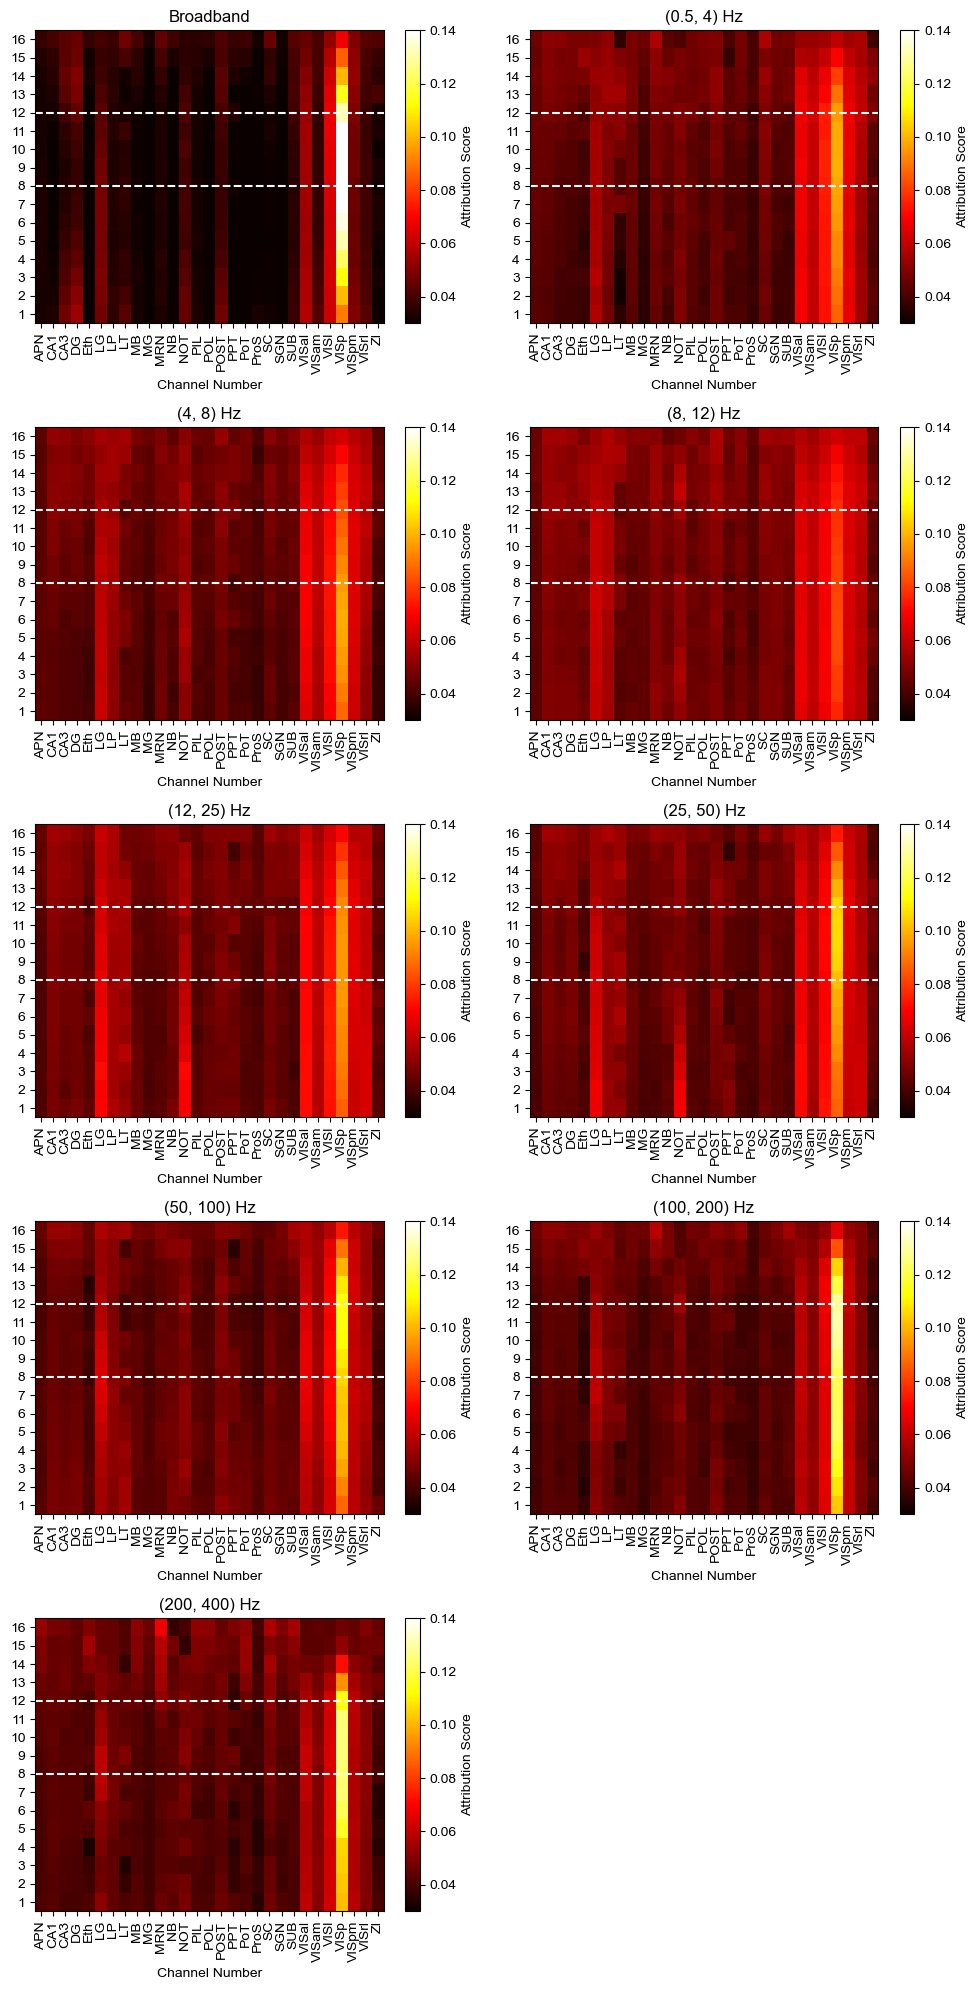

In [40]:
from scipy.interpolate import interp1d

def smooth_x_only(arr, factor=10, kind='linear'):
    """
    Upsample only the x-axis (axis=1) of a 2D array.
    arr: shape (y, x)
    factor: upsampling factor
    """
    ny, nx = arr.shape
    x_old = np.arange(nx)
    x_new = np.linspace(0, nx - 1, nx * factor)

    f = interp1d(x_old, arr, kind=kind, axis=1)
    return f(x_new), x_new

bands = [(0.5, 4), (4, 8), (8, 12), (12, 25), (25, 50), (50, 100), (100, 200), (200, 400)]
fig, ax = plt.subplots(int(np.ceil((len(bands)+1)/2)), 2, figsize=(10, 20))

for bandi in range(len(bands)+1):
    ax.flat[bandi].imshow(grand_mean[:,bandi,:].T , aspect='auto', cmap='hot', vmin=0.03, vmax=0.14)
    ax.flat[bandi].set_yticks(range(16))
    ax.flat[bandi].set_yticklabels(range(1, 17))
    ax.flat[bandi].set_xticks(range(len(unique_areas)))
    ax.flat[bandi].set_xticklabels(unique_areas, rotation=90)
    ax.flat[bandi].set_xlabel('Area')
    # flip the y-axis so that channel 1 is at the bottom and channel 16 is at the top
    ax.flat[bandi].invert_yaxis()
    if bandi == 0:
        ax.flat[bandi].set_title('Broadband')
    else:
        ax.flat[bandi].set_title(str(bands[bandi-1]) + ' Hz')
        
    # plot vertical lines at 7.5 and 10.5 to separate deep, middle and superficial channels
    ax.flat[bandi].axhline(y=7, color='w', linestyle='--')
    ax.flat[bandi].axhline(y=11, color='w', linestyle='--')
    # add colorbar
    cbar = plt.colorbar(ax.flat[bandi].images[0], ax=ax.flat[bandi], orientation='vertical')
    cbar.set_label('Attribution Score')
    ax.flat[bandi].set_xlabel('Channel Number')
    
plt.tight_layout()
fig.delaxes(ax.flat[-1])
plt.savefig(Path(figures_folder) / 'grand_mean_attribution_scores_across_areas_channels_bands.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

# smoothing_factor = 1

# for bandi in range(len(bands)+1):
#     # --- smooth only the x direction ---
#     data = grand_mean[:, bandi, :]              # shape: (areas, channels)
#     data_smooth, x_new = smooth_x_only(data, factor=smoothing_factor, kind='linear')

#     ax.flat[bandi].imshow(
#         data_smooth,
#         aspect='auto',
#         cmap='hot',
#         interpolation='nearest'   # prevents y-direction smoothing
#     )

#     num_channels = data.shape[1]  # Original number of channels (16)
    
#     # Center ticks: (channel_index + 0.5) * smoothing_factor
#     tick_positions = (np.arange(num_channels) + 0.5) * smoothing_factor
#     ax.flat[bandi].set_xticks(tick_positions)
#     ax.flat[bandi].set_xticklabels(range(num_channels))

#     ax.flat[bandi].set_yticks(range(len(unique_areas)))
#     ax.flat[bandi].set_yticklabels(unique_areas)
#     ax.flat[bandi].set_ylabel('Area')

#     if bandi == 0:
#         ax.flat[bandi].set_title('Broadband')
#     else:
#         ax.flat[bandi].set_title(str(bands[bandi-1]) + ' Hz')

#     # vertical lines (scaled to new x-grid) - also center these
#     ax.flat[bandi].axvline(x=7 * smoothing_factor, color='w', linestyle='--')
#     ax.flat[bandi].axvline(x=11 * smoothing_factor, color='w', linestyle='--')

#     # colorbar
#     cbar = plt.colorbar(ax.flat[bandi].images[0], ax=ax.flat[bandi], orientation='vertical')
#     cbar.set_label('Attribution Score')
#     ax.flat[bandi].set_xlabel('Channel Number')
# plt.tight_layout()
# fig.delaxes(ax.flat[-1])
# plt.savefig(Path(figures_folder) / 'grand_mean_attribution_scores_across_areas_channels_bands.pdf', format='pdf', dpi=300, bbox_inches='tight')
# plt.show()

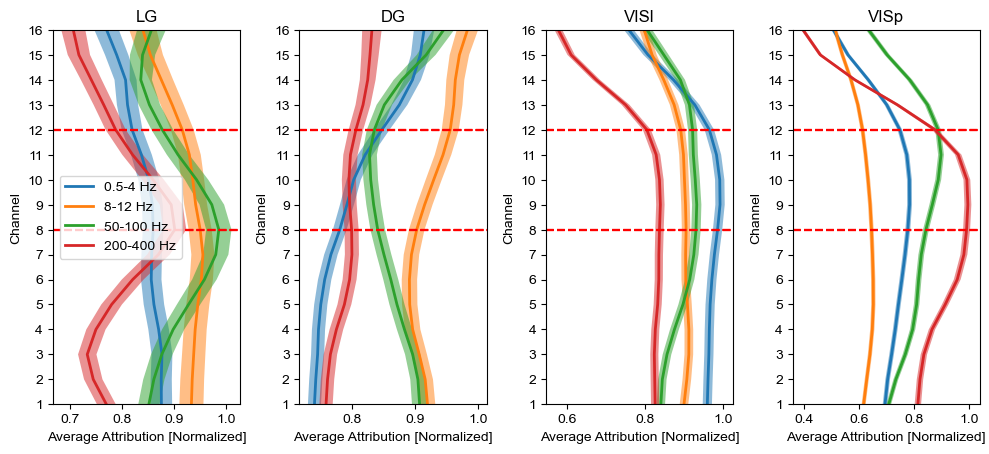

In [22]:
# for selected areas, plot the average attribution across all frequencies and channels
from scipy.ndimage import gaussian_filter1d
# areas2plot = ["LG", "CA1", "VISal", "VISam", "VISl", "VISp", "VISpm", "VISrl"]
areas2plot = ["LG", "DG", "VISl", "VISp"]
bands2plot = [1,3,6,8] # 0.5-4, 8-12 Hz, 50-100 Hz, 200-400 Hz
# fig, ax = plt.subplots(int(len(areas2plot)/2), 2, figsize=(10,20))
fig, ax = plt.subplots(1, 4, figsize=(10,20))

for i,areai in enumerate(areas2plot):
        
        max_val = np.max(grand_mean[unique_areas.index(areai),bands2plot,:])
        
        for bandi in range(len(bands2plot)):
                band_tuple = bands[bands2plot[bandi]-1]
                band_label = f"{band_tuple[0]}-{band_tuple[1]} Hz"
                
                ax.flat[i].plot(gaussian_filter1d(grand_mean[unique_areas.index(areai),
                                                        bands2plot[bandi],:],sigma=1)/max_val, channel_indices, linewidth = 2,
                                label = band_label)
                ax.flat[i].fill_betweenx(channel_indices,
                        gaussian_filter1d(grand_mean[unique_areas.index(areai),bands2plot[bandi],:]/max_val, 
                                        sigma=1) - gaussian_filter1d(grand_sem[unique_areas.index(areai),bands2plot[bandi],:]/max_val, sigma=1),
                        gaussian_filter1d(grand_mean[unique_areas.index(areai),bands2plot[bandi],:]/max_val, 
                                        sigma=1) + gaussian_filter1d(grand_sem[unique_areas.index(areai),bands2plot[bandi],:]/max_val, sigma=1),
                        alpha=0.5)  
                if i == 0:
                        ax.flat[i].legend()
                ax.flat[i].set_title(areai)
                ax.flat[i].set_ylabel("Channel")
                ax.flat[i].set_xlabel("Average Attribution [Normalized]")
                ax.flat[i].set_yticks(channel_indices)
                ax.flat[i].set_yticklabels(channel_indices + 1)
                ax.flat[i].axhline(y=11, color='r', linestyle='--')
                ax.flat[i].axhline(y=7, color='r', linestyle='--')
                ax.flat[i].set_ylim(0, chans2keep-1)
                ax.flat[i].set_aspect(2.0/ax.flat[i].get_data_ratio(), adjustable='box')

plt.tight_layout()
# plt.savefig(Path(figures_folder) / 'average_attribution_scores_selected_areas.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

## Plot the grand mean of spontaneous activity for each band 


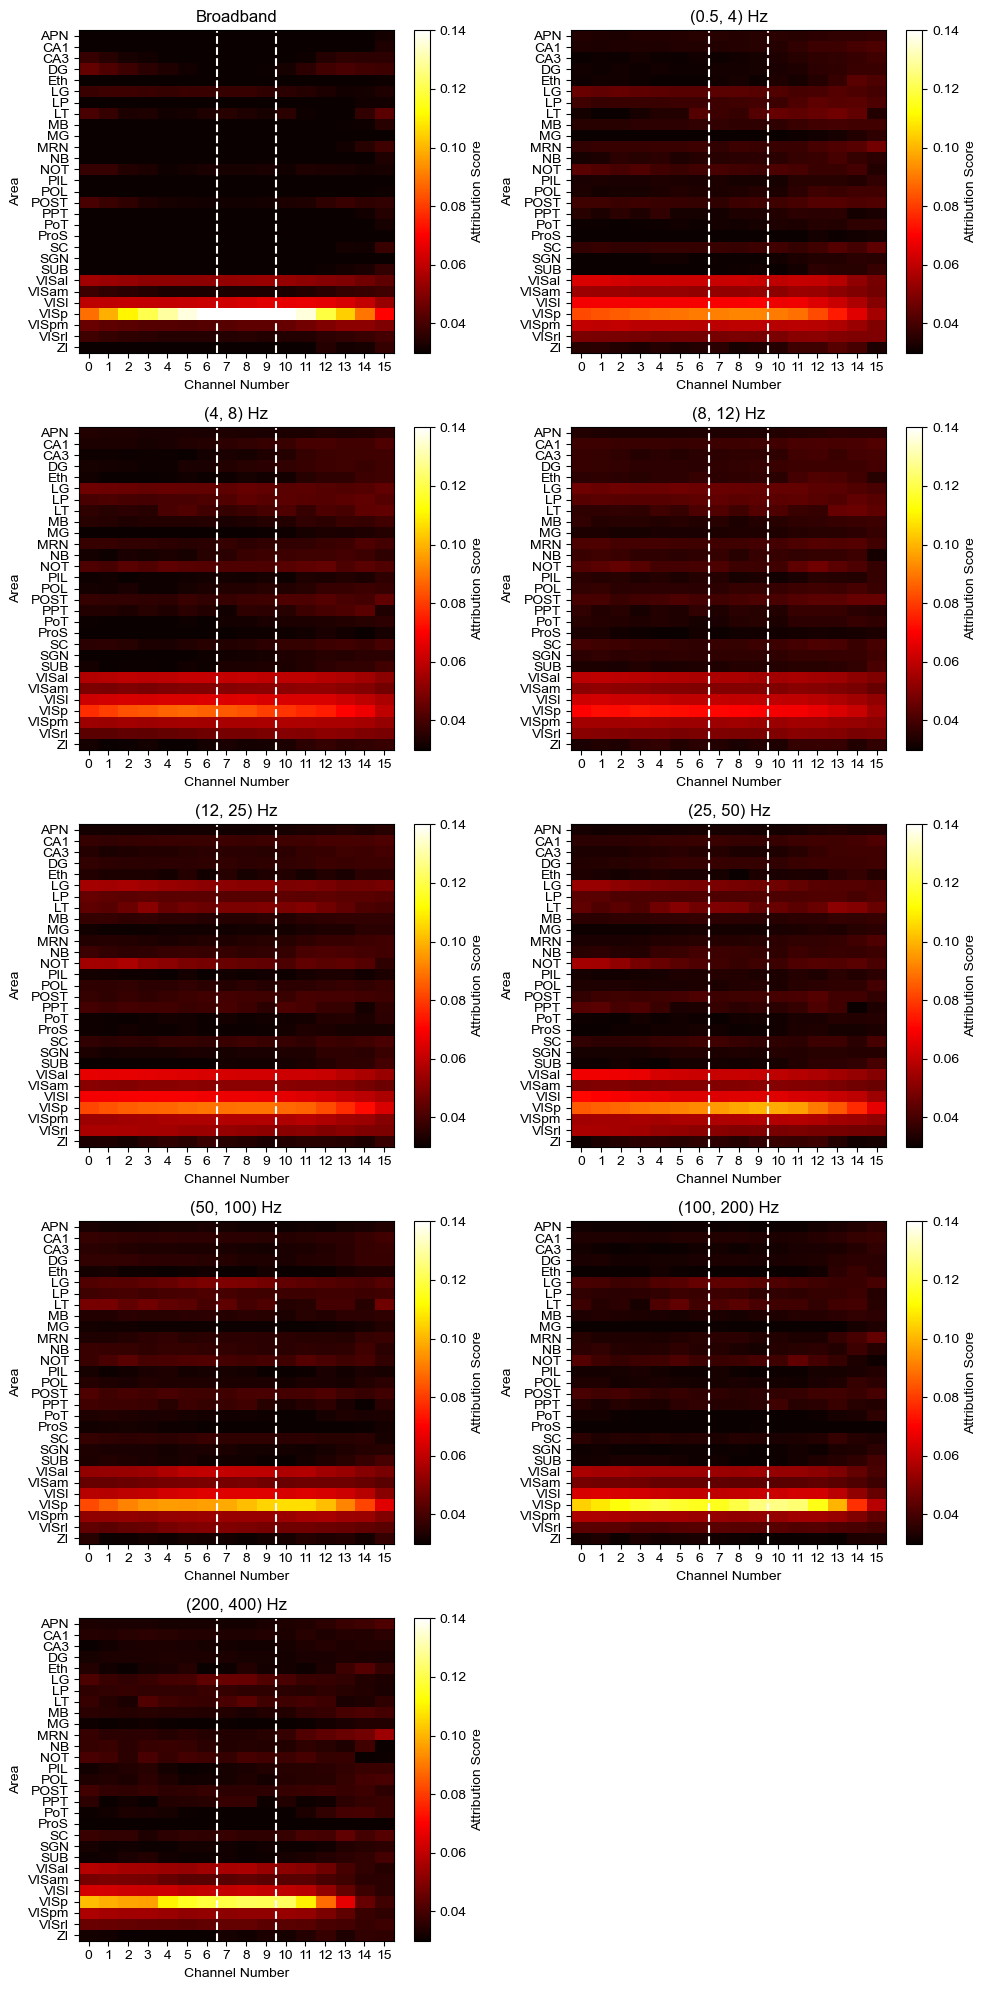

In [ ]:
bands = [(0.5, 4), (4, 8), (8, 12), (12, 25), (25, 50), (50, 100), (100, 200), (200, 400)]
fig, ax = plt.subplots(int(np.ceil((len(bands)+1)/2)),2,figsize=(10,20))
for bandi in range(len(bands)+1):
    ax.flat[bandi].imshow(grand_mean_spont[:,bandi,:] , aspect='auto', cmap='hot', vmin=0.03, vmax=0.14)
    ax.flat[bandi].set_xticks(range(16))
    ax.flat[bandi].set_yticks(range(len(unique_areas)))
    ax.flat[bandi].set_yticklabels(unique_areas)
    ax.flat[bandi].set_ylabel('Area')
    if bandi == 0:
        ax.flat[bandi].set_title('Broadband')
    else:
        ax.flat[bandi].set_title(str(bands[bandi-1]) + ' Hz')
        
    # plot vertical lines at 7.5 and 10.5 to separate deep, middle and superficial channels
    ax.flat[bandi].axvline(x=6.5, color='w', linestyle='--')
    ax.flat[bandi].axvline(x=9.5, color='w', linestyle='--')
    # add colorbar
    cbar = plt.colorbar(ax.flat[bandi].images[0], ax=ax.flat[bandi], orientation='vertical')
    cbar.set_label('Attribution Score')
    ax.flat[bandi].set_xlabel('Channel Number')
    
plt.tight_layout()
fig.delaxes(ax.flat[-1])
plt.savefig(Path(figures_folder) / 'grand_mean_attribution_scores_across_areas_channels_bands.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

## Load stimulus PSTH for all sessions

In [ ]:
stim_psth = {}

for i, row in borders.iterrows():
    session = row['session']
    if session in visp_depths['session'].unique():
        psth_file = Path(stim_psth_path) / f'{session}_psth.npy'
        if psth_file.exists():
            psth = np.load(psth_file)
            psth_locs = df['structure_acronym'][(df['session_id'] == session)].values
            psth_locs[(psth_locs == 'LGd')  | (psth_locs == 'LGv')] = 'LG'
            psth_locs[(psth_locs == 'MGv')  | (psth_locs == 'MGd') | (psth_locs == 'MGm')] = 'MG'
            psth_locs[(psth_locs == 'SCig')  | (psth_locs == 'SCiw')] = 'SC'
            stim_psth[session] = { 'psth': psth, 'locs': psth_locs }
            
# Aggregate stimulus PSTH by region across sessions
stim_psth_by_region = {}

# First, collect all unique region names across sessions from PSTH data
all_psth_regions = set()
for session_data in stim_psth.values():
    all_psth_regions.update(session_data['locs'])

all_psth_regions = sorted(list(all_psth_regions))  # Sort for consistency
print(f"Found {len(all_psth_regions)} unique regions in PSTH data: {all_psth_regions}")

# remove areas that are not in unique_areas
all_psth_regions = [region for region in all_psth_regions if region in unique_areas]
print(f"Filtered to {len(all_psth_regions)} regions present in unique_areas: {all_psth_regions}")

# Initialize dictionaries for each region
for region in all_psth_regions:
    stim_psth_by_region[region] = []

# Aggregate PSTH data by region across all sessions
for session, session_data in stim_psth.items():
    psth = session_data['psth']  # shape: (n_units, n_timebins)
    locs = session_data['locs']  # array of region names for each unit
    
    # For each unique region in this session, collect all units from that region
    for region in np.unique(locs):
        if region in all_psth_regions:  # Safety check
            # Find units belonging to this region
            region_mask = locs == region
            region_psth = psth[region_mask, :]  # shape: (n_units_in_region, n_timebins)
            
            # Add each unit's PSTH to the region's list
            for unit_psth in region_psth:
                stim_psth_by_region[region].append(unit_psth)

# Convert lists to numpy arrays for easier analysis
# Final shape will be (n_units_across_sessions, n_timebins)
for region in all_psth_regions:
    if len(stim_psth_by_region[region]) > 0:
        stim_psth_by_region[region] = np.stack(stim_psth_by_region[region], axis=0)
        
        print(f"Region '{region}': {stim_psth_by_region[region].shape[0]} units across sessions")
    else:
        # Handle regions with no data
        stim_psth_by_region[region] = np.array([])
        print(f"Region '{region}': No data found")            

In [ ]:
# for each session, load the unit count and avg firing rate per area
# initizlize a dataframe with sessions as index, and columns: count_cortex, count_ctx_no_visp, count_hpc,
#  count_subcortical, rate_cortex, rate_ctx_no_visp rate_hpc, rate_subcortical
area_unit_stats = pd.DataFrame(columns=[
    'count_cortex', 'count_ctx_no_visp', 'count_hpc', 'count_subcortical',
    'rate_cortex', 'rate_ctx_no_visp', 'rate_hpc', 'rate_subcortical'
], index=all_ses)

for session in all_ses:
    ses_df_path = Path(spectral_r2_scores_path, f'session_{session}_units_counts_and_rates.csv')
    if ses_df_path.exists():
        ses_df = pd.read_csv(ses_df_path, index_col=0)
        area_unit_stats.at[session, 'count_cortex'] = ses_df.loc['cortex', 'num_units']
        area_unit_stats.at[session, 'count_ctx_no_visp'] = ses_df.loc['cortex_no_visp', 'num_units']
        area_unit_stats.at[session, 'count_hpc'] = ses_df.loc['hippocampus', 'num_units']
        area_unit_stats.at[session, 'count_subcortical'] = ses_df.loc['subcortical', 'num_units']
        area_unit_stats.at[session, 'rate_cortex'] = ses_df.loc['cortex', 'mean_firing_rate']
        area_unit_stats.at[session, 'rate_ctx_no_visp'] = ses_df.loc['cortex_no_visp', 'mean_firing_rate']
        area_unit_stats.at[session, 'rate_hpc'] = ses_df.loc['hippocampus', 'mean_firing_rate']
        area_unit_stats.at[session, 'rate_subcortical'] = ses_df.loc['subcortical', 'mean_firing_rate']
        
# print(area_unit_stats.head())

# compute the mean count and rate per area across sessions
mean_area_unit_stats = area_unit_stats.mean() # type: ignore
std_area_unit_stats = area_unit_stats.std()
# print(mean_area_unit_stats)
# print(std_area_unit_stats)

# plot the mean and std of unit counts and rates per area as a bar plot with error bars
fig, axs = plt.subplots(1, 2, figsize=(8, 5))
axs[0].bar(mean_area_unit_stats.index[:4], mean_area_unit_stats.values[:4], yerr=std_area_unit_stats.values[:4], capsize=5)
axs[0].set_title('Mean Unit Counts per Area')
axs[0].tick_params(axis='x', rotation=45, labelsize='small')
axs[1].bar(mean_area_unit_stats.index[4:], mean_area_unit_stats.values[4:], yerr=std_area_unit_stats.values[4:], capsize=5)
axs[1].set_title('Mean Unit Firing Rates per Area')
axs[1].tick_params(axis='x', rotation=45, labelsize='small')
plt.show()

In [ ]:
# for each session, load the unit count and avg firing rate per area
# initizlize a dataframe with sessions as index, and columns: count_cortex, count_ctx_no_visp, count_hpc,
#  count_subcortical, rate_cortex, rate_ctx_no_visp rate_hpc, rate_subcortical
area_unit_stats = pd.DataFrame(columns=[
    'count_cortex', 'count_ctx_no_visp', 'count_hpc', 'count_subcortical',
    'rate_cortex', 'rate_ctx_no_visp', 'rate_hpc', 'rate_subcortical'
], index=all_ses)

for session in all_ses:
    ses_df_path = Path(spectral_r2_scores_path, f'session_{session}_units_counts_and_rates.csv')
    if ses_df_path.exists():
        ses_df = pd.read_csv(ses_df_path, index_col=0)
        area_unit_stats.at[session, 'count_cortex'] = ses_df.loc['cortex', 'num_units']
        area_unit_stats.at[session, 'count_ctx_no_visp'] = ses_df.loc['cortex_no_visp', 'num_units']
        area_unit_stats.at[session, 'count_hpc'] = ses_df.loc['hippocampus', 'num_units']
        area_unit_stats.at[session, 'count_subcortical'] = ses_df.loc['subcortical', 'num_units']
        area_unit_stats.at[session, 'rate_cortex'] = ses_df.loc['cortex', 'mean_firing_rate']
        area_unit_stats.at[session, 'rate_ctx_no_visp'] = ses_df.loc['cortex_no_visp', 'mean_firing_rate']
        area_unit_stats.at[session, 'rate_hpc'] = ses_df.loc['hippocampus', 'mean_firing_rate']
        area_unit_stats.at[session, 'rate_subcortical'] = ses_df.loc['subcortical', 'mean_firing_rate']
        
# print(area_unit_stats.head())

# compute the mean count and rate per area across sessions
mean_area_unit_stats = area_unit_stats.mean() # type: ignore
std_area_unit_stats = area_unit_stats.std()
# print(mean_area_unit_stats)
# print(std_area_unit_stats)

# plot the mean and std of unit counts and rates per area as a bar plot with error bars
fig, axs = plt.subplots(1, 2, figsize=(8, 5))
axs[0].bar(mean_area_unit_stats.index[:4], mean_area_unit_stats.values[:4], yerr=std_area_unit_stats.values[:4], capsize=5)
axs[0].set_title('Mean Unit Counts per Area')
axs[0].tick_params(axis='x', rotation=45, labelsize='small')
axs[1].bar(mean_area_unit_stats.index[4:], mean_area_unit_stats.values[4:], yerr=std_area_unit_stats.values[4:], capsize=5)
axs[1].set_title('Mean Unit Firing Rates per Area')
axs[1].tick_params(axis='x', rotation=45, labelsize='small')
plt.show()

## Stimulus referenced regional dominance analysis 

In [ ]:
regional_dominance_trimmed = {}

for i, row in borders.iterrows():
    session = row['session']
    if session in visp_depths['session'].unique():
        r2_file = Path(regional_dominance_path) / f'{session}_regional_dominance_results.npz'
        if r2_file.exists():
            data = np.load(r2_file)
            regional_dominance = data['average_dominance'] # shape (num_regions, timepoints, channels)
            proportional_influence = data['proportional_influence'] # shape (num_regions, timepoints, channels)
            region_names = data['region_names']
            region_names[(region_names == 'LGd')  | (region_names == 'LGv')]  = 'LG'
            region_names[(region_names == 'MGv')  | (region_names == 'MGd') | (region_names == 'MGm')] = 'MG'
            region_names[(region_names == 'SCig')  | (region_names == 'SCiw')] = 'SC'
            
            # trim the regional_dominance and proportional_influence arrays according to the borders
            num_chans_ipd = regional_dominance.shape[2]
            num_chans_tbl = len(visp_depths[visp_depths['session'] == session])
            if num_chans_ipd > num_chans_tbl:
                diff = num_chans_ipd - num_chans_tbl
                regional_dominance = regional_dominance[:, :, :-diff]
                proportional_influence = proportional_influence[:, :, :-diff]
                
            start_index = row['start_index']
            first_channel_index = row['first_channel_index']
            last_channel_index = row['last_channel_index']
            available_channels = regional_dominance.shape[2]
            channels_to_copy = last_channel_index - first_channel_index + 1
            
            if first_channel_index + channels_to_copy > available_channels:
                channels_to_copy = available_channels - first_channel_index
                
            # Ensure we don't exceed target array bounds  
            if start_index + channels_to_copy > chans2keep:
                channels_to_copy = chans2keep - start_index
                
            trimmed_regional_dominance = np.full((len(region_names), regional_dominance.shape[1], chans2keep), np.nan)
            trimmed_proportional_influence = np.full((len(region_names), proportional_influence.shape[1], chans2keep), np.nan)
            if channels_to_copy > 0:
                trimmed_regional_dominance[:, :, start_index:start_index + channels_to_copy] = \
                    regional_dominance[:, :, first_channel_index:first_channel_index + channels_to_copy]
                trimmed_proportional_influence[:, :, start_index:start_index + channels_to_copy] = \
                    proportional_influence[:, :, first_channel_index:first_channel_index + channels_to_copy]
            
            regional_dominance_trimmed[session] = {
                'regional_dominance': trimmed_regional_dominance,
                'proportional_influence': trimmed_proportional_influence,
                'region_names': region_names }
            

In [ ]:
# Aggregate regional dominance and proportional influence by region across sessions
regional_dominance_by_region = {}
proportional_influence_by_region = {}

# First, collect all unique region names across sessions
all_region_names = set()
for session_data in regional_dominance_trimmed.values():
    all_region_names.update(session_data['region_names'])

all_region_names = sorted(list(all_region_names))  # Sort for consistency
print(f"Found {len(all_region_names)} unique regions: {all_region_names}")

# only keep regions that are in unique_areas from previous analysis
all_region_names = [region for region in all_region_names if region in unique_areas]
print(f"Filtered to {len(all_region_names)} regions present in unique_areas: {all_region_names}")

# Initialize dictionaries for each region
for region in all_region_names:
    regional_dominance_by_region[region] = []
    proportional_influence_by_region[region] = []

# Aggregate data by region across all sessions
for session, session_data in regional_dominance_trimmed.items():
    regional_dominance = session_data['regional_dominance']  # shape: (n_regions, 188, 16)
    proportional_influence = session_data['proportional_influence']  # shape: (n_regions, 188, 16)
    region_names = session_data['region_names']
    
    # For each region in this session, add its data to the appropriate list
    for region_idx, region_name in enumerate(region_names):
        if region_name in all_region_names:  # Safety check
            # Extract data for this region: shape (188, 16)
            region_dominance = regional_dominance[region_idx, :, :]
            region_proportion = proportional_influence[region_idx, :, :]
            
            # Add to the lists (these will be stacked later)
            regional_dominance_by_region[region_name].append(region_dominance)
            proportional_influence_by_region[region_name].append(region_proportion)

# Convert lists to numpy arrays for easier analysis
# Final shape will be (n_sessions_with_region, 188, 16)
for region in all_region_names:
    if len(regional_dominance_by_region[region]) > 0:
        regional_dominance_by_region[region] = np.stack(regional_dominance_by_region[region], axis=0)
        proportional_influence_by_region[region] = np.stack(proportional_influence_by_region[region], axis=0)
        
        print(f"Region '{region}': {regional_dominance_by_region[region].shape[0]} sessions")
    else:
        # Handle regions with no data
        regional_dominance_by_region[region] = np.array([])
        proportional_influence_by_region[region] = np.array([])
        print(f"Region '{region}': No data found")

# Optional: Calculate mean and SEM across sessions for each region
regional_dominance_mean = {}
regional_dominance_sem = {}
proportional_influence_mean = {}
proportional_influence_sem = {}

for region in all_region_names:
    if regional_dominance_by_region[region].size > 0:
        # Mean across sessions: shape (188, 16)
        regional_dominance_mean[region] = np.nanmean(regional_dominance_by_region[region], axis=0)
        regional_dominance_sem[region] = stats.sem(regional_dominance_by_region[region], axis=0, nan_policy='omit')
        
        proportional_influence_mean[region] = np.nanmean(proportional_influence_by_region[region], axis=0)
        proportional_influence_sem[region] = stats.sem(proportional_influence_by_region[region], axis=0, nan_policy='omit')
    else:
        # No data for this region
        regional_dominance_mean[region] = np.full((188, 16), np.nan)
        regional_dominance_sem[region] = np.full((188, 16), np.nan)
        proportional_influence_mean[region] = np.full((188, 16), np.nan)
        proportional_influence_sem[region] = np.full((188, 16), np.nan)

print(f"\nAggregation complete!")
print(f"Available regions for analysis: {[r for r in all_region_names if regional_dominance_by_region[r].size > 0]}")

In [ ]:
#import zscore
from scipy.stats import zscore

# Plot parameters
bin_size = 0.004
time_win = [-.25, .5]
t = np.arange(time_win[0], time_win[1], bin_size)

# Get regions that have at least 5 sessions of data
regions_with_data = [region for region in all_region_names if regional_dominance_by_region[region].shape[0] > 4]
N_regions = len(regions_with_data)

# Create subplots
fig, ax = plt.subplots(int(np.ceil(N_regions/2)), 2, figsize=(16, 8*int(np.ceil(N_regions/2))))

# Handle case where there's only one subplot
if N_regions == 1:
    ax = [ax]
elif N_regions <= 2:
    ax = ax.flatten()
else:
    ax = ax.flatten()

for areai, region in enumerate(regions_with_data):
    # Get mean and SEM for this region (channel 5)
    mean_dominance = regional_dominance_mean[region][:, 5]  # Shape: (188,) for channel 5
    sem_dominance = regional_dominance_sem[region][:, 5]    # Shape: (188,) for channel 5
    
    # Plot mean line
    ax[areai].plot(t, mean_dominance, 'k-', linewidth=2, label='Mean')
    ax2 = ax[areai].twinx()
    ax2.set_ylabel('z-scored firing rate', fontsize=12)
    ax2.plot(t, np.mean(zscore(stim_psth_by_region[region], axis=1), axis=0), 'b-', linewidth=1, label='Mean PSTH')
    ax2.fill_between(t, 
                     np.mean(zscore(stim_psth_by_region[region], axis=1), axis=0) - stats.sem(zscore(stim_psth_by_region[region], axis=1), axis=0, nan_policy='omit'),
                     np.mean(zscore(stim_psth_by_region[region], axis=1), axis=0) + stats.sem(zscore(stim_psth_by_region[region], axis=1), axis=0, nan_policy='omit'),
                     color='lightblue', alpha=0.5, label='SEM PSTH')
    ax2.set_ylim(-1, 1.5)
    ax2.set_xlim(time_win)
    # Plot SEM shading
    ax[areai].fill_between(t, 
                          mean_dominance - sem_dominance,
                          mean_dominance + sem_dominance,
                          color='gray', alpha=0.3, label='SEM')
    
    # Stimulus onset line
    ax[areai].axvline(0,    color='r', linestyle='--', linewidth=1, label='Stimulus Onset')
    ax[areai].axvline(0.25, color='r', linestyle='--', linewidth=1, label='Stimulus Offset')
    
    # Labels and formatting
    ax[areai].set_title(f'Dominance Score: {region}', fontsize=16)
    ax[areai].set_xlabel('Time Relative to Stimulus Onset (s)', fontsize=12)
    ax[areai].set_ylabel('Dominance Score', fontsize=12)
    ax[areai].grid(True, linestyle=':', alpha=0.5)
    ax[areai].set_ylim(0, 0.60)
    ax[areai].set_xlim(time_win)
    # ax[areai].legend(fontsize=10)   
    
    # Add sample size info
    n_sessions = regional_dominance_by_region[region].shape[0]
    ax[areai].text(0.02, 0.95, f'n={n_sessions} sessions', 
                  transform=ax[areai].transAxes, fontsize=10,
                  verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# Hide empty subplots if N_regions is odd
if N_regions % 2 == 1 and N_regions > 1:
    ax[-1].set_visible(False)

plt.tight_layout()
plt.savefig(Path(figures_folder) / 'regional_dominance_all_areas_channel5_with_sem.pdf', 
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
# import peri-stim attribution and potency data
peri_stim_path = Path(basepath) / 'peri_stim_attr'

peri_stim_data = {}

for session in sessions:
    peri_stim_attr_file    = peri_stim_path / f'{session}_mean_attribution_snippet.npy'
    peri_stim_potency_file = peri_stim_path / f'{session}_mean_potency_snippet.npy'
    psth_file              = Path(stim_psth_path) / f'{session}_psth.npy'
    
    if peri_stim_attr_file.exists(): # checking one is enough
        attr_data    = np.load(peri_stim_attr_file) # shape: (n_timepoints, n_units, n_channels)
        potency_data = np.load(peri_stim_potency_file) # shape: (n_timepoints, n_units, n_channels)
        psth         = np.load(psth_file) 
        # transpose to (n_units, n_timepoints, n_channels)
        attr_data = np.transpose(attr_data, (1, 0, 2))
        potency_data = np.transpose(potency_data, (1, 0, 2))
       # trim channels according to borders
        num_chans_snippet = attr_data.shape[2]
        num_chans_tbl = len(visp_depths[visp_depths['session'] == session])
        if num_chans_snippet > num_chans_tbl:
            diff = num_chans_snippet - num_chans_tbl
            attr_data = attr_data[:, :, :-diff]
            potency_data = potency_data[:, :, :-diff]
        
        start_index = row['start_index']
        first_channel_index = row['first_channel_index']
        last_channel_index = row['last_channel_index']
        available_channels = attr_data.shape[2]
        channels_to_copy = last_channel_index - first_channel_index + 1
        
        if first_channel_index + channels_to_copy > available_channels:
            channels_to_copy = available_channels - first_channel_index
        # Ensure we don't exceed target array bounds  
        if start_index + channels_to_copy > chans2keep:
            channels_to_copy = chans2keep - start_index
        trimmed_attr_data = np.full((attr_data.shape[0], attr_data.shape[1], chans2keep), np.nan)
        trimmed_potency_data = np.full((potency_data.shape[0], potency_data.shape[1], chans2keep), np.nan)
        
        if channels_to_copy > 0:
            trimmed_attr_data[:, :, start_index:start_index + channels_to_copy] = \
                attr_data[:, :, first_channel_index:first_channel_index + channels_to_copy]
            trimmed_potency_data[:, :, start_index:start_index + channels_to_copy] = \
                potency_data[:, :, first_channel_index:first_channel_index + channels_to_copy]
                        
        peri_stim_data[session] = {
        'attr': trimmed_attr_data,       # shape: (n_units, n_timepoints, n_channels)
        'potency': trimmed_potency_data, # shape: (n_units, n_timepoints, n_channels)
        'locs': df['structure_acronym'][(df['session_id'] == session)].values,
        'layer': df['layer'][(df['session_id'] == session)].values,
        'cluster_id': df['cluster_id'][(df['session_id'] == session)].values,
        'psth': psth
    }
        
# concatatenate peri-stim attribution and potency data across sessions

all_attr_data = []
all_potency_data = []
all_locs = []
all_psth = []
all_cluster_ids = []
all_layers = []
session_idx = []

for session, session_data in peri_stim_data.items():
    all_attr_data.append(session_data['attr'])
    all_potency_data.append(session_data['potency'])
    all_locs.append(session_data['locs'])
    all_psth.append(session_data['psth'])
    all_cluster_ids.append(session_data['cluster_id'])
    all_layers.append(session_data['layer'])
    session_idx.extend([session]*session_data['attr'].shape[0])
    
all_attr_data = np.concatenate(all_attr_data, axis=0)       # shape: (total_units, n_timepoints, n_channels)
all_potency_data = np.concatenate(all_potency_data, axis=0) # shape: (total_units, n_timepoints, n_channels)
all_locs = np.concatenate(all_locs, axis=0)                 # shape: (total_units,)
all_cluster_ids = np.concatenate(all_cluster_ids, axis=0)   # shape: (total_units,)
all_layers = np.concatenate(all_layers, axis=0)             # shape: (total_units,)
all_session_idx = np.array(session_idx)                     # shape: (total_units,)
all_psth = np.concatenate(all_psth, axis=0)    

In [ ]:
N_regions = len(unique_areas)
chani = 5 
# plot the average peri-stim attribution and potency for all areas in unique_areas
fig, axes = plt.subplots(int(np.ceil(N_regions/2)), 2, figsize=(16, 8*int(np.ceil(N_regions/2))))

for areai, region in enumerate(unique_areas):
    region_mask = all_locs == region
    region_attr = all_attr_data[region_mask, :, chani]       # shape: (n_units_in_region, n_timepoints)
    # region_potency = all_potency_data[region_mask, :, chani] # shape: (n_units_in_region, n_timepoints)
    
    mean_attr = np.nanmean(region_attr, axis=0)
    sem_attr = stats.sem(region_attr, axis=0, nan_policy='omit')
    
    ax = axes.flat[areai]
    ax.plot(t, mean_attr, 'k-', linewidth=1, label='Mean Attribution')
    ax.fill_between(t, 
                    mean_attr - sem_attr,
                    mean_attr + sem_attr,
                    color='gray', alpha=0.3, label='SEM')
    ax.axvline(0,    color='r', linestyle='--', linewidth=1, label='Stimulus Onset')
    ax.axvline(0.25, color='r', linestyle='--', linewidth=1, label='Stimulus Offset')
    
    ax2 = ax.twinx()
    ax2.set_ylabel('z-scored firing rate', fontsize=12)
    ax2.plot(t, np.mean(zscore(stim_psth_by_region[region], axis=1), axis=0), 'b-', linewidth=1, label='Mean PSTH')
    ax2.fill_between(t, 
                     np.mean(zscore(stim_psth_by_region[region], axis=1), axis=0) - stats.sem(zscore(stim_psth_by_region[region], axis=1), axis=0, nan_policy='omit'),
                     np.mean(zscore(stim_psth_by_region[region], axis=1), axis=0) + stats.sem(zscore(stim_psth_by_region[region], axis=1), axis=0, nan_policy='omit'),
                     color='lightblue', alpha=0.5, label='SEM PSTH')
    
    ax2.set_ylim(-1, 1.5)
    ax2.set_xlim(time_win)
    ax.set_title(f'Peri-Stimulus Attribution: {region}', fontsize=16)
    ax.set_xlabel('Time From Stimulus Onset (s)', fontsize=12)
    ax.set_ylabel('Attribution Score', fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_xlim(time_win)
    ax.set_ylim(-0.006, 0.006)
# Hide empty subplots if N_regions is odd
if N_regions % 2 == 1 and N_regions > 1:
    axes.flat[-1].set_visible(False)

plt.tight_layout()
plt.savefig(Path(figures_folder) / 'peri_stim_attribution_all_areas_channel5_with_psth.pdf', 
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

# plot the same for the different clusters (1-5) 

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for clusteri in range(1,6):
    cluster_mask = all_cluster_ids == clusteri
    cluster_attr = all_attr_data[cluster_mask, :, chani]       # shape: (n_units_in_cluster, n_timepoints)
    mean_attr = np.nanmean(cluster_attr, axis=0)
    sem_attr = stats.sem(cluster_attr, axis=0, nan_policy='omit')
    ax.plot(t, mean_attr, linewidth=1, label=f'cluster {clusteri}')
    ax.fill_between(t,
                    mean_attr - sem_attr,
                    mean_attr + sem_attr,
                    alpha=0.3)
    
ax.legend()
ax.axvline(0,    color='r', linestyle='--', linewidth=1, label='Stimulus Onset')
ax.axvline(0.25, color='r', linestyle='--', linewidth=1, label='Stimulus Offset')
ax.set_title('Peri-Stimulus Attribution: All Clusters', fontsize=16)
ax.set_xlabel('Time From Stimulus Onset (s)', fontsize=12)
ax.set_ylabel('Attribution Score', fontsize=12)
ax.grid(True, linestyle=':', alpha=0.5)
ax.set_xlim(time_win)
ax.set_ylim(-0.005, 0.005)

plt.tight_layout()
plt.savefig(Path(figures_folder) / 'peri_stim_attribution_all_clusters_channel5.pdf', 
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

ALL_Layers = sorted(df['layer'][~df['layer'].isna()].unique())

# plot the same for layers
layer_labels = ['L2/3', 'L4', 'L5', 'L6']
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for idx, layeri in enumerate(ALL_Layers[1:]):
    layer_mask = all_layers == layeri
    layer_attr = all_attr_data[layer_mask, :, chani]       # shape: (n_units_in_layer, n_timepoints)
    mean_attr = np.nanmean(layer_attr, axis=0)
    sem_attr = stats.sem(layer_attr, axis=0, nan_policy='omit')
    ax.plot(t, mean_attr, linewidth=2, label=f'Layer {layer_labels[idx]}')
    ax.fill_between(t,
                    mean_attr - sem_attr,
                    mean_attr + sem_attr,
                    alpha=0.3)
ax.legend()    
ax.axvline(0,    color='r', linestyle='--', linewidth=1, label='Stimulus Onset')
ax.axvline(0.25, color='r', linestyle='--', linewidth=1, label='Stimulus Offset')
ax.set_title('Peri-Stimulus Attribution: All Layers', fontsize=16)
ax.set_xlabel('Time From Stimulus Onset (s)', fontsize=12)
ax.set_ylabel('Attribution Score', fontsize=12)
ax.grid(True, linestyle=':', alpha=0.5)
ax.set_xlim(time_win)
ax.set_ylim(-0.005, 0.005)
plt.tight_layout()
plt.savefig(Path(figures_folder) / 'peri_stim_attribution_all_layers_channel5.pdf', 
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\SB13FLPC018\AppData\Local\Temp\ipykernel_154200\622623684.py:61: RuntimeWarning: Mean of empty slice
  mean_attr = np.nanmean(area_attr, axis=0)           # shape: (n_timepoints, n_channels)
C:\Users\SB13FLPC018\AppData\Local\Temp\ipykernel_154200\622623684.py:61: RuntimeWarning: Mean of empty slice
  mean_attr = np.nanmean(area_attr, axis=0)           # shape: (n_timepoints, n_channels)
C:\Users\SB13FLPC018\AppData\Local\Temp\ipykernel_154200\622623684.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


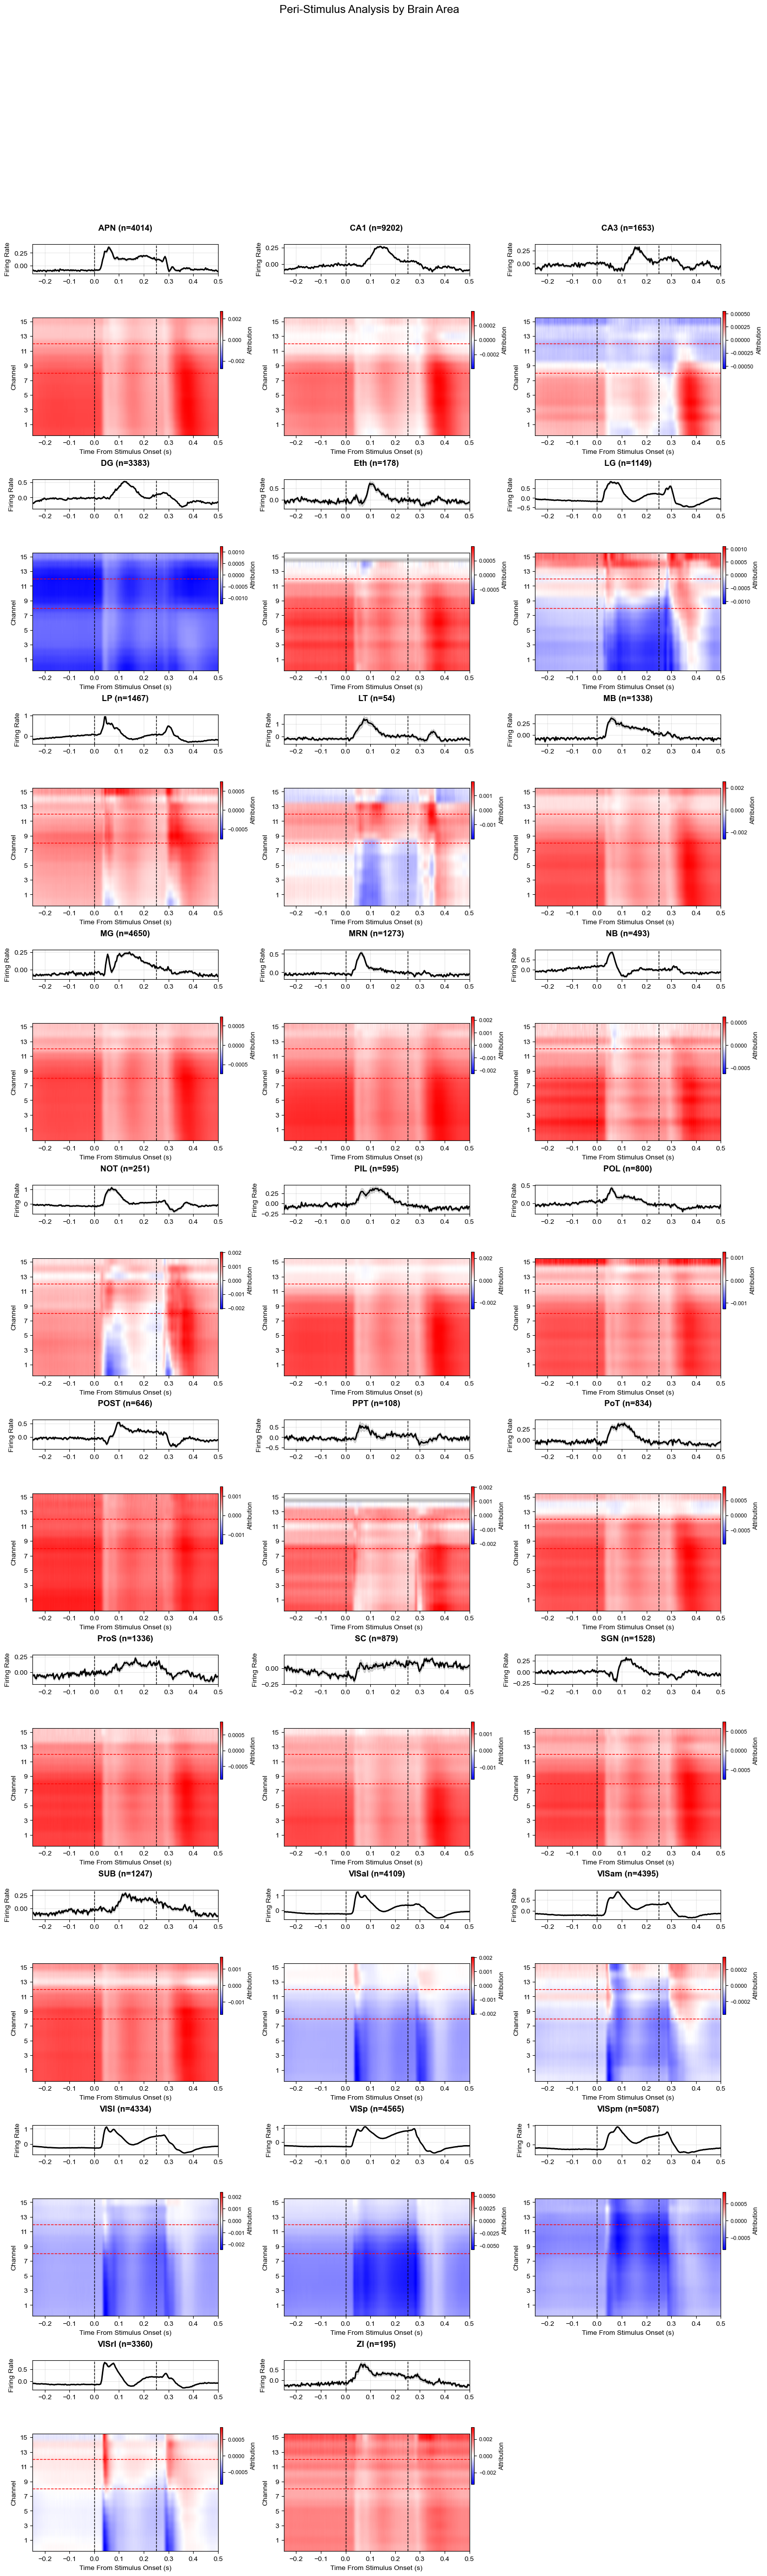

In [40]:
from matplotlib.gridspec import GridSpec

n_areas = len(unique_areas)
n_cols = min(n_areas, 6)  # Max 6 columns for readability
n_rows = 2  # PSTH on top, attribution below
bin_size = 0.004
time_win = [-.25, .5]
t = np.arange(time_win[0], time_win[1], bin_size)

# Plot for all brain areas - column layout with proper proportions
unique_areas = np.unique(all_locs)
unique_areas = [area for area in unique_areas if area not in areas2remove]
unique_areas = sorted(unique_areas)
n_areas = len(unique_areas)

# Calculate layout: 2-3 columns depending on number of areas
n_cols = min(3, n_areas)  # Max 3 columns for readability
n_rows_needed = int(np.ceil(n_areas / n_cols))

# Create figure with reasonable proportions
fig_width = 6 * n_cols
fig_height = 6 * n_rows_needed  # Slightly larger for better spacing
fig = plt.figure(figsize=(fig_width, fig_height))

# Create simpler gridspec: just main plots, let matplotlib handle colorbar positioning
gs = GridSpec(n_rows_needed * 2, n_cols,  # Just main plots
              height_ratios=[1, 4] * n_rows_needed,
              hspace=0.6,  # Increased spacing between rows
              wspace=0.3)  # Spacing between columns

for idx, area in enumerate(unique_areas):
    # Calculate position in grid
    col = idx % n_cols
    row_pair = idx // n_cols
    
    area_mask = (all_locs == area)
    area_attr = all_attr_data[area_mask, :, :]       # shape: (n_units_in_area, n_timepoints, n_channels)
    area_psth = zscore(all_psth[area_mask, :], axis=1)
    
    # Skip if no data
    if np.sum(area_mask) == 0:
        continue
    
    # Calculate PSTH (average across all units)
    psth_mean = np.nanmean(area_psth, axis=0)         # shape: (n_timepoints,)
    psth_sem = stats.sem(area_psth, axis=0, nan_policy='omit')  # shape: (n_timepoints,)
    
    # PSTH plot (top subplot)
    psth_ax = fig.add_subplot(gs[row_pair * 2, col])
    psth_ax.plot(t, psth_mean, 'k-', linewidth=2)
    psth_ax.fill_between(t, psth_mean - psth_sem, psth_mean + psth_sem, alpha=0.3, color='gray')
    psth_ax.axvline(0, color='k', linestyle='--', linewidth=1)
    psth_ax.axvline(0.25, color='k', linestyle='--', linewidth=1)
    psth_ax.set_title(f'{area} (n={np.sum(area_mask)})', fontsize=12, fontweight='bold', pad=20)
    psth_ax.set_ylabel('Firing Rate', fontsize=10)
    psth_ax.grid(True, alpha=0.3)
    psth_ax.set_xlim([time_win[0], time_win[1]])
    
    # Attribution plot (bottom subplot)
    attr_ax = fig.add_subplot(gs[row_pair * 2 + 1, col])
    mean_attr = np.nanmean(area_attr, axis=0)           # shape: (n_timepoints, n_channels)
    vmin = np.nanmin(mean_attr)
    vmax = np.nanmax(mean_attr)
    m = max(abs(vmin), abs(vmax))
    
    im = attr_ax.imshow(mean_attr.T, aspect='auto', cmap='bwr',
                       extent=[time_win[0], time_win[1], 0, chans2keep], vmin=-m, vmax=m)
    
    # Add horizontal lines (layer boundaries)
    attr_ax.hlines(y=3.5, xmin=time_win[0], xmax=time_win[1], colors='r', linestyles='--', linewidth=1)
    attr_ax.hlines(y=7.5, xmin=time_win[0], xmax=time_win[1], colors='r', linestyles='--', linewidth=1)
    
    attr_ax.invert_yaxis()
    attr_ax.set_yticks(np.arange(0.5, chans2keep, 2))
    attr_ax.set_yticklabels(np.arange(chans2keep-1, -1, -2))
    attr_ax.axvline(0, color='k', linestyle='--', linewidth=1)
    attr_ax.axvline(0.25, color='k', linestyle='--', linewidth=1)
    attr_ax.set_xlabel('Time From Stimulus Onset (s)', fontsize=10)
    attr_ax.set_ylabel('Channel', fontsize=10)
    
    # Add colorbar that affects both plots for alignment
    cbar = fig.colorbar(im, ax=[psth_ax, attr_ax], orientation='vertical', 
                       shrink=0.3, fraction=0.03, pad=0.01)  # Apply to both axes
    cbar.set_label('Attribution', fontsize=9)
    cbar.ax.tick_params(labelsize=8)

plt.suptitle('Peri-Stimulus Analysis by Brain Area', fontsize=16, y=0.96)
plt.tight_layout()
plt.savefig(Path(figures_folder) / 'peri_stim_attribution_all_areas.pdf', 
            format='pdf', dpi=300, bbox_inches='tight') 
plt.show()

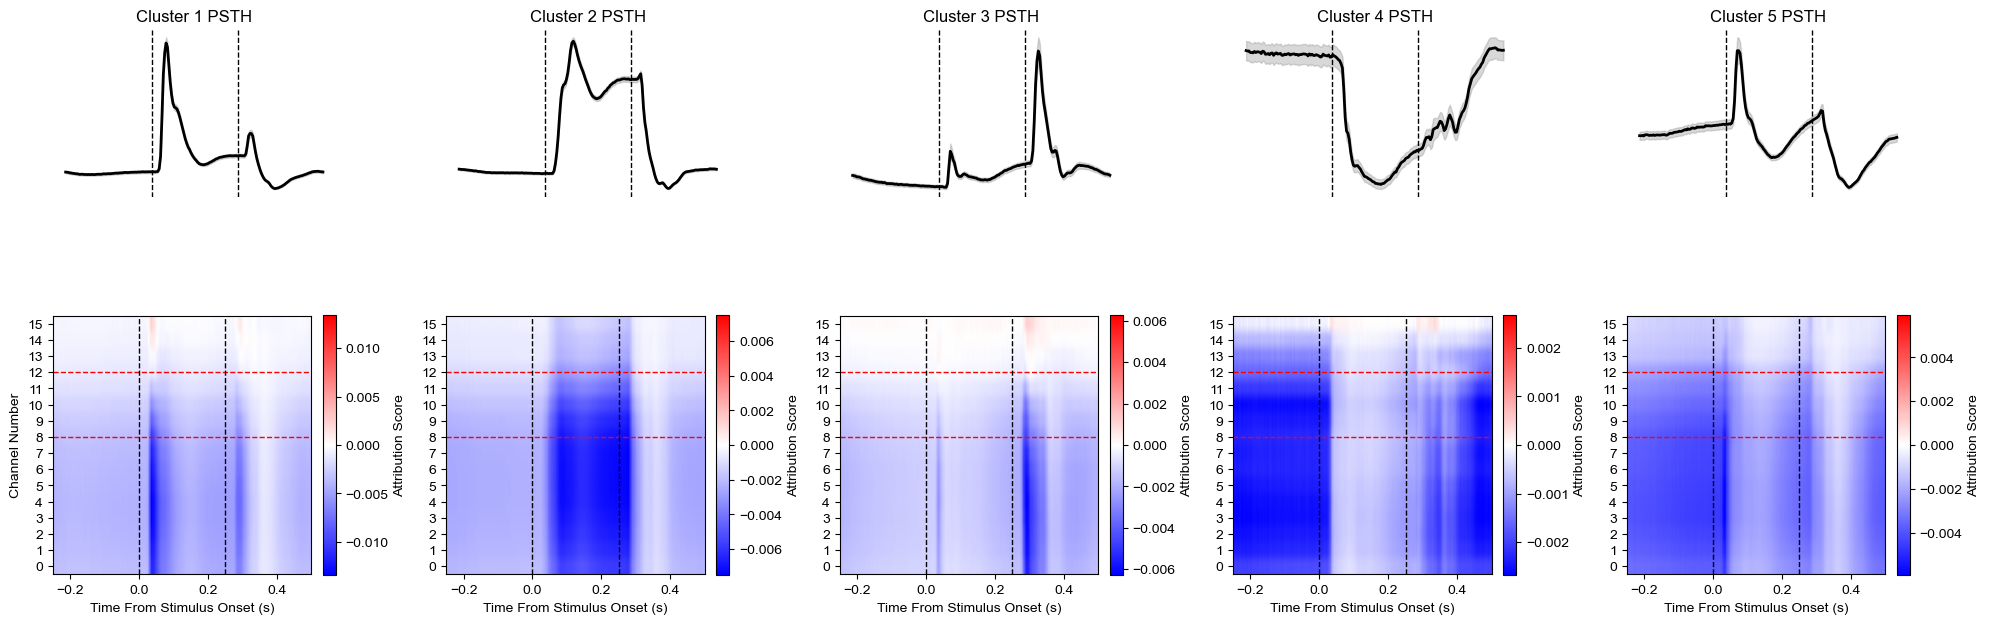

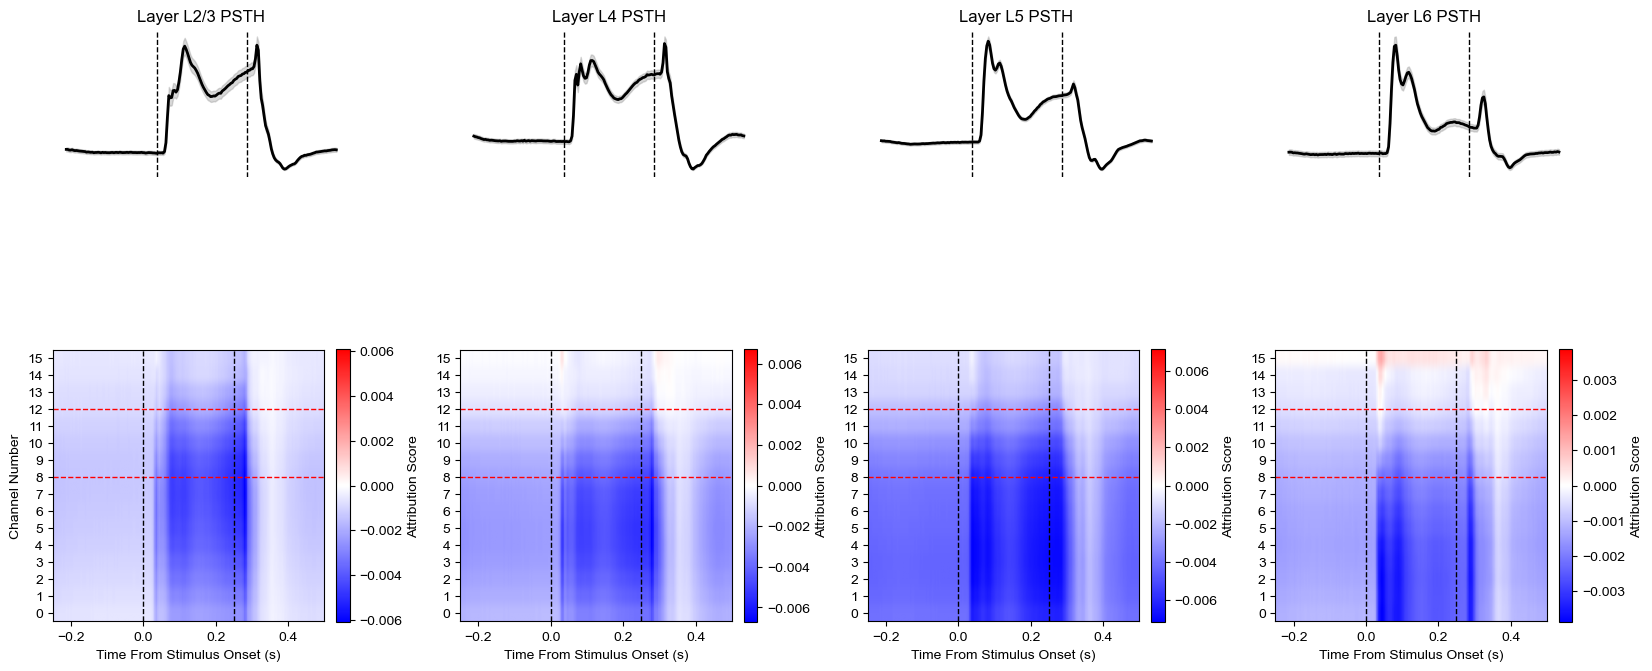

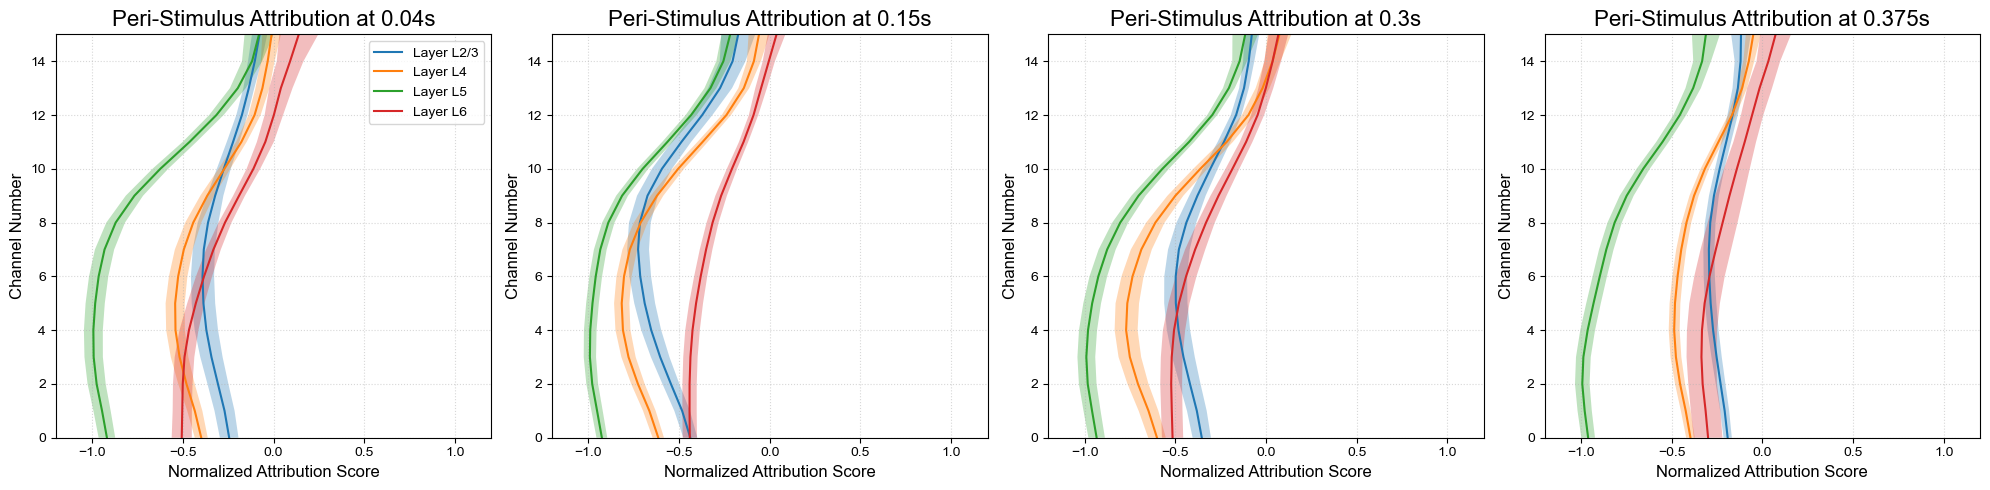

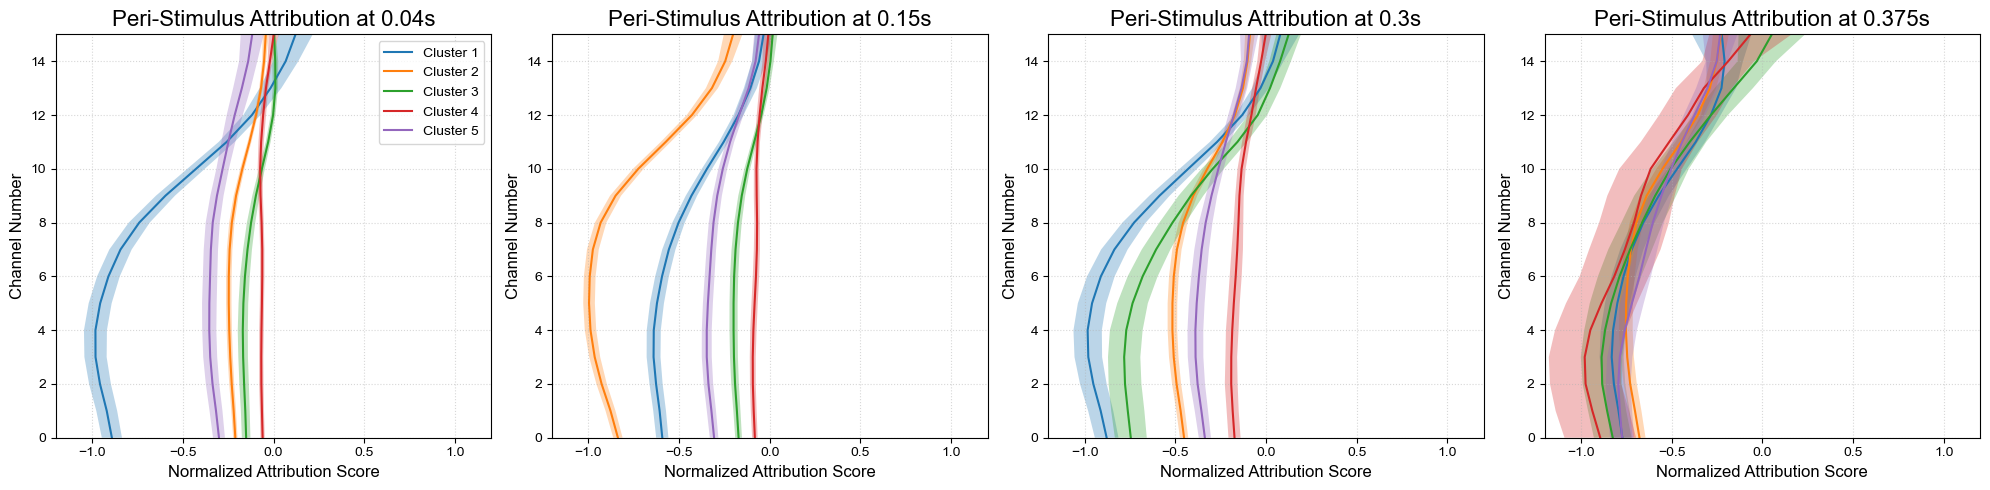

{1: 879, 2: 2223, 3: 514, 4: 384, 5: 565}
{2.0: 833, 4.0: 1007, 5.0: 1895, 6.0: 830}


In [28]:
# for each cluster, make an imshow plot of time x channels of peri-stim attribution
bin_size = 0.004
time_win = [-.25, .5]
t = np.arange(time_win[0], time_win[1], bin_size)
ALL_Layers = sorted(df['layer'][~df['layer'].isna()].unique())
layer_labels = ['L2/3', 'L4', 'L5', 'L6']

fig, ax = plt.subplots(2, 5, figsize=(20, 8), gridspec_kw={'height_ratios': [1, 4]})
for clusteri in range(1,6):
    cluster_mask = (all_cluster_ids == clusteri) & (all_locs=='VISp')
    cluster_attr = all_attr_data[cluster_mask, :, :]       # shape: (n_units_in_cluster, n_timepoints, n_channels)
    cluster_psth = all_psth[cluster_mask, :]
    # Calculate PSTH (average across all channels for each unit, then across units)
    psth_mean = np.nanmean(cluster_psth, axis=0)         # shape: (n_timepoints,)
    psth_sem = stats.sem(cluster_psth, axis=0, nan_policy='omit')  # shape: (n_timepoints,)
    
    # Plot PSTH in top row
    ax[0, clusteri-1].plot(t, psth_mean, 'k-', linewidth=2)
    ax[0, clusteri-1].fill_between(t, psth_mean - psth_sem, psth_mean + psth_sem, alpha=0.3, color='gray')
    ax[0, clusteri-1].axvline(0, color='k', linestyle='--', linewidth=1)
    ax[0, clusteri-1].axvline(0.25, color='k', linestyle='--', linewidth=1)
    ax[0, clusteri-1].set_title(f'Cluster {clusteri} PSTH')
    ax[0, clusteri-1].axis('off')  # Remove all axes
    
    # Calculate attribution image for bottom row
    mean_attr = np.nanmean(cluster_attr, axis=0)           # shape: (n_timepoints, n_channels)
    vmin = np.nanmin(mean_attr)
    vmax = np.nanmax(mean_attr)
    m = max(abs(vmin), abs(vmax))
    
    # Plot imshow in bottom row
    ax[1, clusteri-1].imshow(mean_attr.T, aspect='auto', cmap='bwr',
                          extent=[time_win[0], time_win[1], 0, chans2keep], vmin=-m, vmax=m)
    # add horizontal lines for the middle layer (L4) 
    ax[1, clusteri-1].hlines(y=3.5, xmin=time_win[0], xmax=time_win[1], colors='r', linestyles='--', linewidth=1)
    ax[1, clusteri-1].hlines(y=7.5, xmin=time_win[0], xmax=time_win[1], colors='r', linestyles='--', linewidth=1)
    ax[1, clusteri-1].invert_yaxis()
    ax[1, clusteri-1].set_yticks(np.arange(0.5, chans2keep, 1))
    ax[1, clusteri-1].set_yticklabels(np.arange(chans2keep-1, -1, -1))
    ax[1, clusteri-1].axvline(0,    color='k', linestyle='--', linewidth=1)
    ax[1, clusteri-1].axvline(0.25, color='k', linestyle='--', linewidth=1)
    ax[1, clusteri-1].set_xlabel('Time From Stimulus Onset (s)')
    if clusteri == 1:
        ax[1, clusteri-1].set_ylabel('Channel Number')
    ax[1, clusteri-1].set_aspect(1.0/ax[1, clusteri-1].get_data_ratio(), adjustable='box')
    cbar = plt.colorbar(ax[1, clusteri-1].images[0], ax=ax[1, clusteri-1], 
                    orientation='vertical', shrink=1.0, fraction=0.046, pad=0.04)
    cbar.set_label('Attribution Score')
        
plt.tight_layout()
plt.savefig(Path(figures_folder) / 'peri_stim_attribution_clusters_all_channels.pdf', 
            format='pdf', dpi=300, bbox_inches='tight') 
plt.show()

# same for layers
fig, ax = plt.subplots(2, 5, figsize=(20, 8), gridspec_kw={'height_ratios': [1, 4]})
for idx, layeri in enumerate(ALL_Layers[1:]):
    layer_mask = (all_layers == layeri) & (all_locs=='VISp')
    layer_attr = all_attr_data[layer_mask, :, :]       # shape: (n_units_in_layer, n_timepoints, n_channels)
    layer_psth = all_psth[layer_mask,:]
    # Calculate PSTH (average across all channels for each unit, then across units)
    psth_mean = np.nanmean(layer_psth, axis=0)      # shape: (n_units_in_layer, n_timepoints)
    psth_sem = stats.sem(layer_psth, axis=0, nan_policy='omit')  # shape: (n_timepoints,)
    
    # Plot PSTH in top row
    ax[0, idx].plot(t, psth_mean, 'k-', linewidth=2)
    ax[0, idx].fill_between(t, psth_mean - psth_sem, psth_mean + psth_sem, alpha=0.3, color='gray')
    ax[0, idx].axvline(0, color='k', linestyle='--', linewidth=1)
    ax[0, idx].axvline(0.25, color='k', linestyle='--', linewidth=1)
    ax[0, idx].set_title(f'Layer {layer_labels[idx]} PSTH')
    ax[0, idx].axis('off')  # Remove all axes
    
    # Calculate attribution image for bottom row
    mean_attr = np.nanmean(layer_attr, axis=0)         # shape: (n_timepoints, n_channels)
    vmin = np.nanmin(mean_attr)
    vmax = np.nanmax(mean_attr)
    m = max(abs(vmin), abs(vmax))
    
    # Plot imshow in bottom row
    ax[1, idx].imshow(mean_attr.T, aspect='auto', cmap='bwr',
                   extent=[time_win[0], time_win[1], 0, chans2keep], vmin=-m, vmax=m)
    ax[1, idx].hlines(y=3.5, xmin=time_win[0], xmax=time_win[1], colors='r', linestyles='--', linewidth=1)
    ax[1, idx].hlines(y=7.5, xmin=time_win[0], xmax=time_win[1], colors='r', linestyles='--', linewidth=1)
    ax[1, idx].invert_yaxis()
    ax[1, idx].set_yticks(np.arange(0.5, chans2keep, 1))
    ax[1, idx].set_yticklabels(np.arange(chans2keep-1, -1, -1))
    ax[1, idx].axvline(0,    color='k', linestyle='--', linewidth=1)
    ax[1, idx].axvline(0.25, color='k', linestyle='--', linewidth=1)
    ax[1, idx].set_xlabel('Time From Stimulus Onset (s)')
    if idx == 0:
        ax[1, idx].set_ylabel('Channel Number')
    ax[1, idx].set_aspect(1.0/ax[1, idx].get_data_ratio(), adjustable='box')
    cbar = plt.colorbar(ax[1, idx].images[0], ax=ax[1, idx], 
                    orientation='vertical', shrink=1.0, fraction=0.046, pad=0.04)
    cbar.set_label('Attribution Score')

# Hide unused columns for layers (we only have 4 layers but 5 columns)
ax[0, 4].set_visible(False)
ax[1, 4].set_visible(False)

plt.tight_layout()
plt.savefig(Path(figures_folder) / 'peri_stim_attribution_layers_all_channels.pdf', 
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()


# instead of plotting all time points, for each layer, plot the mean attribution (across channels) 
# at 0.05s, 0.1s 0.3s and 0.4s after stimulus onset, with error bars
# the x-axis will be attribution score, and the y-axis will be channel number, with a separate line for each layer
time_points = [0.04, 0.15, 0.3, 0.375]
time_indices = [int((tp - time_win[0]) / bin_size) for tp in time_points]
fig, ax = plt.subplots(1, len(time_points), figsize=(20, 5))
for idx, time_idx in enumerate(time_indices):
    mean_attr_by_layer = []
    sem_attr_by_layer = []
    for layeri in ALL_Layers[1:]:
        layer_mask = (all_layers == layeri) & (all_locs=='VISp')
        layer_attr = all_attr_data[layer_mask, time_idx, :]       # shape: (n_units_in_layer, n_channels)
        mean_attr = np.nanmean(layer_attr, axis=0)                 # shape: (n_channels,)
        sem_attr = stats.sem(layer_attr, axis=0, nan_policy='omit') # shape: (n_channels,)
        mean_attr_by_layer.append(mean_attr)
        sem_attr_by_layer.append(sem_attr)
    mean_attr_by_layer = np.array(mean_attr_by_layer) # shape: (n_layers, n_channels)
    sem_attr_by_layer = np.array(sem_attr_by_layer)   # shape: (n_layers, n_channels)
    
    # Normalize by the highest absolute value across all layers for this time point
    max_abs_value = np.nanmax(np.abs(mean_attr_by_layer))
    mean_attr_by_layer_norm = mean_attr_by_layer / max_abs_value
    sem_attr_by_layer_norm = sem_attr_by_layer / max_abs_value
    
    y = np.arange(mean_attr_by_layer.shape[1]) # channel numbers for y-axis
    for layer_idx in range(mean_attr_by_layer.shape[0]):
        filtered_attr = gaussian_filter1d(mean_attr_by_layer_norm[layer_idx, :], sigma=1)
        ax[idx].plot(filtered_attr, y, label=f'Layer {layer_labels[layer_idx]}')
        ax[idx].fill_betweenx(y, 
                              filtered_attr - sem_attr_by_layer_norm[layer_idx, :],
                              filtered_attr + sem_attr_by_layer_norm[layer_idx, :],
                              alpha=0.3)
    ax[idx].set_title(f'Peri-Stimulus Attribution at {time_points[idx]}s', fontsize=16)
    ax[idx].set_xlabel('Normalized Attribution Score', fontsize=12)
    ax[idx].set_ylabel('Channel Number', fontsize=12)
    ax[idx].grid(True, linestyle=':', alpha=0.5)
    ax[idx].set_ylim(0, chans2keep-1)
    ax[idx].set_xlim(-1.2, 1.2)  # Normalized values will be between -1 and 1
ax[0].legend()
plt.tight_layout()
plt.savefig(Path(figures_folder) / 'peri_stim_attribution_layers_all_channels_timepoints.pdf', 
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()


# same, but for clusters instead of layers
time_points = [0.04, 0.15, 0.3, 0.375]
time_indices = [int((tp - time_win[0]) / bin_size) for tp in time_points]
fig, ax = plt.subplots(1, len(time_points), figsize=(20, 5))
for idx, time_idx in enumerate(time_indices):
    mean_attr_by_cluster = []
    sem_attr_by_cluster = []
    for clusteri in range(1,6):
        cluster_mask = (all_cluster_ids == clusteri) & (all_locs=='VISp')
        cluster_attr = all_attr_data[cluster_mask, time_idx, :]       # shape: (n_units_in_cluster, n_channels)
        mean_attr = np.nanmean(cluster_attr, axis=0)                 # shape: (n_channels,)
        sem_attr = stats.sem(cluster_attr, axis=0, nan_policy='omit') # shape: (n_channels,)
        mean_attr_by_cluster.append(mean_attr)
        sem_attr_by_cluster.append(sem_attr)
    mean_attr_by_cluster = np.array(mean_attr_by_cluster) # shape: (n_clusters, n_channels)
    sem_attr_by_cluster = np.array(sem_attr_by_cluster)   # shape: (n_clusters, n_channels)
    
    # Normalize by the highest absolute value across all clusters for this time point
    max_abs_value = np.nanmax(np.abs(mean_attr_by_cluster))
    mean_attr_by_cluster_norm = mean_attr_by_cluster / max_abs_value
    sem_attr_by_cluster_norm = sem_attr_by_cluster / max_abs_value
    
    y = np.arange(mean_attr_by_cluster.shape[1]) # channel numbers for y-axis
    for cluster_idx in range(mean_attr_by_cluster.shape[0]):
        filtered_attr = gaussian_filter1d(mean_attr_by_cluster_norm[cluster_idx, :], sigma=1)
        ax[idx].plot(filtered_attr, y, label=f'Cluster {cluster_idx+1}')
        ax[idx].fill_betweenx(y, 
                              filtered_attr - sem_attr_by_cluster_norm[cluster_idx, :],
                              filtered_attr + sem_attr_by_cluster_norm[cluster_idx, :],
                              alpha=0.3)
    ax[idx].set_title(f'Peri-Stimulus Attribution at {time_points[idx]}s', fontsize=16)
    ax[idx].set_xlabel('Normalized Attribution Score', fontsize=12)
    ax[idx].set_ylabel('Channel Number', fontsize=12)
    ax[idx].grid(True, linestyle=':', alpha=0.5)
    ax[idx].set_ylim(0, chans2keep-1)
    ax[idx].set_xlim(-1.2, 1.2)  # Normalized values will be between -1 and 1
ax[0].legend()
plt.tight_layout()
plt.savefig(Path(figures_folder) / 'peri_stim_attribution_clusters_all_channels_timepoints.pdf', 
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

# print the number of neurons in each category 
sum_clusters = {}
for clusteri in range(1,6):
    cluster_mask = (all_cluster_ids == clusteri) & (all_locs=='VISp')
    sum_clusters[clusteri] = sum(cluster_mask)
    
sum_layers = {}
for idx, layeri in enumerate(ALL_Layers[1:]):
    layer_mask = (all_layers == layeri) & (all_locs=='VISp')
    sum_layers[layeri] = sum(layer_mask)
    
print(sum_clusters)
print(sum_layers)

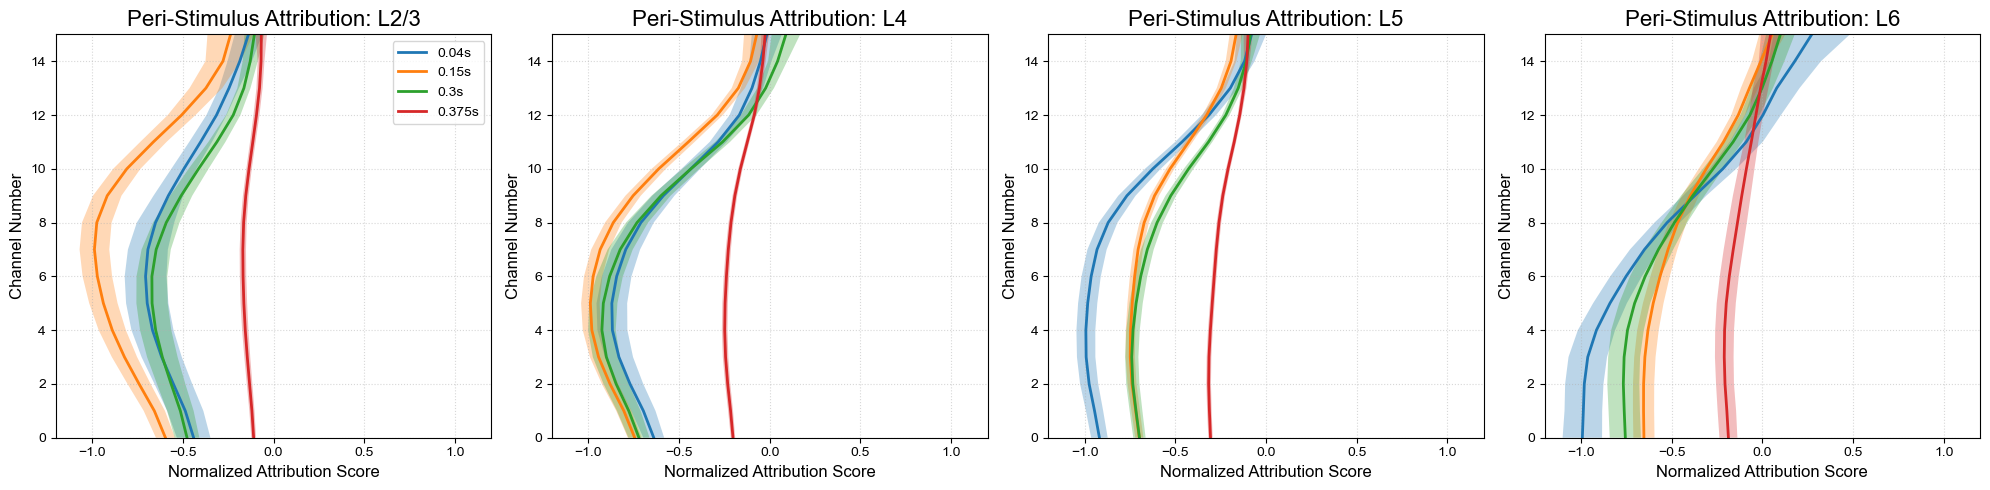

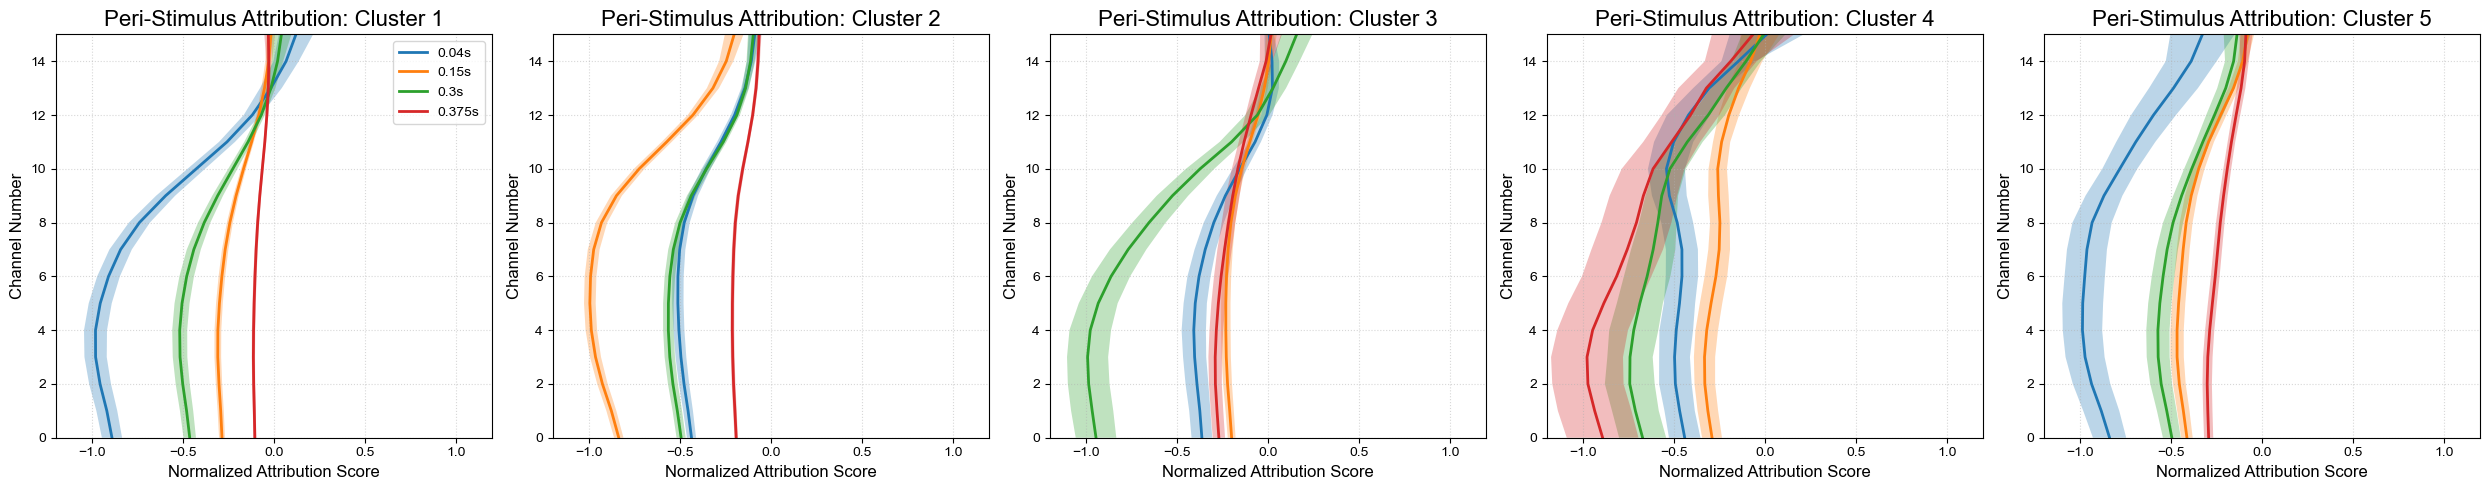

In [29]:
# make the same plot as above, but instead of having a separate line for each time point, 
# have a separate line for each layer/ cluster, 
# and plot the attribution score across channels at the different time points on the same plot (with error bars) 

time_points = [0.04, 0.15, 0.3, 0.375]
time_indices = [int((tp - time_win[0]) / bin_size) for tp in time_points]
layer_labels = ['L2/3', 'L4', 'L5', 'L6']

# Create subplots for each layer
fig, ax = plt.subplots(1, len(ALL_Layers[1:]), figsize=(20, 5))

for layer_idx, layeri in enumerate(ALL_Layers[1:]):
    layer_mask = (all_layers == layeri) & (all_locs=='VISp')
    
    # Collect attribution data for all time points for this layer
    mean_attr_by_time = []
    sem_attr_by_time = []
    max_abs_values = []
    
    for time_idx in time_indices:
        layer_attr = all_attr_data[layer_mask, time_idx, :]       # shape: (n_units_in_layer, n_channels)
        mean_attr = np.nanmean(layer_attr, axis=0)                 # shape: (n_channels,)
        sem_attr = stats.sem(layer_attr, axis=0, nan_policy='omit') # shape: (n_channels,)
        mean_attr_by_time.append(mean_attr)
        sem_attr_by_time.append(sem_attr)
        max_abs_values.append(np.nanmax(np.abs(mean_attr)))
    
    mean_attr_by_time = np.array(mean_attr_by_time)  # shape: (n_timepoints, n_channels)
    sem_attr_by_time = np.array(sem_attr_by_time)    # shape: (n_timepoints, n_channels)
    
    # Normalize by the highest absolute value across all time points for this layer
    max_abs_value = np.nanmax(np.abs(mean_attr_by_time))
    mean_attr_by_time_norm = mean_attr_by_time / max_abs_value
    sem_attr_by_time_norm = sem_attr_by_time / max_abs_value
    
    y = np.arange(mean_attr_by_time.shape[1])  # channel numbers for y-axis
    
    # Plot each time point as a separate line
    for time_idx, tp in enumerate(time_points):
        filtered_attr = gaussian_filter1d(mean_attr_by_time_norm[time_idx, :], sigma=1)
        ax[layer_idx].plot(filtered_attr, y, label=f'{tp}s', linewidth=2)
        ax[layer_idx].fill_betweenx(y, 
                                   filtered_attr - sem_attr_by_time_norm[time_idx, :],
                                   filtered_attr + sem_attr_by_time_norm[time_idx, :],
                                   alpha=0.3)
    
    ax[layer_idx].set_title(f'Peri-Stimulus Attribution: {layer_labels[layer_idx]}', fontsize=16)
    ax[layer_idx].set_xlabel('Normalized Attribution Score', fontsize=12)
    ax[layer_idx].set_ylabel('Channel Number', fontsize=12)
    ax[layer_idx].grid(True, linestyle=':', alpha=0.5)
    ax[layer_idx].set_ylim(0, chans2keep-1)
    ax[layer_idx].set_xlim(-1.2, 1.2)  # Normalized values will be between -1 and 1
    
    if layer_idx == 0:  # Only show legend on first subplot
        ax[layer_idx].legend()

plt.tight_layout()
plt.savefig(Path(figures_folder) / 'peri_stim_attribution_layers_all_timepoints_by_group.pdf', 
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

time_points = [0.04, 0.15, 0.3, 0.375]
time_indices = [int((tp - time_win[0]) / bin_size) for tp in time_points]

# Create subplots for each cluster
fig, ax = plt.subplots(1, 5, figsize=(25, 5))  # 5 clusters

for cluster_idx in range(5):
    clusteri = cluster_idx + 1  # Clusters are numbered 1-5
    cluster_mask = (all_cluster_ids == clusteri) & (all_locs=='VISp')
    
    # Collect attribution data for all time points for this cluster
    mean_attr_by_time = []
    sem_attr_by_time = []
    max_abs_values = []
    
    for time_idx in time_indices:
        cluster_attr = all_attr_data[cluster_mask, time_idx, :]       # shape: (n_units_in_cluster, n_channels)
        mean_attr = np.nanmean(cluster_attr, axis=0)                 # shape: (n_channels,)
        sem_attr = stats.sem(cluster_attr, axis=0, nan_policy='omit') # shape: (n_channels,)
        mean_attr_by_time.append(mean_attr)
        sem_attr_by_time.append(sem_attr)
        max_abs_values.append(np.nanmax(np.abs(mean_attr)))
    
    mean_attr_by_time = np.array(mean_attr_by_time)  # shape: (n_timepoints, n_channels)
    sem_attr_by_time = np.array(sem_attr_by_time)    # shape: (n_timepoints, n_channels)
    
    # Normalize by the highest absolute value across all time points for this cluster
    max_abs_value = np.nanmax(np.abs(mean_attr_by_time))
    mean_attr_by_time_norm = mean_attr_by_time / max_abs_value
    sem_attr_by_time_norm = sem_attr_by_time / max_abs_value
    
    y = np.arange(mean_attr_by_time.shape[1])  # channel numbers for y-axis
    
    # Plot each time point as a separate line
    for time_idx, tp in enumerate(time_points):
        filtered_attr = gaussian_filter1d(mean_attr_by_time_norm[time_idx, :], sigma=1)
        ax[cluster_idx].plot(filtered_attr, y, label=f'{tp}s', linewidth=2)
        ax[cluster_idx].fill_betweenx(y, 
                                     filtered_attr - sem_attr_by_time_norm[time_idx, :],
                                     filtered_attr + sem_attr_by_time_norm[time_idx, :],
                                     alpha=0.3)
    
    ax[cluster_idx].set_title(f'Peri-Stimulus Attribution: Cluster {clusteri}', fontsize=16)
    ax[cluster_idx].set_xlabel('Normalized Attribution Score', fontsize=12)
    ax[cluster_idx].set_ylabel('Channel Number', fontsize=12)
    ax[cluster_idx].grid(True, linestyle=':', alpha=0.5)
    ax[cluster_idx].set_ylim(0, chans2keep-1)
    ax[cluster_idx].set_xlim(-1.2, 1.2)  # Normalized values will be between -1 and 1
    
    if cluster_idx == 0:  # Only show legend on first subplot
        ax[cluster_idx].legend()

plt.tight_layout()
plt.savefig(Path(figures_folder) / 'peri_stim_attribution_clusters_all_timepoints_by_group.pdf', 
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()



In [ ]:
# for each area, make a scatter plot of the attribution vs spontaneous attribution for the selected channel and band
# chani =  6  
# bandi = 0  # broadband

# for i, area in enumerate(unique_areas):
#     fig, ax = plt.subplots(figsize=(8,5))
#     attr_vals = df.loc[df['structure_acronym'] == area, f'attr_{chani}_{bandi}'].values
#     attr_spont_vals = df.loc[df['structure_acronym'] == area, f'attr_spont_{chani}_{bandi}'].values
    
#     # Remove NaN values
#     mask = ~np.isnan(attr_vals) & ~np.isnan(attr_spont_vals)
#     attr_vals_clean = np.abs(attr_vals[mask])
#     attr_spont_vals_clean = np.abs(attr_spont_vals[mask])

#     if len(attr_vals_clean) == 0:
#         continue
        
#     ax.scatter(attr_vals_clean, attr_spont_vals_clean, alpha=0.5)
#     ax.set_title(area)
#     # ax.set_xscale('log')
#     # ax.set_yscale('log')
#     ax.set_xlabel('Attribution Score')
#     ax.set_ylabel('Spontaneous Attribution Score')
    
#     # Unity line -     Method 1 (recommended)
#     all_vals = np.concatenate((attr_vals_clean, attr_spont_vals_clean))
#     lims = [np.min(all_vals), np.max(all_vals)]
#     ax.plot(lims, lims, 'r--', alpha=0.8, zorder=0, linewidth=2, label='Unity line')
#     ax.set_xlim(lims)
#     ax.set_ylim(lims)
    
#     ax.set_aspect('equal', adjustable='box')
#     ax.legend()
#     plt.tight_layout()
#     plt.show()

# plt.savefig(Path(figures_folder) / 'attribution_vs_spontaneous_attribution_scatter_plots.pdf', format='pdf', dpi=300, bbox_inches='tight')

## plot the enhancement index active vs spontaneous

In [ ]:
# --- Define the specific channel and band variables used in your DataFrame columns ---
chani = 5
bandi = 0
active_col = f'attr_{chani}_{bandi}'
spont_col = f'attr_spont_{chani}_{bandi}'
EPS = 1e-6

# --- CRITICAL CORRECTION: TAKE ABSOLUTE VALUE BEFORE GROUPING ---

# 1. Take the absolute value of the attribution scores in the DataFrame.
#    This ensures we compare the MAGNITUDE of influence.
df['abs_active'] = np.abs(df[active_col])
df['abs_spont'] = np.abs(df[spont_col])

# 2. Group the data by area and calculate the mean of the ABSOLUTE attribution scores.
area_means = df.groupby('structure_acronym')[['abs_active', 'abs_spont']].mean().reset_index()
area_means = area_means[area_means['structure_acronym'].isin(unique_areas)]


# --- REMAINING CALCULATION (Using the corrected absolute means) ---

# Method 1: Simple Ratio of Means (Active / Spontaneous)
area_means['Simple_Ratio'] = area_means['abs_active'] / (area_means['abs_spont'] + EPS)

# Method 2: Enhancement/Attenuation Index
area_means['Enhancement_Index'] = (area_means['abs_active'] - area_means['abs_spont']) / \
                                 (area_means['abs_active'] + area_means['abs_spont'] + EPS)

# --- Visualization Code Follows (Unchanged) ---

# Drop rows where attribution is essentially zero in both 
area_means.dropna(subset=['Enhancement_Index'], inplace=True)
area_means.sort_values(by='Enhancement_Index', inplace=True, ascending=False)
areas_sorted = area_means['structure_acronym'].values
N_areas = len(areas_sorted)

# --- Visualization: Paired Bar Charts (Ratio and Index) ---

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
x = np.arange(N_areas)

# # --- Chart 1: Simple Ratio of Means ---
# ax = axes[0]
# ax.bar(x, area_means['Simple_Ratio'], color='darkgreen', alpha=0.7)

# ax.axhline(1.0, color='r', linestyle='--', linewidth=1.5, label='Unity Line (Ratio=1)')
# ax.set_title('Ratio of Mean Attribution (Active / Spontaneous)', fontsize=14)
# ax.set_ylabel('Ratio of Means', fontsize=12)
# ax.set_xticks(x)
# ax.set_xticklabels(areas_sorted, rotation=45, ha='right')
# ax.legend()
# ax.set_yscale('log') # Use log scale for better visibility of large ratios
# ax.grid(axis='y', linestyle=':', alpha=0.6)

# --- Chart 2: Enhancement/Attenuation Index ---
ax = axes
colors = ['r' if idx > 0 else 'b' for idx in area_means['Enhancement_Index']]
ax.bar(x, area_means['Enhancement_Index'], color=colors, alpha=0.8)

ax.axhline(0, color='k', linestyle='-', linewidth=1.5, label='Unity Line (Index=0)')
ax.set_title('Enhancement / Attenuation Index', fontsize=14)
ax.set_ylabel('Index (Active Preference $\\rightarrow +1$)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(areas_sorted, rotation=45, ha='right')
ax.legend(handles=[plt.Line2D([0], [0], color='r', lw=4, label='Active Preference'),
                   plt.Line2D([0], [0], color='b', lw=4, label='Spontaneous Preference')],
           loc='upper right', title='Index Sign')
ax.set_ylim(-.25, .25)
ax.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


## Compare SST and VIP interneurons 


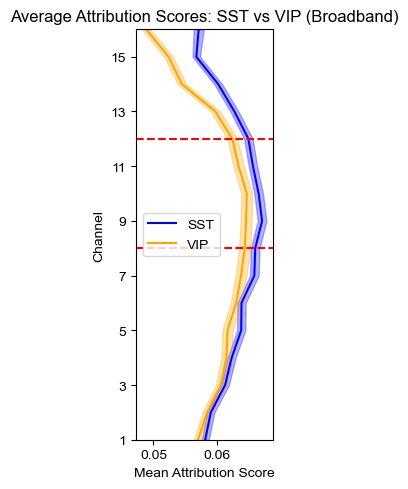

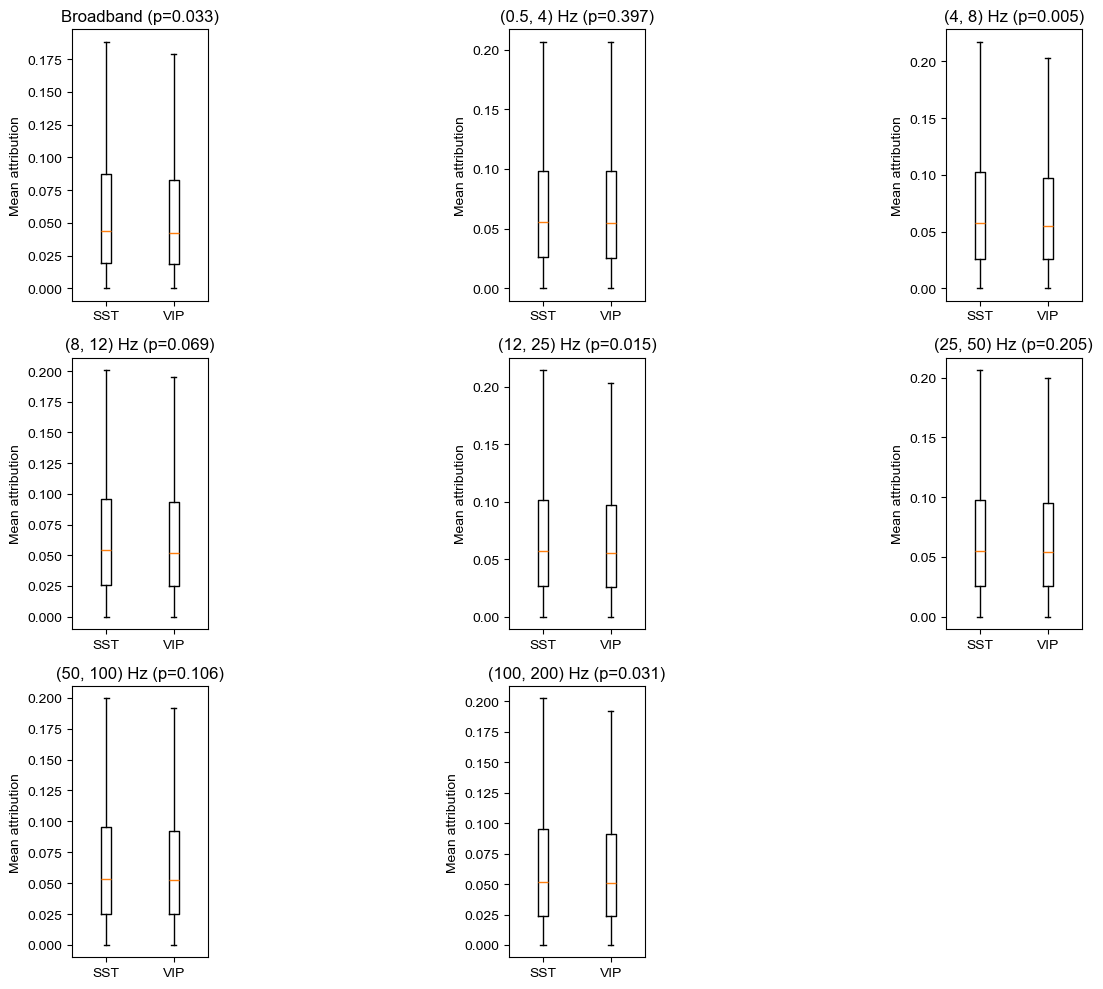

In [71]:
# Compare SST and VIP interneurons 
from scipy.stats import ranksums
vis_idx = df.unit_id[df['structure_acronym'].str.contains("VIS")]
sst = df.unit_id[df['genotype'].str.contains("Sst")]
vip = df.unit_id[df['genotype'].str.contains("Vip")]
sst  = np.intersect1d(sst, vis_idx)
vip = np.intersect1d(vip,  vis_idx)

mean_attr_sst_vip = np.zeros((2, len(bands)+1, chans2keep))
sem_attr_sst_vip = np.zeros((2, len(bands)+1, chans2keep))

for bandi in range(len(bands)+1):
    for chani in range(chans2keep):
        attr_sst = df.loc[df.unit_id.isin(sst), f'attr_{chani}_{bandi}'].values
        attr_vip = df.loc[df.unit_id.isin(vip), f'attr_{chani}_{bandi}'].values
        
        attr_sst = np.abs(attr_sst[~np.isnan(attr_sst)])
        attr_vip = np.abs(attr_vip[~np.isnan(attr_vip)])
        
        mean_attr_sst_vip[0, bandi, chani] = np.mean(attr_sst)
        sem_attr_sst_vip[0, bandi, chani] = stats.sem(attr_sst, nan_policy='omit')
        
        mean_attr_sst_vip[1, bandi, chani] = np.mean(attr_vip)
        sem_attr_sst_vip[1, bandi, chani] = stats.sem(attr_vip, nan_policy='omit')


fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(mean_attr_sst_vip[0, 0, :], channel_indices, label='SST', color='blue')
ax.fill_betweenx(channel_indices,
                mean_attr_sst_vip[0, 0, :] - sem_attr_sst_vip[0, 0, :],
                mean_attr_sst_vip[0, 0, :] + sem_attr_sst_vip[0, 0, :],
                color='blue', alpha=0.3)
ax.plot(mean_attr_sst_vip[1, 0, :], channel_indices, label='VIP', color='orange')
ax.fill_betweenx(channel_indices,
                mean_attr_sst_vip[1, 0, :] - sem_attr_sst_vip[1, 0, :],
                mean_attr_sst_vip[1, 0, :] + sem_attr_sst_vip[1, 0, :],
                color='orange', alpha=0.3)
ax.set_title('Average Attribution Scores: SST vs VIP (Broadband)')
ax.set_ylabel('Channel')
ax.set_ylim(0, chans2keep-1)
ax.set_yticks(np.arange(0, chans2keep, 2))
ax.set_yticklabels(np.arange(1, chans2keep+1, 2))
ax.set_xlabel('Mean Attribution Score')
ax.set_aspect(3.0/ax.get_data_ratio(), adjustable='box')
ax.axhline(y=7, color='r', linestyle='--')
ax.axhline(y=11, color='r', linestyle='--')
ax.legend()
plt.tight_layout()
plt.savefig(Path(figures_folder) / 'average_attribution_scores_sst_vs_vip_broadband.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

chani = 6

# loop through the bands and get the attribution scores for the sst and vip units

fig, ax = plt.subplots(3,3, figsize=(15,10))
eps = 1e-6

for bandi in range(len(bands)+1):
    # get the attribution scores for the sst and vip units
    attr_sst = df.loc[df.unit_id.isin(sst), f'attr_{chani}_{bandi}'].values + eps
    attr_vip = df.loc[df.unit_id.isin(vip), f'attr_{chani}_{bandi}'].values + eps
    
    # remove NaN values and take absolute values
    attr_sst = np.abs(attr_sst[~np.isnan(attr_sst)])
    attr_vip = np.abs(attr_vip[~np.isnan(attr_vip)])
    
    # perform ranksum test
    stat, pval = ranksums(attr_sst, attr_vip)

    ax.flat[bandi].boxplot([attr_sst, attr_vip], showfliers=False)
    if bandi == 0:
        ax.flat[bandi].set_title('Broadband' + f' (p={pval:.3f})')
    else:
        ax.flat[bandi].set_title(str(bands[bandi-1]) + ' Hz' + f' (p={pval:.3f})')
    ax.flat[bandi].set_xticklabels(['SST', 'VIP'])
    ax.flat[bandi].set_ylabel('Mean attribution') 
    ax.flat[bandi].set_box_aspect(2)
    
plt.tight_layout()
fig.delaxes(ax.flat[-1])
plt.savefig(Path(figures_folder) / 'SST_vs_VIP_attribution_scores_channel_7.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

## Compare PYR vs INT

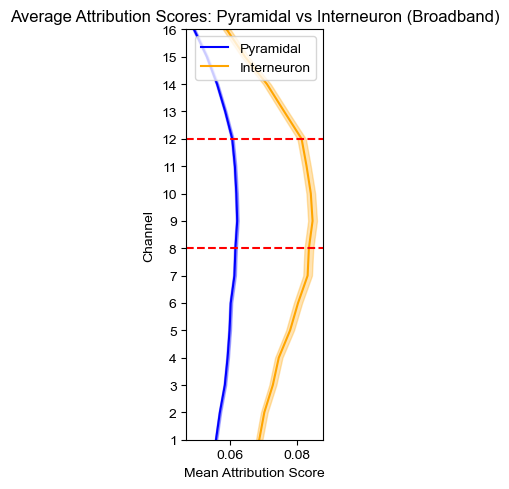

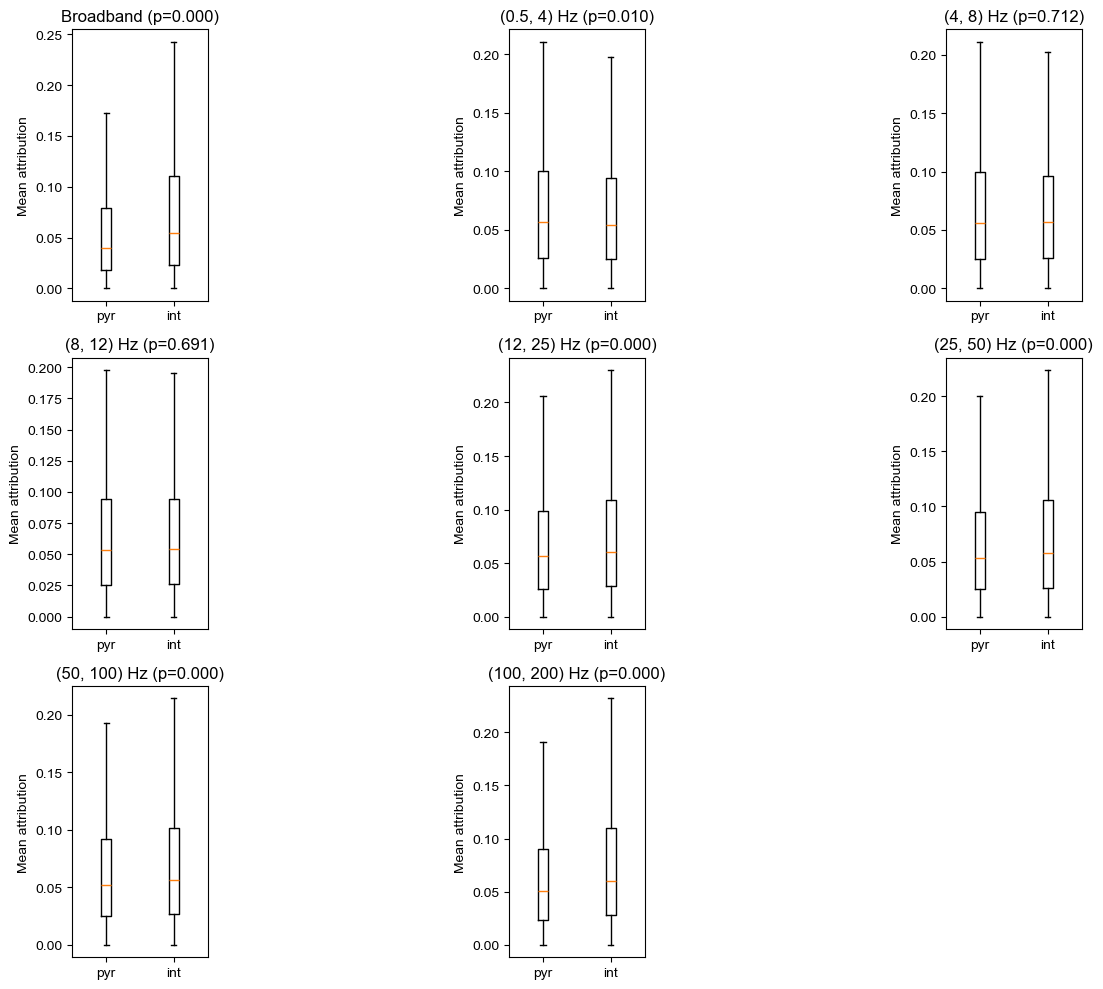

In [49]:
from scipy.stats import ranksums

vis_idx = df.unit_id[df['structure_acronym'].str.contains("VIS")]
# receives_input = df.unit_id[df['num_conn_i_from_e'] > 0]
pyr  = np.intersect1d(df.unit_id[df.pyr == 1], vis_idx)
intn = np.intersect1d(df.unit_id[df.pyr == 0], vis_idx)
# intn_confirmed = np.intersect1d(intn, receives_input)

mean_attr_pyr_int = np.zeros((2, len(bands)+1, chans2keep))
sem_attr_pyr_int = np.zeros((2, len(bands)+1, chans2keep))

for bandi in range(len(bands)+1):
    for chani in range(chans2keep):
        attr_pyr = df.loc[df.unit_id.isin(pyr), f'attr_{chani}_{bandi}'].values
        attr_int = df.loc[df.unit_id.isin(intn), f'attr_{chani}_{bandi}'].values
        
        attr_pyr = np.abs(attr_pyr[~np.isnan(attr_pyr)])
        attr_int = np.abs(attr_int[~np.isnan(attr_int)])
        
        mean_attr_pyr_int[0, bandi, chani] = np.mean(attr_pyr)
        sem_attr_pyr_int[0, bandi, chani] = stats.sem(attr_pyr, nan_policy='omit')
        
        mean_attr_pyr_int[1, bandi, chani] = np.mean(attr_int)
        sem_attr_pyr_int[1, bandi, chani] = stats.sem(attr_int, nan_policy='omit')


fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(mean_attr_pyr_int[0, 0, :], channel_indices,  label='Pyramidal', color='blue')
ax.fill_betweenx(channel_indices,
                mean_attr_pyr_int[0, 0, :] - sem_attr_pyr_int[0, 0, :],
                mean_attr_pyr_int[0, 0, :] + sem_attr_pyr_int[0, 0, :],
                color='blue', alpha=0.3)
ax.plot(mean_attr_pyr_int[1, 0, :], channel_indices, label='Interneuron', color='orange')
ax.fill_betweenx(channel_indices,
                mean_attr_pyr_int[1, 0, :] - sem_attr_pyr_int[1, 0, :],
                mean_attr_pyr_int[1, 0, :] + sem_attr_pyr_int[1, 0, :],
                color='orange', alpha=0.3)
ax.set_title('Average Attribution Scores: Pyramidal vs Interneuron (Broadband)')
ax.set_ylabel('Channel')
ax.set_ylim(0, chans2keep-1)
ax.set_yticks(channel_indices)
ax.set_yticklabels(channel_indices+1)
ax.set_xlabel('Mean Attribution Score')
ax.set_aspect(3.0/ax.get_data_ratio(), adjustable='box')
ax.axhline(y=7, color='r', linestyle='--')
ax.axhline(y=11, color='r', linestyle='--')
ax.legend()
plt.tight_layout()
plt.savefig(Path(figures_folder) / 'average_attribution_scores_pyr_vs_intn_broadband.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

chani = 5
eps = 1e-6
# loop through the bands and get the attribution scores for the pyr and intn units

fig, ax = plt.subplots(3,3, figsize=(15,10))
for bandi in range(len(bands)+1):
    # get the attribution scores for the pyr and intn units
    attr_pyt = df.loc[df.unit_id.isin(pyr), f'attr_{chani}_{bandi}'].values + eps
    attr_int = df.loc[df.unit_id.isin(intn), f'attr_{chani}_{bandi}'].values + eps
    
    # remove NaN values and take absolute values
    attr_pyt = np.abs(attr_pyt[~np.isnan(attr_pyt)])
    attr_int = np.abs(attr_int[~np.isnan(attr_int)])
    
    # perform ranksum test
    stat, pval = ranksums(attr_pyt, attr_int)
    
    ax.flat[bandi].boxplot([attr_pyt, attr_int], showfliers=False)
    if bandi == 0:
        ax.flat[bandi].set_title('Broadband' + f' (p={pval:.3f})')
    else:
        ax.flat[bandi].set_title(str(bands[bandi-1]) + ' Hz' + f' (p={pval:.3f})')
    ax.flat[bandi].set_xticklabels(['pyr', 'int'])
    ax.flat[bandi].set_ylabel('Mean attribution')
    ax.flat[bandi].set_box_aspect(2)
    
plt.tight_layout()
fig.delaxes(ax.flat[-1])
plt.savefig(Path(figures_folder) / 'pyr_vs_intn_attribution_scores_channel_5.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# predict cell type (PYR vs INT) using the attribution scores
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, balanced_accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Get data
visual_neurons = df[df['structure_acronym'].str.contains('VIS')]
X = []
for i, row in visual_neurons.iterrows():
    attr_vector = []
    for bandi in range(len(bands)+1):
        for chani in range(chans2keep):
            attr_vector.append(row[f'attr_{chani}_{bandi}'])
    X.append(attr_vector)
X = np.array(X)
y = visual_neurons['pyr'].values  # 1 = PYT, 0 = INT

# define putative PV interneurons as those with waveform duration < 0.4 ms and firing rate > 10 Hz
pv_mask = (visual_neurons['waveform_duration'] < 0.4) & (visual_neurons['firing_rate'] > 10) & (visual_neurons['pyr'] == 0)
# keep only the putative PV interneurons and PYR neurons
valid_mask = (visual_neurons['pyr'] == 1) | pv_mask
X = X[valid_mask]
y = y[valid_mask]

# Remove rows where ALL features are NaN (if any)
valid_rows = ~np.all(np.isnan(X), axis=1)
X = X[valid_rows]
y = y[valid_rows]

def objective(trial, X_train, y_train):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 5, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    
    clf = RandomForestClassifier(
        n_estimators=n_estimators, 
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        class_weight='balanced',  # Handle class imbalance
        random_state=42
    )
    
    # Inner CV for hyperparameter validation
    X_opt_train, X_opt_val, y_opt_train, y_opt_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
    )
    
    # Preprocess inside the fold (no data leakage)
    imputer = SimpleImputer(strategy='median')
    scaler = StandardScaler()
    
    X_opt_train_processed = scaler.fit_transform(imputer.fit_transform(X_opt_train))
    X_opt_val_processed = scaler.transform(imputer.transform(X_opt_val))
    
    clf.fit(X_opt_train_processed, y_opt_train)
    y_pred_opt = clf.predict(X_opt_val_processed)
    
    return balanced_accuracy_score(y_opt_val, y_pred_opt)

# Stratified CV (maintains class balance)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {'balanced_accuracy': [], 'params': []}
y_pred_cv = np.zeros_like(y)

for fold_idx, (train_index, test_index) in enumerate(skf.split(X, y)):
    print(f'Training fold {fold_idx+1}')
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Hyperparameter optimization
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials=30)
    best_params = study.best_params
    
    # Preprocess this fold
    imputer = SimpleImputer(strategy='median')
    scaler = StandardScaler()
    
    X_train_processed = scaler.fit_transform(imputer.fit_transform(X_train))
    X_test_processed = scaler.transform(imputer.transform(X_test))
    
    # Train final model for this fold
    clf = RandomForestClassifier(
        n_estimators=best_params['n_estimators'],
        max_depth=best_params['max_depth'],
        min_samples_split=best_params['min_samples_split'],
        class_weight='balanced',
        random_state=42
    )
    
    clf.fit(X_train_processed, y_train)
    y_pred_fold = clf.predict(X_test_processed)
    y_pred_cv[test_index] = y_pred_fold
    
    acc = balanced_accuracy_score(y_test, y_pred_fold)
    results['balanced_accuracy'].append(acc)
    results['params'].append(best_params)
    print(f'  Fold {fold_idx+1} accuracy: {acc:.4f}')

print(f'\nBalanced accuracy over 5-fold CV: {np.mean(results["balanced_accuracy"]):.3f} ± {np.std(results["balanced_accuracy"]):.3f}')

# Use CV predictions for confusion matrix (no data leakage)
cm = confusion_matrix(y, y_pred_cv)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, 
                             display_labels=['INT', 'PYT'])
disp.plot(cmap='Blues', values_format=".2f")
plt.title('Confusion Matrix: Predicting Cell Type (PYT vs INT) from Attribution Scores\n(Cross-Validation Predictions)')
plt.savefig(Path(figures_folder) / 'confusion_matrix_pyt_vs_int_from_attribution_scores.pdf', 
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

## Compare the different visual cortex functional clusters

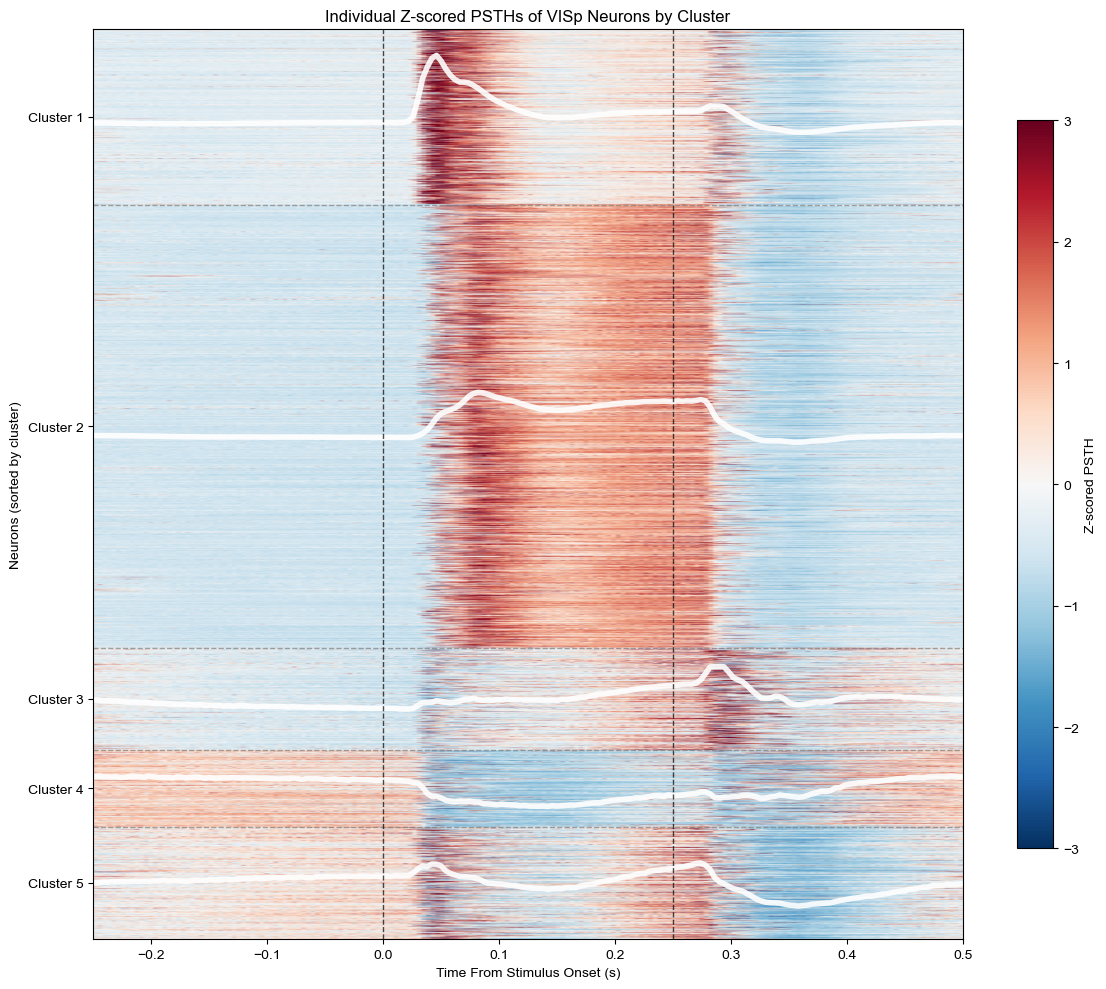

In [80]:
# Create imshow plot of individual z-scored PSTHs sorted by cluster
# Filter for VISp neurons and sort by cluster ID
visp_mask = (all_locs == 'VISp')
visp_psth = all_psth[visp_mask, :]
visp_cluster_ids = all_cluster_ids[visp_mask]

# Sort indices by cluster ID
sort_idx = np.argsort(visp_cluster_ids)
sorted_psth = visp_psth[sort_idx, :]
sorted_cluster_ids = visp_cluster_ids[sort_idx]

# Z-score each neuron's PSTH
from scipy import stats
zscore_psth = stats.zscore(sorted_psth, axis=1)

# Find cluster boundaries and centers
cluster_boundaries = []
cluster_centers = []
cluster_labels = []

current_pos = 0
for cluster_id in range(1, 6):
    cluster_count = np.sum(sorted_cluster_ids == cluster_id)
    if cluster_count > 0:
        cluster_center = current_pos + cluster_count // 2
        cluster_centers.append(cluster_center)
        cluster_labels.append(f'Cluster {cluster_id}')
        
        if cluster_id < 5:  # Don't add boundary after last cluster
            cluster_boundaries.append(current_pos + cluster_count - 0.5)
        current_pos += cluster_count

# Calculate cluster average PSTHs for overlay
cluster_averages = {}
overlay_positions = {}

current_pos = 0
for cluster_id in range(1, 6):
    cluster_mask = (sorted_cluster_ids == cluster_id)
    if np.sum(cluster_mask) > 0:
        cluster_avg = np.nanmean(zscore_psth[cluster_mask, :], axis=0)
        cluster_averages[cluster_id] = cluster_avg
        overlay_positions[cluster_id] = current_pos + np.sum(cluster_mask) // 2
        current_pos += np.sum(cluster_mask)

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the imshow
im = ax.imshow(zscore_psth, aspect='auto', cmap='RdBu_r', 
               extent=[time_win[0], time_win[1], zscore_psth.shape[0], 0],
               vmin=-3, vmax=3)

# Add cluster separator lines
for boundary in cluster_boundaries:
    ax.axhline(y=boundary, color='gray', linestyle='--', alpha=0.7, linewidth=1)

# Overlay cluster averages in white - CORRECTED VERSION
for cluster_id, avg_psth in cluster_averages.items():
    y_center = overlay_positions[cluster_id]
    
    # Scale the average PSTH values and center them around the cluster position
    # The avg_psth contains z-scored values, so scale them appropriately for the plot
    scaled_avg = avg_psth * -100  # Scale factor to make the line visible
    y_positions = y_center + scaled_avg
    
    # Plot the actual PSTH line in white
    ax.plot(t, y_positions, color='white', linewidth=4, alpha=0.9)
    
# Set ticks and labels
ax.set_yticks(cluster_centers)
ax.set_yticklabels(cluster_labels)
ax.set_xlabel('Time From Stimulus Onset (s)')
ax.set_ylabel('Neurons (sorted by cluster)')

# Add vertical lines for stimulus timing
ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax.axvline(0.25, color='black', linestyle='--', linewidth=1, alpha=0.7)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Z-scored PSTH')

plt.title('Individual Z-scored PSTHs of VISp Neurons by Cluster')
plt.tight_layout()
plt.savefig(Path(figures_folder) / 'psth_clusters_VISp.pdf', 
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

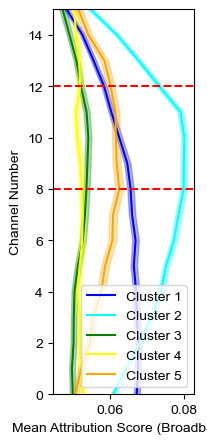

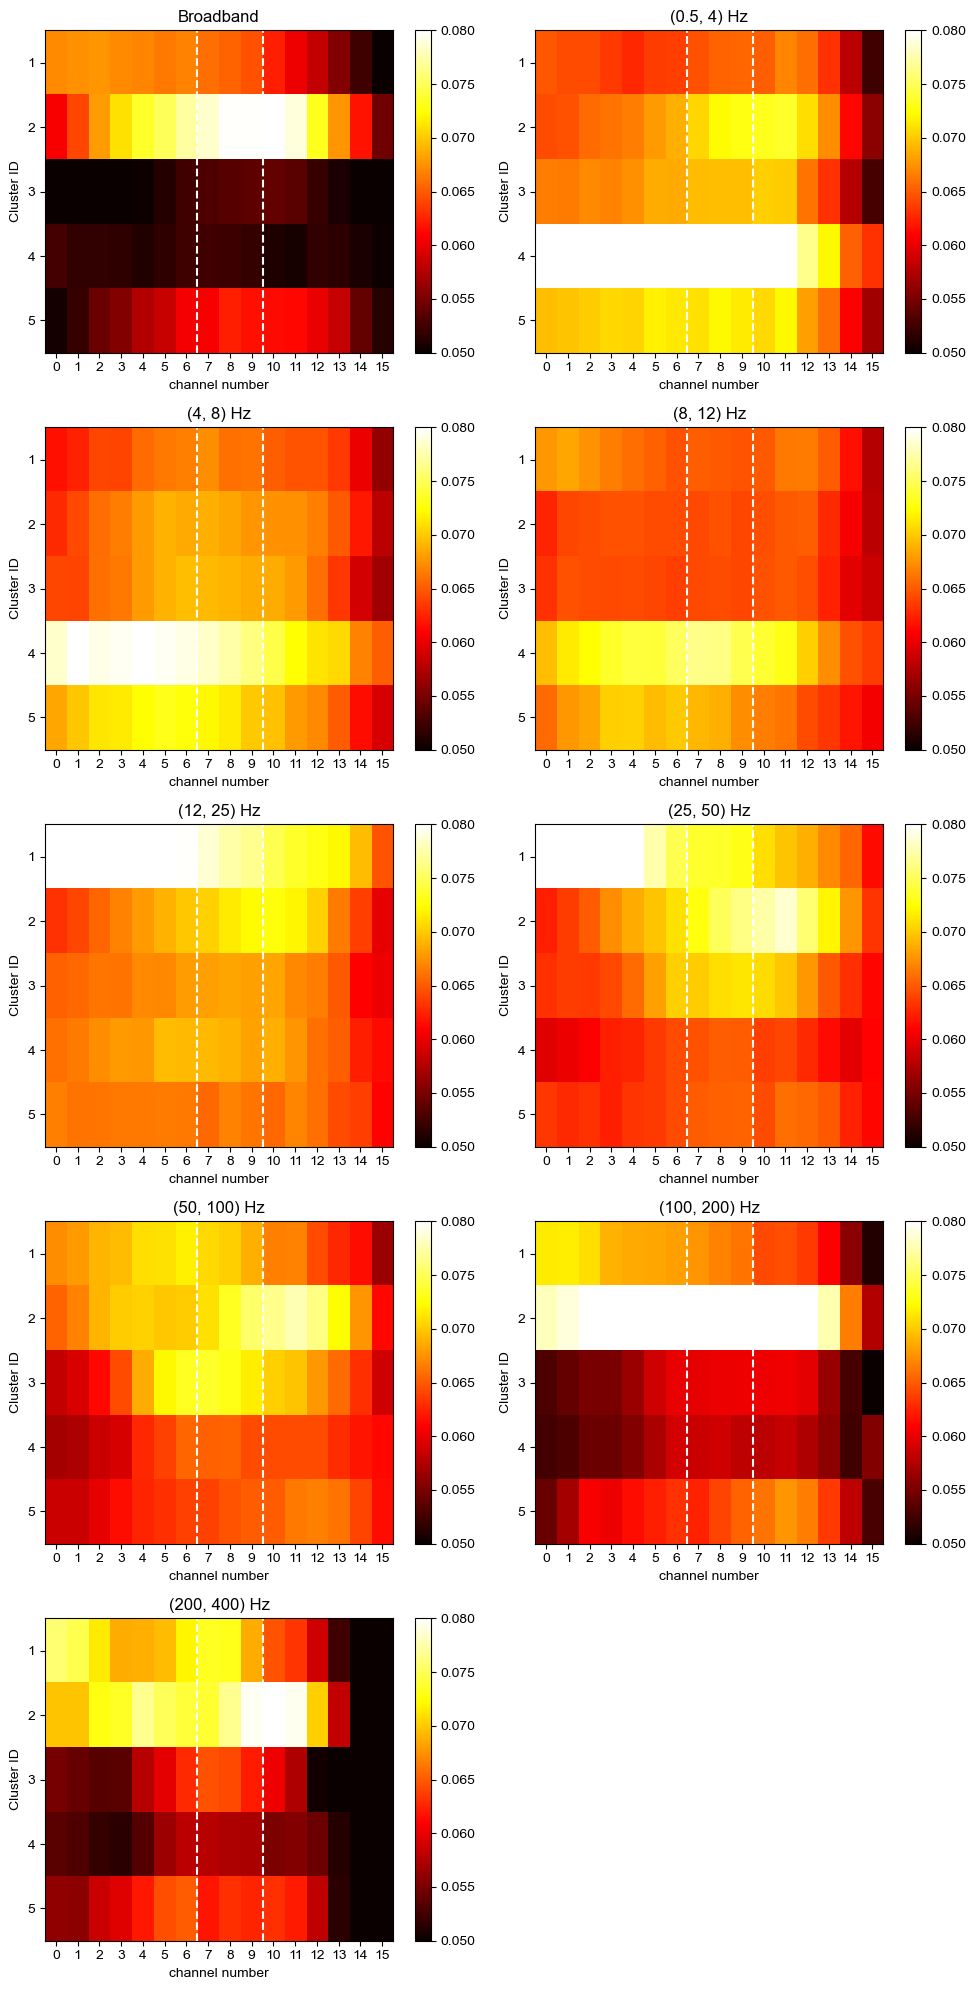

In [86]:
mean_attr_clusters = np.zeros((len(df['cluster_id'].unique())-1, len(bands)+1, chans2keep))
sem_attr_clusters = np.zeros((len(df['cluster_id'].unique())-1, len(bands)+1, chans2keep))

for clusteri in range(1,6):
    for bandi in range(len(bands)+1):
        for chani in range(chans2keep):
            # get the mean of the attribution scores for the cluster, channel and band, ignoring NaN values
            all_vals = df.loc[df['cluster_id'] == clusteri, f'attr_{chani}_{bandi}'].values
            all_vals = np.abs(all_vals)
            mean_attr_clusters[clusteri-1, bandi, chani] = np.nanmean(all_vals)
            sem_attr_clusters[clusteri-1, bandi, chani] = stats.sem(all_vals, nan_policy='omit')
            
            
# plot the mean and sem each cluster broadband all channels
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
# Define colors similar to MATLAB's jet colormap
cluster_colors = ['blue', 'cyan', 'green', 'yellow', 'orange']
for clusteri in range(1,6):
    mean_vals = mean_attr_clusters[clusteri-1, 0, :] # ignore layer 1 
    sem_vals = sem_attr_clusters[clusteri-1, 0, :]
    color = cluster_colors[clusteri-1]
    ax.plot(mean_vals, range(chans2keep), label=f'Cluster {clusteri}', color=color)
    ax.fill_betweenx(range(chans2keep), 
                    mean_vals - sem_vals, 
                    mean_vals + sem_vals, alpha=0.3, color=color)
ax.set_ylabel('Channel Number')
ax.set_xlabel('Mean Attribution Score (Broadband)')
ax.axhline(y=8, color='r', linestyle='--')
ax.axhline(y=12, color='r', linestyle='--')
ax.set_aspect(3.0/ax.get_data_ratio(), adjustable='box')
ax.set_ylim([0, 15])
plt.legend()
plt.savefig(Path(figures_folder) / 'mean_attribution_scores_across_clusters_channels_broadband.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()


fig, ax = plt.subplots(int(np.ceil((len(bands)+1)/2)),2,figsize=(10,20)) 
for bandi in range(len(bands)+1):
    ax.flat[bandi].imshow(mean_attr_clusters[:,bandi,:] , aspect='auto',cmap='hot', vmin=0.05, vmax=0.08)
    # set the xticks to be the channel depths
    ax.flat[bandi].set_xticks(range(chans2keep))
    ax.flat[bandi].set_xlabel('channel number')
    # ax.flat[bandi].set_ylim([.5,4.5])
    if bandi == 0:
        ax.flat[bandi].set_title('Broadband')
    else:
        ax.flat[bandi].set_title(str(bands[bandi-1]) + ' Hz')
    # set the yticks to be the cluster ids
    ax.flat[bandi].set_yticks(range(0,5))
    ax.flat[bandi].set_yticklabels(range(1,6,1))
    ax.flat[bandi].set_ylabel('Cluster ID')
    ax.flat[bandi].axvline(x=6.5, color='w', linestyle='--')
    ax.flat[bandi].axvline(x=9.5, color='w', linestyle='--')
    cbar = fig.colorbar(ax.flat[bandi].imshow(mean_attr_clusters[:,bandi,:], aspect='auto', 
                                              cmap='hot', vmin=0.05, vmax=0.08), ax=ax.flat[bandi])

plt.tight_layout()
fig.delaxes(ax.flat[-1])
plt.savefig(Path(figures_folder) / 'mean_attribution_scores_across_clusters_channels_bands.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

## Train a random forest regression model to predict cluster ID based on the attribution scores

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, balanced_accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Get data
visual_neurons = df[df['structure_acronym'].str.contains('VIS')]
X = []
for i, row in visual_neurons.iterrows():
    attr_vector = []
    for bandi in range(len(bands)+1):
        for chani in range(chans2keep):
            attr_vector.append(row[f'attr_{chani}_{bandi}'])
    X.append(attr_vector)
X = np.array(X)
y = visual_neurons['cluster_id'].values - 1  # 0-indexed

# Remove rows where ALL features are NaN (if any)
valid_rows = ~np.all(np.isnan(X), axis=1)
X = X[valid_rows]
y = y[valid_rows]

def objective(trial, X_train, y_train):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 5, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    
    clf = RandomForestClassifier(
        n_estimators=n_estimators, 
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        class_weight='balanced',  # Handle class imbalance
        random_state=42
    )
    
    # Inner CV for hyperparameter validation
    X_opt_train, X_opt_val, y_opt_train, y_opt_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
    )
    
    # Preprocess inside the fold (no data leakage)
    imputer = SimpleImputer(strategy='median')
    scaler = StandardScaler()
    
    X_opt_train_processed = scaler.fit_transform(imputer.fit_transform(X_opt_train))
    X_opt_val_processed = scaler.transform(imputer.transform(X_opt_val))
    
    clf.fit(X_opt_train_processed, y_opt_train)
    y_pred_opt = clf.predict(X_opt_val_processed)
    
    return balanced_accuracy_score(y_opt_val, y_pred_opt)

# Stratified CV (maintains class balance)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {'balanced_accuracy': [], 'params': []}
y_pred_cv = np.zeros_like(y)

for fold_idx, (train_index, test_index) in enumerate(skf.split(X, y)):
    print(f'Training fold {fold_idx+1}')
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Hyperparameter optimization
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials=30)
    best_params = study.best_params
    
    # Preprocess this fold
    imputer = SimpleImputer(strategy='median')
    scaler = StandardScaler()
    
    X_train_processed = scaler.fit_transform(imputer.fit_transform(X_train))
    X_test_processed = scaler.transform(imputer.transform(X_test))
    
    # Train final model for this fold
    clf = RandomForestClassifier(
        n_estimators=best_params['n_estimators'],
        max_depth=best_params['max_depth'],
        min_samples_split=best_params['min_samples_split'],
        class_weight='balanced',
        random_state=42
    )
    
    clf.fit(X_train_processed, y_train)
    y_pred_fold = clf.predict(X_test_processed)
    y_pred_cv[test_index] = y_pred_fold
    
    acc = balanced_accuracy_score(y_test, y_pred_fold)
    results['balanced_accuracy'].append(acc)
    results['params'].append(best_params)
    print(f'  Fold {fold_idx+1} accuracy: {acc:.4f}')

print(f'\nBalanced accuracy over 5-fold CV: {np.mean(results["balanced_accuracy"]):.3f} ± {np.std(results["balanced_accuracy"]):.3f}')

# Use CV predictions for confusion matrix (no data leakage)
cm = confusion_matrix(y, y_pred_cv)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, 
                             display_labels=[f'Cluster {i+1}' for i in range(5)])
disp.plot(cmap='Blues', values_format=".2f")
plt.title('Confusion Matrix: Predicting Cluster ID from Attribution Scores\n(Cross-Validation Predictions)')
plt.savefig(Path(figures_folder) / 'confusion_matrix_cluster_id_from_attribution_scores.pdf', 
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

Feature matrix shape: (26193, 433)
Target distribution: [6102 8354 4476 3703 3558]
Training fold 1
  Fold 1 accuracy: 0.4123
  Best trial value: 0.4132
Training fold 2
  Fold 2 accuracy: 0.4104
  Best trial value: 0.4080
Training fold 3
  Fold 3 accuracy: 0.3971
  Best trial value: 0.4136
Training fold 4
  Fold 4 accuracy: 0.4017
  Best trial value: 0.4026
Training fold 5
  Fold 5 accuracy: 0.3956
  Best trial value: 0.4133

Enhanced balanced accuracy over 5-fold CV: 0.403 ± 0.007


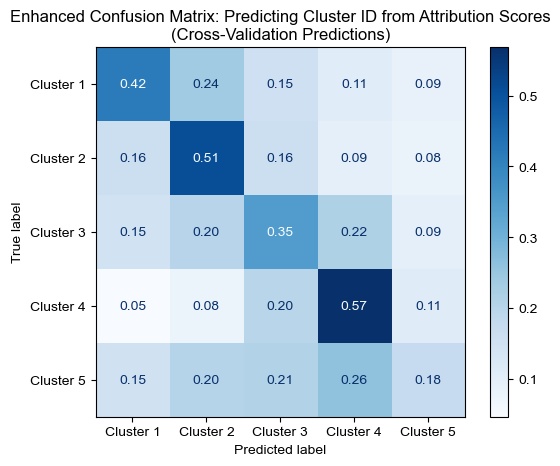

ValueError: operands could not be broadcast together with shapes (190,) (159,) 

In [34]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, balanced_accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.pipeline import Pipeline
import optuna
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Enhanced feature engineering
def create_enhanced_features(visual_neurons, bands, chans2keep):
    """Create enhanced features beyond raw attribution scores"""
    X_raw = []
    X_enhanced = []
    
    for i, row in visual_neurons.iterrows():
        # Raw attribution vector
        attr_vector = []
        for bandi in range(len(bands)+1):
            for chani in range(chans2keep):
                attr_vector.append(row[f'attr_{chani}_{bandi}'])
        
        # Convert to numpy for easier manipulation
        attr_array = np.array(attr_vector).reshape(len(bands)+1, chans2keep)
        
        # Enhanced features
        enhanced_features = []
        
        # 1. Raw features (log-transformed and standardized)
        attr_flat = attr_array.flatten()
        # Handle zeros/negatives for log transform
        attr_abs = np.abs(attr_flat) + 1e-10
        enhanced_features.extend(np.log10(attr_abs))
        
        # 2. Statistical features per frequency band
        for bandi in range(len(bands)+1):
            band_data = attr_array[bandi, :]
            band_abs = np.abs(band_data)
            
            enhanced_features.extend([
                np.mean(band_abs),
                np.std(band_abs),
                np.max(band_abs),
                np.sum(band_abs),
                np.mean(band_abs[:8]),    # Deep channels
                np.mean(band_abs[8:12]),  # Middle channels  
                np.mean(band_abs[12:])    # Superficial channels
            ])
        
        # 3. Cross-frequency features
        for bandi1 in range(len(bands)):
            for bandi2 in range(bandi1+1, len(bands)):
                ratio = np.mean(np.abs(attr_array[bandi1+1, :])) / (np.mean(np.abs(attr_array[bandi2+1, :])) + 1e-10)
                enhanced_features.append(ratio)
        
        # 4. Spatial gradient features
        for bandi in range(len(bands)+1):
            grad = np.gradient(attr_array[bandi, :])
            enhanced_features.extend([
                np.mean(np.abs(grad)),
                np.max(np.abs(grad)),
                np.sum(grad**2)
            ])
        
        # 5. Peak detection features
        for bandi in range(len(bands)+1):
            band_abs = np.abs(attr_array[bandi, :])
            peak_idx = np.argmax(band_abs)
            enhanced_features.extend([
                peak_idx,  # Peak location
                band_abs[peak_idx],  # Peak magnitude
                np.sum(band_abs > 0.5 * band_abs[peak_idx])  # Width at half-max
            ])
        
        X_raw.append(attr_vector)
        X_enhanced.append(enhanced_features)
    
    return np.array(X_raw), np.array(X_enhanced)

# Get enhanced data
visual_neurons = df[df['structure_acronym'].str.contains('VIS')]
X_raw, X_enhanced = create_enhanced_features(visual_neurons, bands, chans2keep)
y = visual_neurons['cluster_id'].values - 1  # 0-indexed

# Combine raw and enhanced features
X = np.hstack([X_raw, X_enhanced])

# Remove rows where ALL features are NaN
valid_rows = ~np.all(np.isnan(X), axis=1)
X = X[valid_rows]
y = y[valid_rows]

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution: {np.bincount(y)}")

def enhanced_objective(trial, X_train, y_train):
    """Enhanced objective with feature selection and ensemble methods"""
    
    # Feature selection
    k_features = trial.suggest_int('k_features', 50, min(200, X_train.shape[1]))
    feature_selection_method = trial.suggest_categorical('feature_selection', ['f_classif', 'mutual_info'])
    
    if feature_selection_method == 'f_classif':
        selector = SelectKBest(f_classif, k=k_features)
    else:
        selector = SelectKBest(mutual_info_classif, k=k_features)
    
    # PCA for dimensionality reduction (optional)
    use_pca = trial.suggest_categorical('use_pca', [True, False])
    if use_pca:
        n_components = trial.suggest_int('n_components', 10, min(50, k_features))
        pca = PCA(n_components=n_components)
    
    # Preprocessing
    scaler_type = trial.suggest_categorical('scaler', ['standard', 'robust'])
    if scaler_type == 'standard':
        scaler = StandardScaler()
    else:
        scaler = RobustScaler()
    
    # Model hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 100, 500)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5])
    
    # Create pipeline
    steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', scaler),
        ('selector', selector)
    ]
    
    if use_pca:
        steps.append(('pca', pca))
    
    steps.append(('classifier', RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )))
    
    pipeline = Pipeline(steps)
    
    # Inner CV for validation
    X_opt_train, X_opt_val, y_opt_train, y_opt_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
    )
    
    pipeline.fit(X_opt_train, y_opt_train)
    y_pred_opt = pipeline.predict(X_opt_val)
    
    return balanced_accuracy_score(y_opt_val, y_pred_opt)

# Enhanced cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {'balanced_accuracy': [], 'params': [], 'feature_importance': []}
y_pred_cv = np.zeros_like(y)

for fold_idx, (train_index, test_index) in enumerate(skf.split(X, y)):
    print(f'Training fold {fold_idx+1}')
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Hyperparameter optimization with more trials
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(lambda trial: enhanced_objective(trial, X_train, y_train), n_trials=100)
    best_params = study.best_params
    
    # Build best pipeline
    if best_params['feature_selection'] == 'f_classif':
        selector = SelectKBest(f_classif, k=best_params['k_features'])
    else:
        selector = SelectKBest(mutual_info_classif, k=best_params['k_features'])
    
    if best_params['scaler'] == 'standard':
        scaler = StandardScaler()
    else:
        scaler = RobustScaler()
    
    steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', scaler),
        ('selector', selector)
    ]
    
    if best_params['use_pca']:
        pca = PCA(n_components=best_params['n_components'])
        steps.append(('pca', pca))
    
    steps.append(('classifier', RandomForestClassifier(
        n_estimators=best_params['n_estimators'],
        max_depth=best_params['max_depth'],
        min_samples_split=best_params['min_samples_split'],
        min_samples_leaf=best_params['min_samples_leaf'],
        max_features=best_params['max_features'],
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )))
    
    pipeline = Pipeline(steps)
    pipeline.fit(X_train, y_train)
    y_pred_fold = pipeline.predict(X_test)
    y_pred_cv[test_index] = y_pred_fold
    
    acc = balanced_accuracy_score(y_test, y_pred_fold)
    results['balanced_accuracy'].append(acc)
    results['params'].append(best_params)
    
    # Store feature importance if available
    try:
        if hasattr(pipeline.named_steps['classifier'], 'feature_importances_'):
            results['feature_importance'].append(pipeline.named_steps['classifier'].feature_importances_)
    except:
        pass
    
    print(f'  Fold {fold_idx+1} accuracy: {acc:.4f}')
    print(f'  Best trial value: {study.best_value:.4f}')

print(f'\nEnhanced balanced accuracy over 5-fold CV: {np.mean(results["balanced_accuracy"]):.3f} ± {np.std(results["balanced_accuracy"]):.3f}')

# Enhanced confusion matrix
cm = confusion_matrix(y, y_pred_cv)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, 
                             display_labels=[f'Cluster {i+1}' for i in range(5)])
disp.plot(cmap='Blues', values_format=".2f")
plt.title('Enhanced Confusion Matrix: Predicting Cluster ID from Attribution Scores\n(Cross-Validation Predictions)')
plt.savefig(Path(figures_folder) / 'enhanced_confusion_matrix_cluster_id_from_attribution_scores.pdf', 
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot feature importance summary
if results['feature_importance']:
    mean_importance = np.mean(results['feature_importance'], axis=0)
    std_importance = np.std(results['feature_importance'], axis=0)
    
    # Get top features
    top_indices = np.argsort(mean_importance)[-20:]
    
    plt.figure(figsize=(10, 8))
    plt.barh(range(len(top_indices)), mean_importance[top_indices])
    plt.yticks(range(len(top_indices)), [f'Feature {i}' for i in top_indices])
    plt.xlabel('Feature Importance')
    plt.title('Top 20 Feature Importances (Average across folds)')
    plt.tight_layout()
    plt.savefig(Path(figures_folder) / 'enhanced_feature_importance.pdf', 
                format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ------- ------------------------------- 19.7/101.7 MB 103.7 MB/s eta 0:00:01
   ---------------- ---------------------- 42.2/101.7 MB 103.3 MB/s eta 0:00:01
   ------------------------- ------------- 66.3/101.7 MB 111.2 MB/s eta 0:00:01
   ---------------------------------- ---- 89.7/101.7 MB 110.1 MB/s eta 0:00:01
   -------------------------------------  101.4/101.7 MB 108.0 MB/s eta 0:00:01
   ---------------------------------------- 101.7/101.7 MB 92.7 MB/s  0:00:01


c:\Users\SB13FLPC018\miniconda3\envs\spikes2lfp\lib\site-packages\xgboost\training.py:200: UserWarning: [12:19:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\SB13FLPC018\miniconda3\envs\spikes2lfp\lib\site-packages\xgboost\training.py:200: UserWarning: [12:19:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\SB13FLPC018\miniconda3\envs\spikes2lfp\lib\site-packages\xgboost\training.py:200: UserWarning: [12:19:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\SB13FLPC018\miniconda3\envs\spikes2lfp\lib\site-packages\xgboost\training.py:200: UserWarning: [12:19:18] WARNING: C:\actions-runner\_work\xgboost\xgbo

Fold 1 Balanced Accuracy: 0.3811


c:\Users\SB13FLPC018\miniconda3\envs\spikes2lfp\lib\site-packages\xgboost\training.py:200: UserWarning: [12:22:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\SB13FLPC018\miniconda3\envs\spikes2lfp\lib\site-packages\xgboost\training.py:200: UserWarning: [12:22:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\SB13FLPC018\miniconda3\envs\spikes2lfp\lib\site-packages\xgboost\training.py:200: UserWarning: [12:22:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\SB13FLPC018\miniconda3\envs\spikes2lfp\lib\site-packages\xgboost\training.py:200: UserWarning: [12:23:13] WARNING: C:\actions-runner\_work\xgboost\xgbo

Fold 2 Balanced Accuracy: 0.3951


...

Fold 3 Balanced Accuracy: 0.3760


c:\Users\SB13FLPC018\miniconda3\envs\spikes2lfp\lib\site-packages\xgboost\training.py:200: UserWarning: [12:35:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\SB13FLPC018\miniconda3\envs\spikes2lfp\lib\site-packages\xgboost\training.py:200: UserWarning: [12:35:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\SB13FLPC018\miniconda3\envs\spikes2lfp\lib\site-packages\xgboost\training.py:200: UserWarning: [12:35:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\SB13FLPC018\miniconda3\envs\spikes2lfp\lib\site-packages\xgboost\training.py:200: UserWarning: [12:36:10] WARNING: C:\actions-runner\_work\xgboost\xgbo

Fold 4 Balanced Accuracy: 0.3745


c:\Users\SB13FLPC018\miniconda3\envs\spikes2lfp\lib\site-packages\xgboost\training.py:200: UserWarning: [12:41:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\SB13FLPC018\miniconda3\envs\spikes2lfp\lib\site-packages\xgboost\training.py:200: UserWarning: [12:41:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\SB13FLPC018\miniconda3\envs\spikes2lfp\lib\site-packages\xgboost\training.py:200: UserWarning: [12:41:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\SB13FLPC018\miniconda3\envs\spikes2lfp\lib\site-packages\xgboost\training.py:200: UserWarning: [12:42:03] WARNING: C:\actions-runner\_work\xgboost\xgbo

Fold 5 Balanced Accuracy: 0.3781

Mean Balanced Accuracy: 0.381 ± 0.007


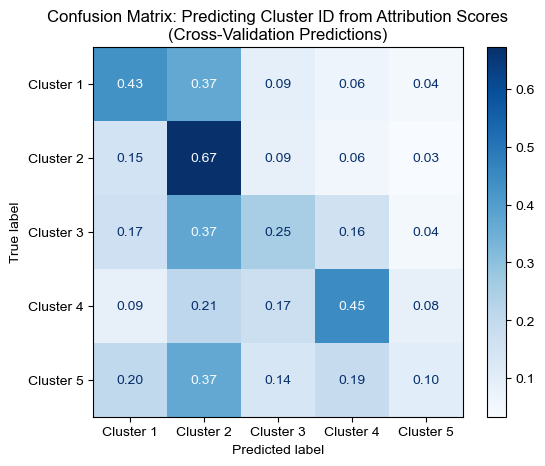

In [ ]:
# try again but with XGBoost classifier
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
%pip install xgboost
from xgboost import XGBClassifier
import optuna
from pathlib import Path

# --- PREPARATION ---
visual_neurons = df[df['structure_acronym'].str.contains('VIS')]
X = []
for i, row in visual_neurons.iterrows():
    attr_vector = []
    for bandi in range(len(bands)+1):
        for chani in range(chans2keep):
            attr_vector.append(row[f'attr_{chani}_{bandi}'])
    X.append(attr_vector)

X = np.array(X)
y = visual_neurons['cluster_id'].values - 1  # 0-indexed

# Remove invalid rows
valid_rows = ~np.all(np.isnan(X), axis=1)
X = X[valid_rows]
y = y[valid_rows]

def objective(trial, X_train, y_train):
    # Expanded hyperparameter space for XGBoost
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'use_label_encoder': False,
        'eval_metric': 'mlogloss',
        'random_state': 42,
        'tree_method': 'hist', # Faster training
    }

    # Suggest number of PCA components to reduce noise/correlation
    # Using 0.95 to keep 95% of variance
    n_pca = trial.suggest_int('n_pca', 10, min(50, X_train.shape[1]))

    X_opt_train, X_opt_val, y_opt_train, y_opt_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
    )

    # Pipeline-like processing inside Optuna
    imputer = SimpleImputer(strategy='median')
    scaler = StandardScaler()
    pca = PCA(n_components=n_pca)
    
    X_opt_train_p = pca.fit_transform(scaler.fit_transform(imputer.fit_transform(X_opt_train)))
    X_opt_val_p = pca.transform(scaler.transform(imputer.transform(X_opt_val)))

    clf = XGBClassifier(**param)
    clf.fit(X_opt_train_p, y_opt_train)
    
    y_pred = clf.predict(X_opt_val_p)
    return balanced_accuracy_score(y_opt_val, y_pred)

# --- EXECUTION ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = np.zeros_like(y)
fold_scores = []

for fold_idx, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials=50)
    
    best_p = study.best_params
    n_pca = best_p.pop('n_pca') # Remove PCA param to pass remaining to XGB
    
    # Final processing for this fold
    imputer = SimpleImputer(strategy='median')
    scaler = StandardScaler()
    pca = PCA(n_components=n_pca)
    
    X_train_p = pca.fit_transform(scaler.fit_transform(imputer.fit_transform(X_train)))
    X_test_p = pca.transform(scaler.transform(imputer.transform(X_test)))
    
    clf = XGBClassifier(**best_p, random_state=42, tree_method='hist')
    clf.fit(X_train_p, y_train)
    
    y_pred_cv[test_index] = clf.predict(X_test_p)
    acc = balanced_accuracy_score(y_test, y_pred_cv[test_index])
    fold_scores.append(acc)
    print(f"Fold {fold_idx+1} Balanced Accuracy: {acc:.4f}")

print(f"\nMean Balanced Accuracy: {np.mean(fold_scores):.3f} ± {np.std(fold_scores):.3f}")

# Use CV predictions for confusion matrix (no data leakage)
cm = confusion_matrix(y, y_pred_cv)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, 
                             display_labels=[f'Cluster {i+1}' for i in range(5)])
disp.plot(cmap='Blues', values_format=".2f")
plt.title('Confusion Matrix: Predicting Cluster ID from Attribution Scores\n(Cross-Validation Predictions)')
plt.savefig(Path(figures_folder) / 'confusion_matrix_cluster_id_from_attribution_scores_xgb.pdf', 
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

## repeat the above analysis but for layers rather than clusters


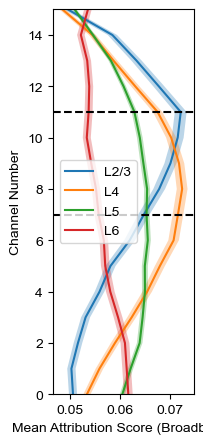

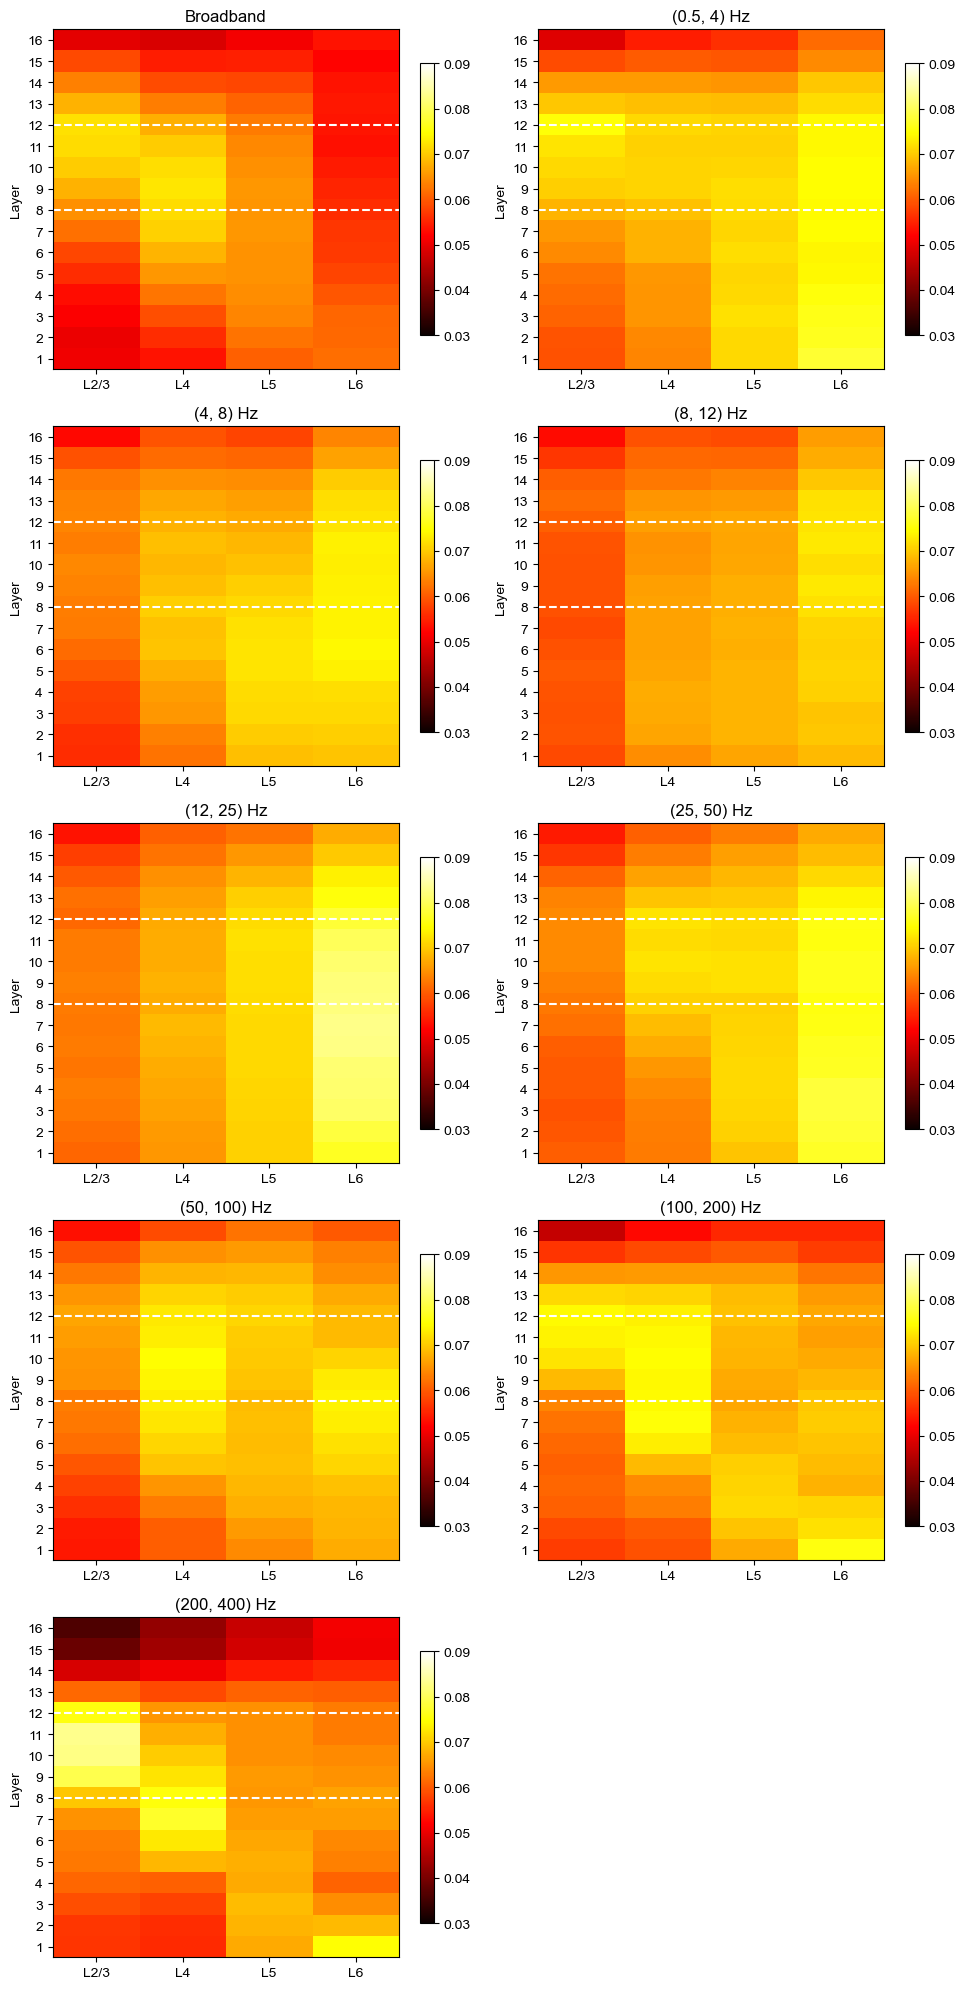

In [81]:
ALL_Layers = sorted(df['layer'][~df['layer'].isna()].unique())
mean_attr_layers = np.zeros((len(ALL_Layers), len(bands)+1, chans2keep))
sem_attr_layers = np.zeros_like(mean_attr_layers)

for idx, layeri in enumerate(ALL_Layers):
    for bandi in range(len(bands)+1):
        for chani in range(chans2keep):
            # get the mean of the attribution scores for the cluster, channel and band, ignoring NaN values
            # all_vals = df.loc[df['layer'] == layeri, f'attr_{chani}_{bandi}'].values
            all_vals = df.loc[(df['layer'] == layeri), f'attr_{chani}_{bandi}'].values # optionally restrict to VISp
            mean_attr_layers[idx, bandi, chani] = np.nanmean(np.abs(all_vals))
            sem_attr_layers[idx, bandi, chani] = np.nanstd(np.abs(all_vals)) / np.sqrt(len(all_vals))

# plot the mean and sem for layer 2/3, 4, 5 and 6 broadband all channels
layer_labels = ['L2/3', 'L4', 'L5', 'L6']
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for idx, layeri in enumerate(ALL_Layers[1:]):
    mean_vals = mean_attr_layers[idx+1, 0, :] # ignore layer 1 
    sem_vals = sem_attr_layers[idx+1, 0, :]
    ax.plot(mean_vals, range(chans2keep), label=layer_labels[idx])
    ax.fill_betweenx(range(chans2keep), 
                     mean_vals - sem_vals, 
                     mean_vals + sem_vals, alpha=0.3)
ax.set_xlabel('Mean Attribution Score (Broadband)')
ax.set_ylabel('Channel Number')
ax.set_aspect(3.0/ax.get_data_ratio(), adjustable='box')
ax.axhline(y=7, color='k', linestyle='--')
ax.axhline(y=11, color='k', linestyle='--')
ax.set_ylim([0, 15])
plt.legend()
plt.savefig(Path(figures_folder) / 'mean_attribution_scores_across_layers_channels_broadband.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()



fig, ax = plt.subplots(int(np.ceil((len(bands)+1)/2)),2,figsize=(10,20)) 
for bandi in range(len(bands)+1):
    ax.flat[bandi].imshow(mean_attr_layers[:,bandi,:].T , aspect='auto',cmap='hot', vmin=0.03, vmax=0.09)
    # set the xticks to be the channel depths
    ax.flat[bandi].set_yticks(range(chans2keep))
    ax.flat[bandi].set_yticklabels(range(1, chans2keep+1))
    ax.flat[bandi].set_ylabel('channel number')
    ax.flat[bandi].set_xlim([.5,4.5])
    if bandi == 0:
        ax.flat[bandi].set_title('Broadband')
    else:
        ax.flat[bandi].set_title(str(bands[bandi-1]) + ' Hz')
    # set the yticks to be the cluster ids
    ax.flat[bandi].set_xticks(range(1,5,1))
    ax.flat[bandi].set_xticklabels(layer_labels)
    ax.flat[bandi].set_ylabel('Layer')
    ax.flat[bandi].axhline(y=7, color='w', linestyle='--')
    ax.flat[bandi].axhline(y=11, color='w', linestyle='--')
    cbar = fig.colorbar(ax.flat[bandi].imshow(mean_attr_layers[:,bandi,:].T, aspect='auto', 
                                              cmap='hot', vmin=0.03, vmax=0.09), ax=ax.flat[bandi], shrink=0.8)
    ax.flat[bandi].invert_yaxis()

plt.tight_layout()
fig.delaxes(ax.flat[-1])
plt.savefig(Path(figures_folder) / 'mean_attribution_scores_across_layers_channels_bands.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

## Train a random forest regression model to predict layer identity based on the attribution scores

In [ ]:
# classify layer identity (2/3 vs 4 vs 5 vs 6) using the attribution scores with a random forest classifier and cross-validation
# Get data and filter for specific layers
visual_neurons = df[df['structure_acronym'].str.contains('VIS')]

# Filter for layers 2, 4, 5, 6 only (exclude layer 1 and NaN)
target_layers = [2, 4, 5, 6]
layer_mask = visual_neurons['layer'].isin(target_layers)
visual_neurons_layers = visual_neurons[layer_mask]

print(f"Layer distribution:")
print(visual_neurons_layers['layer'].value_counts().sort_index())

# Build feature matrix
X = []
for i, row in visual_neurons_layers.iterrows():
    attr_vector = []
    for bandi in range(len(bands)+1):
        for chani in range(chans2keep):
            attr_vector.append(row[f'attr_{chani}_{bandi}'])
    X.append(attr_vector)
X = np.array(X)

# Map layers [2, 4, 5, 6] to [0, 1, 2, 3] for sklearn
layer_to_index = {2: 0, 4: 1, 5: 2, 6: 3}
y = visual_neurons_layers['layer'].map(layer_to_index).values

# Remove rows where ALL features are NaN (if any)
valid_rows = ~np.all(np.isnan(X), axis=1)
X = X[valid_rows]
y = y[valid_rows]

def objective(trial, X_train, y_train):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 5, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    
    clf = RandomForestClassifier(
        n_estimators=n_estimators, 
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        class_weight='balanced',  # Handle class imbalance
        random_state=42
    )
    
    # Inner CV for hyperparameter validation
    X_opt_train, X_opt_val, y_opt_train, y_opt_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
    )
    
    # Preprocess inside the fold (no data leakage)
    imputer = SimpleImputer(strategy='median')
    scaler = StandardScaler()
    
    X_opt_train_processed = scaler.fit_transform(imputer.fit_transform(X_opt_train))
    X_opt_val_processed = scaler.transform(imputer.transform(X_opt_val))
    
    clf.fit(X_opt_train_processed, y_opt_train)
    y_pred_opt = clf.predict(X_opt_val_processed)
    
    return balanced_accuracy_score(y_opt_val, y_pred_opt)

# Stratified CV (maintains class balance)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {'balanced_accuracy': [], 'params': []}
y_pred_cv = np.zeros_like(y)

for fold_idx, (train_index, test_index) in enumerate(skf.split(X, y)):
    print(f'Training fold {fold_idx+1}')
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Hyperparameter optimization
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials=30)
    best_params = study.best_params
    
    # Preprocess this fold
    imputer = SimpleImputer(strategy='median')
    scaler = StandardScaler()
    
    X_train_processed = scaler.fit_transform(imputer.fit_transform(X_train))
    X_test_processed = scaler.transform(imputer.transform(X_test))
    
    # Train final model for this fold
    clf = RandomForestClassifier(
        n_estimators=best_params['n_estimators'],
        max_depth=best_params['max_depth'],
        min_samples_split=best_params['min_samples_split'],
        class_weight='balanced',
        random_state=42
    )
    
    clf.fit(X_train_processed, y_train)
    y_pred_fold = clf.predict(X_test_processed)
    y_pred_cv[test_index] = y_pred_fold
    
    acc = balanced_accuracy_score(y_test, y_pred_fold)
    results['balanced_accuracy'].append(acc)
    results['params'].append(best_params)
    print(f'  Fold {fold_idx+1} accuracy: {acc:.4f}')

print(f'\nBalanced accuracy over 5-fold CV: {np.mean(results["balanced_accuracy"]):.3f} ± {np.std(results["balanced_accuracy"]):.3f}')

# Use CV predictions for confusion matrix (no data leakage)
cm = confusion_matrix(y, y_pred_cv)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# Create layer labels for confusion matrix
layer_labels = ['L2/3', 'L4', 'L5', 'L6']
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=layer_labels)
disp.plot(cmap='Blues', values_format=".2f")
plt.title('Confusion Matrix: Predicting Layer from Attribution Scores\n(Cross-Validation Predictions)')
plt.savefig(Path(figures_folder) / 'confusion_matrix_layer_id_from_attribution_scores.pdf', 
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

## Train a random forest regression model to predict anatomical area (VIS only) based on the attribution scores

Visual area distribution:
VISal    4109
VISam    4395
VISl     4334
VISp     4565
VISpm    5087
VISrl    3360
Name: structure_acronym, dtype: int64
Training fold 1
  Fold 1 accuracy: 0.3552
Training fold 2
  Fold 2 accuracy: 0.3449
Training fold 3
  Fold 3 accuracy: 0.3561
Training fold 4
  Fold 4 accuracy: 0.3405
Training fold 5
  Fold 5 accuracy: 0.3530

Balanced accuracy over 5-fold CV: 0.350 ± 0.006


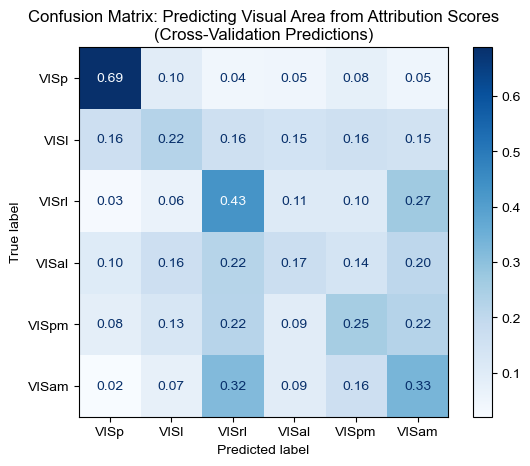

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, balanced_accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

visual_neurons = df[df['structure_acronym'].str.contains('VIS')]

# Filter for specific visual areas
target_areas = ['VISp', 'VISl', 'VISrl', 'VISal', 'VISpm', 'VISam']
area_mask = visual_neurons['structure_acronym'].isin(target_areas)
visual_neurons_areas = visual_neurons[area_mask]

print(f"Visual area distribution:")
print(visual_neurons_areas['structure_acronym'].value_counts().sort_index())

# Build feature matrix
X = []
for i, row in visual_neurons_areas.iterrows():
    attr_vector = []
    for bandi in range(len(bands)+1):
        for chani in range(chans2keep):
            attr_vector.append(row[f'attr_{chani}_{bandi}'])
    X.append(attr_vector)
X = np.array(X)

# Map visual areas to indices for sklearn
area_to_index = {'VISp': 0, 'VISl': 1, 'VISrl': 2, 'VISal': 3, 'VISpm': 4, 'VISam': 5}
y = visual_neurons_areas['structure_acronym'].map(area_to_index).values

# Remove rows where ALL features are NaN (if any)
valid_rows = ~np.all(np.isnan(X), axis=1)
X = X[valid_rows]
y = y[valid_rows]

def objective(trial, X_train, y_train):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 5, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    
    clf = RandomForestClassifier(
        n_estimators=n_estimators, 
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        class_weight='balanced',  # Handle class imbalance
        random_state=42
    )
    
    # Inner CV for hyperparameter validation
    X_opt_train, X_opt_val, y_opt_train, y_opt_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
    )
    
    # Preprocess inside the fold (no data leakage)
    imputer = SimpleImputer(strategy='median')
    scaler = StandardScaler()
    
    X_opt_train_processed = scaler.fit_transform(imputer.fit_transform(X_opt_train))
    X_opt_val_processed = scaler.transform(imputer.transform(X_opt_val))
    
    clf.fit(X_opt_train_processed, y_opt_train)
    y_pred_opt = clf.predict(X_opt_val_processed)
    
    return balanced_accuracy_score(y_opt_val, y_pred_opt)

# Stratified CV (maintains class balance)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {'balanced_accuracy': [], 'params': []}
y_pred_cv = np.zeros_like(y)

for fold_idx, (train_index, test_index) in enumerate(skf.split(X, y)):
    print(f'Training fold {fold_idx+1}')
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Hyperparameter optimization
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials=30)
    best_params = study.best_params
    
    # Preprocess this fold
    imputer = SimpleImputer(strategy='median')
    scaler = StandardScaler()
    
    X_train_processed = scaler.fit_transform(imputer.fit_transform(X_train))
    X_test_processed = scaler.transform(imputer.transform(X_test))
    
    # Train final model for this fold
    clf = RandomForestClassifier(
        n_estimators=best_params['n_estimators'],
        max_depth=best_params['max_depth'],
        min_samples_split=best_params['min_samples_split'],
        class_weight='balanced',
        random_state=42
    )
    
    clf.fit(X_train_processed, y_train)
    y_pred_fold = clf.predict(X_test_processed)
    y_pred_cv[test_index] = y_pred_fold
    
    acc = balanced_accuracy_score(y_test, y_pred_fold)
    results['balanced_accuracy'].append(acc)
    results['params'].append(best_params)
    print(f'  Fold {fold_idx+1} accuracy: {acc:.4f}')

print(f'\nBalanced accuracy over 5-fold CV: {np.mean(results["balanced_accuracy"]):.3f} ± {np.std(results["balanced_accuracy"]):.3f}')

# Use CV predictions for confusion matrix (no data leakage)
cm = confusion_matrix(y, y_pred_cv)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# Create visual area labels for confusion matrix
area_labels = ['VISp', 'VISl', 'VISrl', 'VISal', 'VISpm', 'VISam']
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=area_labels)
disp.plot(cmap='Blues', values_format=".2f")
plt.title('Confusion Matrix: Predicting Visual Area from Attribution Scores\n(Cross-Validation Predictions)')
plt.savefig(Path(figures_folder) / 'confusion_matrix_visual_area_from_attribution_scores.pdf', 
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

## Peri-stimulus Jaccard Index analysis  

In [ ]:
session = 1044385384
path2_snippets = Path(basepath) / 'Jaccard_analysis' / f'session_{session}_jaccard_ref_snippets.npy'
snippets = np.load(path2_snippets, allow_pickle=True) # stim x time x channels

bin_size = 0.004
time_win = [-.25, .5]
t = np.arange(time_win[0], time_win[1], bin_size)

chani = 5
# plot all snippets for channel 5 overlaid with the mean snippet
fig, ax = plt.subplots(figsize=(8,5))
ax.imshow(snippets[:, :, chani], aspect='auto', cmap='viridis', extent=[t[0], t[-1], 0, snippets.shape[0]])
cbar = plt.colorbar(ax.images[0], ax=ax)
cbar.set_label('Jaccard Similarity')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Stimulus Number')
ax.plot(t, np.mean(snippets[:, :, chani], axis=0) * snippets.shape[0]  +500, 'w', linewidth=2)
ax.axvline(0, color='k', linestyle='--', linewidth=1.5, label='Stimulus Onset')
ax.axvline(0.25, color='k', linestyle='--', linewidth=1.5, label='Stimulus Onset')
ax.set_aspect(1.0/ax.get_data_ratio(), adjustable='box')
plt.tight_layout()
plt.savefig(Path(figures_folder) / f'jaccard_snippets_session_{session}_channel_{chani}.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# same but for high voltage spindles events
session = 1087720624 #1087720624
path2_snippets = Path(basepath) / 'Jaccard_analysis' / f'{session}_jaccard_ref_snippets_hvs.npy'
snippets = np.load(path2_snippets, allow_pickle=True) # stim x time x channels

bin_size = 0.004
time_win = [-1, 1]
t = np.arange(time_win[0], time_win[1], bin_size)

chani = 0
# plot all snippets for channel 5 overlaid with the mean snippet
fig, ax = plt.subplots(figsize=(8,5))
ax.imshow(snippets[:, :, chani], aspect='auto', cmap='viridis', extent=[t[0], t[-1], 0, snippets.shape[0]])
cbar = plt.colorbar(ax.images[0], ax=ax)
cbar.set_label('Jaccard Similarity')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Event Number')
ax.plot(t, np.mean(snippets[:, :, chani], axis=0) * snippets.shape[0]*2 + 40, 'w', linewidth=2)
# ax.axvline(0, color='k', linestyle='--', linewidth=1.5, label='Stimulus Onset')
# ax.axvline(0.25, color='k', linestyle='--', linewidth=1.5, label='Stimulus Onset')
ax.set_aspect(1.0/ax.get_data_ratio(), adjustable='box')
plt.tight_layout()
plt.savefig(Path(figures_folder) / f'jaccard_snippets_hvs_session_{session}_channel_{chani}.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

## Correlation with hierarchy score

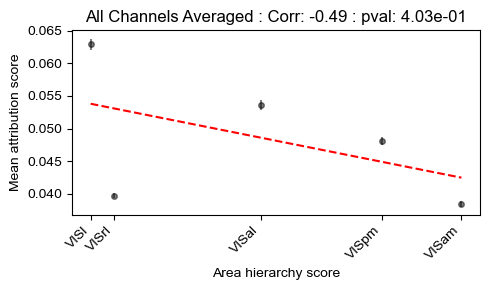

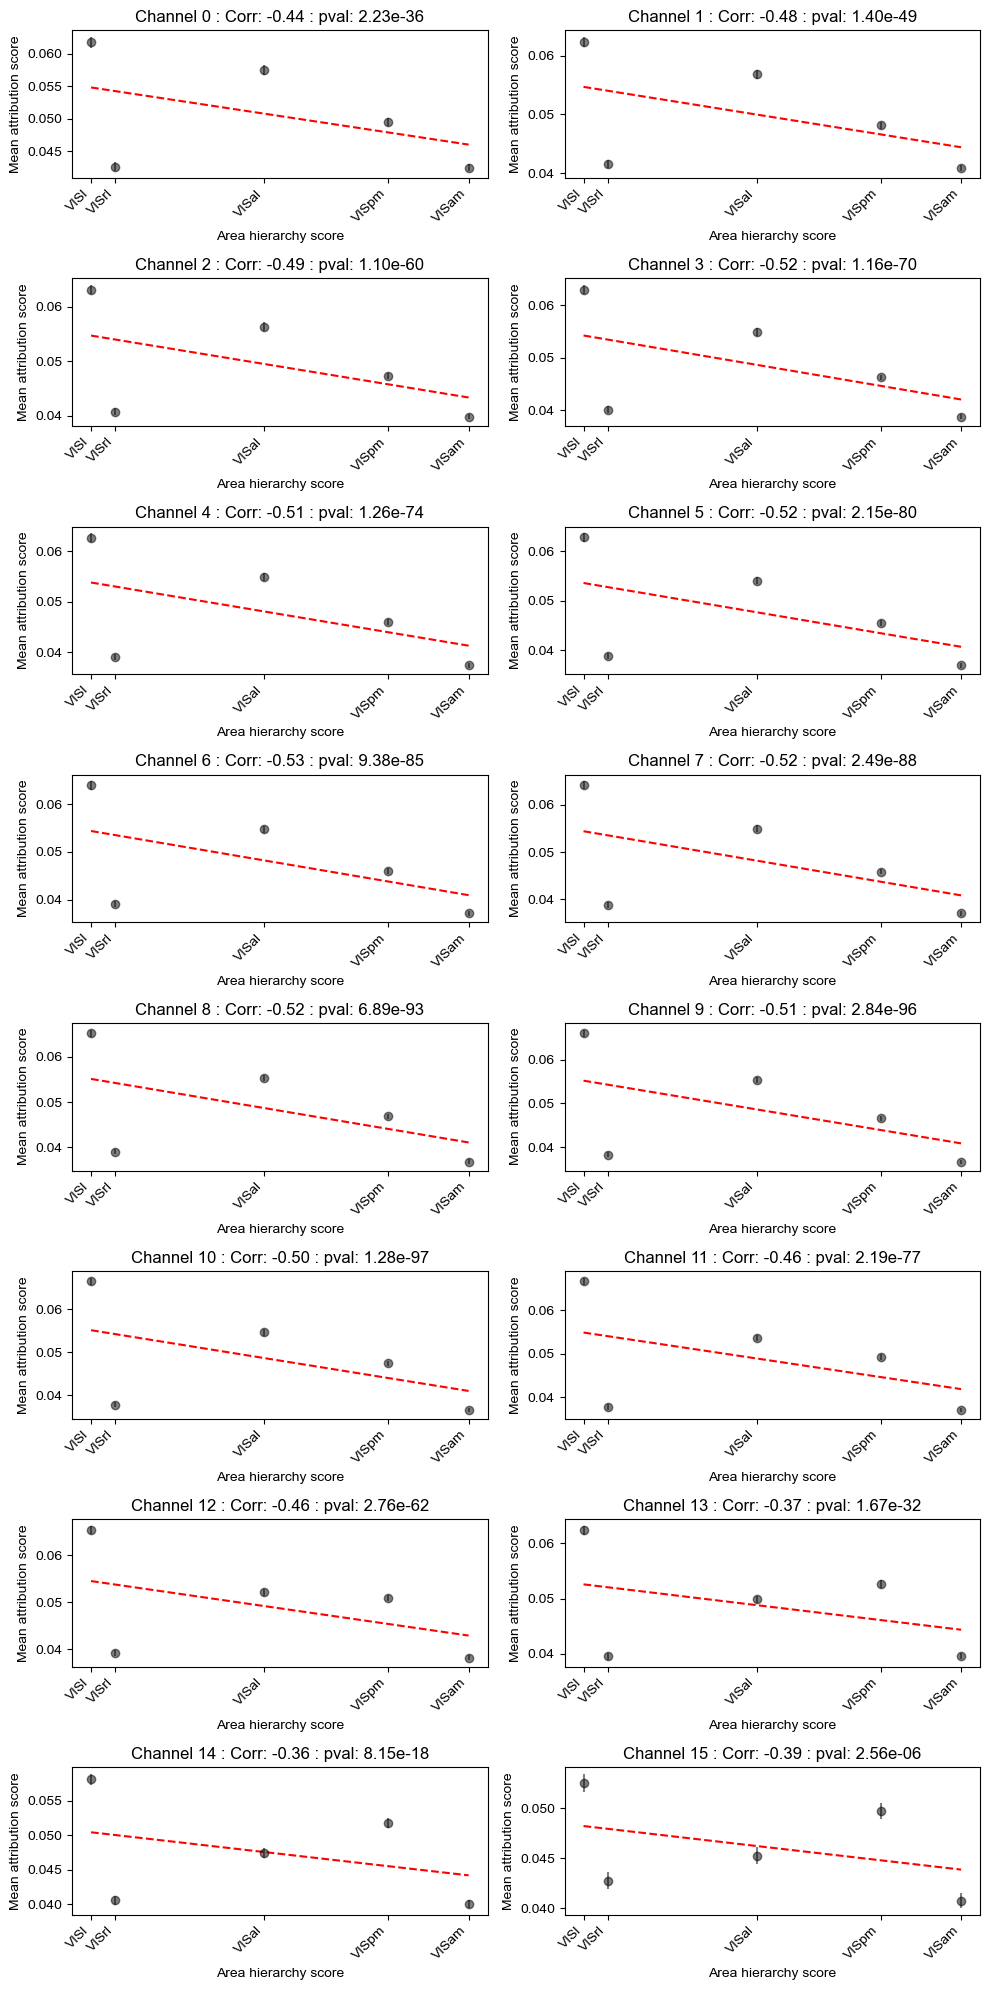

In [ ]:
from scipy.stats import pearsonr

hierarchy_score = {
                #    'LG' : -0.515,
                #    'VISp' : -0.357,
                   'VISl' : -0.093,
                   'VISrl' : -0.059,
                #    'LP' : 0.105,
                   'VISal' : 0.152,
                   'VISpm' : 0.327,
                   'VISam' : 0.441}

bandi = 0
# for each area in hierarchy_score, calculate the average attribution score plus the standard deviation
area_vals = {}
for area in hierarchy_score.keys():
    num_units_in_area = (df['structure_acronym'] == area).sum()
    area_vals[area] = np.zeros((chans2keep, num_units_in_area))
    for chani in range(chans2keep):
        area_vals[area][chani, :] = df.loc[df['structure_acronym'] == area, f'attr_{chani}_{bandi}'].values

# Compute mean and SEM for each area and channel
area_mean = np.zeros((chans2keep, len(hierarchy_score)))
area_sem  = np.zeros((chans2keep, len(hierarchy_score)))
for i, area in enumerate(hierarchy_score.keys()):
    for chani in range(chans2keep):
        vals = np.abs(area_vals[area][chani, :])
        area_mean[chani, i] = np.nanmean(vals)
        area_sem[chani, i]  = np.nanstd(vals) / np.sqrt(np.sum(~np.isnan(vals)))

all_chans_mean = np.nanmean(area_mean, axis=0)
all_chans_sem  = np.nanstd(area_mean, axis=0) / np.sqrt(np.sum(~np.isnan(area_mean), axis=0))

#plot mean attribution score vs hierarchy score averaged across all channels with error bars
fig, ax = plt.subplots(figsize=(5,3))
ax.errorbar(list(hierarchy_score.values()), all_chans_mean, yerr=all_chans_sem, 
            color='k', fmt='o', alpha=0.5, markersize=4)
# add a linear fit line
slope, intercept = np.polyfit(list(hierarchy_score.values()), all_chans_mean, 1)
x_fit = np.linspace(min(hierarchy_score.values()), max(hierarchy_score.values()), 100)
y_fit = slope * x_fit + intercept
# add a correlation coefficient to the plot
corr , pval = pearsonr(all_chans_mean, list(hierarchy_score.values()))
ax.plot(x_fit, y_fit, color='red', linestyle='--',
        label=f'R2: {r2_score(all_chans_mean, slope * np.array(list(hierarchy_score.values())) + intercept):.2f}')
ax.set_xlabel('Area hierarchy score')
ax.set_title(f'All Channels Averaged' + f' : Corr: {corr:.2f}' + f' : pval: {pval:.2e}')
ax.set_xticks(list(hierarchy_score.values()), list(hierarchy_score.keys()), rotation=45, ha='right')
ax.set_ylabel('Mean attribution score')
plt.tight_layout()
plt.show()

# # Plot mean attribution score vs hierarchy score for each channel with error bars
# fig, ax = plt.subplots(int(chans2keep/2), 2, figsize=(10, 20))
# for chani in range(chans2keep):
#     ax.flat[chani].errorbar(list(hierarchy_score.values()), area_mean[chani, :], 
#                             yerr=area_sem[chani, :], color = 'k', fmt='o', alpha=0.5)
#     # add a linear fit line
#     slope, intercept = np.polyfit(list(hierarchy_score.values()), area_mean[chani, :], 1)
#     x_fit = np.linspace(min(hierarchy_score.values()), max(hierarchy_score.values()), 100)
#     y_fit = slope * x_fit + intercept
#     # add a correlation coefficient to the plot using all the data points not just the mean, by concatenating the area_mean[chani, :] and hierarchy_score.values()
#     vals = []
#     scores = []
#     for area in hierarchy_score.keys():
#         tmp = np.abs(area_vals[area][chani, :])
#         vals.append(tmp[~np.isnan(tmp)])
#         scores.append(hierarchy_score[area] * np.ones(len(tmp[~np.isnan(tmp)])))
#     corr , pval = pearsonr(np.concatenate(vals), np.concatenate(scores))
#     # add a correlation of the mean
#     mean_corr = np.corrcoef(area_mean[chani, :], list(hierarchy_score.values()))[0, 1]
    
#     ax.flat[chani].plot(x_fit, y_fit, color='red', linestyle='--', label=f'R2: {r2_score(area_mean[chani, :], slope * np.array(list(hierarchy_score.values())) + intercept):.2f}')
#     ax.flat[chani].set_xlabel('Area hierarchy score')
#     ax.flat[chani].set_title(f'Channel {chani}' + f' : Corr: {mean_corr:.2f}' + f' : pval: {pval:.2e}')
#     ax.flat[chani].set_xticks(list(hierarchy_score.values()), list(hierarchy_score.keys()), rotation=45, ha='right')
#     ax.flat[chani].set_ylabel('Mean attribution score')
# plt.tight_layout()
# plt.savefig(Path(figures_folder) / 'attribution_scores_vs_hierarchy_score_across_channels.pdf', format='pdf', dpi=300, bbox_inches='tight')
# plt.show()

## Investigate correlations between attribution and various metrics

In [ ]:
# from sklearn.preprocessing import MinMaxScaler
# scaler = MinMaxScaler()

# metrics = ['firing_rate', 'response_mag', 'sparsity', 'coupling_index', 'acg_tau_rise', 'acg_tau_decay','stLFP', 'stPR',
#            'normalized_depth','cv2','firingRateISI','thetaModulationIndex','burstIndex_Royer2012','burstIndex_Mizuseki2012', 
#            'fanoFactor', 'speedScore', 'pupilScore', 'coher_2_5', 'coher_5_10']

# chani = 5
# for metric in metrics:
#     fig, ax = plt.subplots(int(np.ceil(len(unique_areas)/5)), 5, figsize=(10, 20))
#     for i, regi in enumerate(unique_areas):
#         regidx = df['structure_acronym'] == regi
#         # get the attribution scores for the region, channel and band
#         attr = np.abs(df.loc[regidx, f'attr_{chani}_{bandi}'].values)
#         # get the metric values for the region
#         metric_vals = df.loc[regidx, metric].values
#         # remove NaN and infinite values from both arrays
#         mask = (~np.isnan(attr)) & (~np.isnan(metric_vals)) & (~np.isinf(attr)) & (~np.isinf(metric_vals))
#         attr = attr[mask]
#         metric_vals = metric_vals[mask]
        
#         if len(attr) == 0 or len(metric_vals) == 0:
#             ax.flat[i].set_title(f'{regi}')
#             ax.flat[i].set_xlabel(metric)
#             ax.flat[i].set_ylabel('Attribution Score')
#             ax.flat[i].set_aspect(1.0/ax.flat[i].get_data_ratio(), adjustable='box')
#             continue
        
#         # scale the metric values
#         metric_vals_scaled = scaler.fit_transform(metric_vals.reshape(-1, 1)).flatten()
#         # scale the attribution scores
#         attr_scaled = scaler.fit_transform(attr.reshape(-1, 1)).flatten()
        
#         sns.regplot(x=metric_vals_scaled, y=attr_scaled, ax=ax.flat[i], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
#         ax.flat[i].set_title(f'{regi}')
#         # add supertitle with the metric name
#         ax.flat[i].set_xlabel(metric)
#         ax.flat[i].set_ylabel('Attribution Score')
#         ax.flat[i].set_aspect(1.0/ax.flat[i].get_data_ratio(), adjustable='box')
    
#     # add a supertitle for the figure
#     plt.suptitle(f'Attribution Scores vs {metric} for Channel {chani}', fontsize=16)
#     plt.tight_layout()
#     plt.show()
    

## Visual cortex correlations

In [ ]:
# repeat the above scatter plots but for all neurons in VIS areas
# do this only for firing_rate, firingRateISI, cv2 and burstIndex_Royer2012
# this time don't scale the values 

metrics2 = ['firing_rate', 'firingRateISI', 'cv2', 'burstIndex_Royer2012']
vis_neurons = df[df['structure_acronym'].str.contains('VIS')]
chani = 5
for metric in metrics2:
    plt.figure(figsize=(8, 6))
    
    # get the attribution scores for the
    attr = np.abs(vis_neurons['attr_' + f'{chani}_0'].values)
    # get the metric values for the region
    metric_vals = vis_neurons[metric].values
    # remove NaN and infinite values from both arrays
    mask = (~np.isnan(attr)) & (~np.isnan(metric_vals)) & (~np.isinf(attr)) & (~np.isinf(metric_vals))
    attr = attr[mask]
    metric_vals = metric_vals[mask]
    
    print(f"For {metric}: {len(attr)} data points after filtering")
    if len(attr) == 0:
        print("No valid data points, skipping.")
        plt.close()
        continue
    print(f"Attr range: {np.min(attr):.2e} to {np.max(attr):.2e}")
    print(f"Metric range: {np.min(metric_vals):.2e} to {np.max(metric_vals):.2e}")
    
    from scipy.stats import pearsonr
    
    if metric == 'cv2':
        # For cv2 we want linear x and log y.
        # Remove non-positive attribution values to avoid -inf from log10.
        pos_mask = attr > 0
        attr_pos = attr[pos_mask]
        metric_pos = metric_vals[pos_mask]
        
        print(f"After filtering non-positive attribution values: {len(attr_pos)} data points")
        if len(attr_pos) == 0:
            print("No positive attribution values for log transform, skipping.")
            plt.close()
            continue
        
        log_attr = np.log10(attr_pos)
        # Also ensure metric_pos has no inf/nan (should be already handled by mask)
        finite_mask = (~np.isnan(metric_pos)) & (~np.isinf(metric_pos)) & (~np.isnan(log_attr)) & (~np.isinf(log_attr))
        metric_pos = metric_pos[finite_mask]
        log_attr = log_attr[finite_mask]
        
        if len(metric_pos) == 0:
            print("No finite data after filtering, skipping.")
            plt.close()
            continue
        
        sns.regplot(x=metric_pos, y=log_attr, 
                    scatter_kws={'alpha':0.3, 's':10}, 
                    line_kws={'color':'red', 'linewidth':4})  # Even thicker line for cv2
        
        # Calculate and print correlation coefficient (only if enough points)
        if len(metric_pos) > 2:
            corr, pval = pearsonr(metric_pos, log_attr)
            print(f"Correlation coefficient: {corr:.3f}, p-value: {pval:.2e}")
        else:
            corr, pval = np.nan, np.nan
            print("Not enough points for correlation.")
        
        plt.xlabel(f'{metric} (linear scale)')
        plt.ylabel('Log10(Attribution Score)')
        title_p = f' - r={corr:.3f}, p={pval:.2e}' if not np.isnan(corr) else ''
        plt.title(f'{metric} vs Attribution Score (Channel {chani}){title_p}')
        
        # Add text annotation with the correlation if available
        if not np.isnan(corr):
            plt.text(0.05, 0.95, f'r = {corr:.3f}\np = {pval:.2e}', 
                     transform=plt.gca().transAxes, fontsize=12, 
                     verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        # Filter out values that can't be log-transformed
        log_mask = (metric_vals > 0) & (attr > 0)
        metric_vals_log = metric_vals[log_mask]
        attr_log = attr[log_mask]
        
        print(f"After log filtering: {len(attr_log)} data points")
        if len(attr_log) == 0:
            print("No data points left after log filtering, skipping.")
            plt.close()
            continue
        
        # Make sure no inf/nan remain
        finite_mask = (~np.isnan(metric_vals_log)) & (~np.isinf(metric_vals_log)) & (~np.isnan(attr_log)) & (~np.isinf(attr_log))
        metric_vals_log = metric_vals_log[finite_mask]
        attr_log = attr_log[finite_mask]
        if len(metric_vals_log) == 0:
            print("No finite data after filtering, skipping.")
            plt.close()
            continue
        
        sns.regplot(x=np.log10(metric_vals_log), y=np.log10(attr_log), 
                    scatter_kws={'alpha':0.3, 's':10}, 
                    line_kws={'color':'red', 'linewidth':3})
        
        # Calculate and print correlation coefficient (only if enough points)
        if len(metric_vals_log) > 2:
            corr, pval = pearsonr(np.log10(metric_vals_log), np.log10(attr_log))
            print(f"Correlation coefficient: {corr:.3f}, p-value: {pval:.2e}")
        else:
            corr, pval = np.nan, np.nan
            print("Not enough points for correlation.")
        
        plt.xlabel(f'Log10({metric})')
        plt.ylabel('Log10(Attribution Score)')
        title_p = f' - r={corr:.3f}, p={pval:.2e}' if not np.isnan(corr) else ''
        plt.title(f'{metric} vs Attribution Score (Channel {chani}){title_p}')
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(Path(figures_folder) / f'{metric}_vs_attribution_scores_VIS_channel_{chani}.pdf', format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

## Train a decision tree model on one channel and band

In [20]:
# create a new dataframe with the columns from metrics plus structure_acronym and attribution_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import optuna 

metrics = ['firing_rate', 'response_mag', 'sparsity', 'coupling_index', 'acg_tau_rise', 'acg_tau_decay','stLFP', 'stPR',
           'dist_from_visp', 'cv2','firingRateISI','thetaModulationIndex','burstIndex_Royer2012','burstIndex_Mizuseki2012', 
           'fanoFactor', 'speedScore', 'pupilScore', 'coher_2_5', 'coher_5_10']

# remove rows in df where structure_acronym is in areas2remove
df_clean = df.copy()
df_clean = df_clean[~df_clean['structure_acronym'].isin(areas2remove)]

encoder = OneHotEncoder(sparse_output=False)
structure_encoded = encoder.fit_transform(df_clean[['structure_acronym']])

# train a decision tree regressor on the attribution score and the metrics
X = np.hstack([structure_encoded, df_clean[metrics + ['cluster_id','sst', 'vip']].values])
y = df_clean['attr_5_0'].values # corresponds to channel 5 broadband

# Replace inf with nan
X[np.isinf(X)] = np.nan
print(f'initial shape of design matrix before cleaning: {X.shape}, y: {y.shape}')

# Remove rows with nan in X or y
valid_mask = (~np.isnan(X).any(axis=1)) & (~np.isnan(y)) & (~np.isinf(y))
X_clean = X[valid_mask]
y_clean = y[valid_mask]

# remove structure_acronym categories that have 0 samples after cleaning
unique, counts = np.unique(encoder.inverse_transform(X_clean[:, :structure_encoded.shape[1]]), return_counts=True)
area_counts = dict(zip(unique.flatten(), counts))
areas_to_keep = [area for area, count in area_counts.items() if count > 0]
area_indices_to_keep = [i for i, area in enumerate(encoder.categories_[0]) if area in areas_to_keep]

# Keep only the area columns that have samples, plus all the other feature columns
area_columns = X_clean[:, area_indices_to_keep]  # selected area columns
other_columns = X_clean[:, structure_encoded.shape[1]:]  # all other feature columns
X_clean = np.hstack([area_columns, other_columns])  # combine them

print(f'shape of design matrix after cleaning: {X_clean.shape}, y: {y_clean.shape}')

X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

# Train a Random Forest Regressor with the hyperparameters from Optuna
def objective(trial):
    rf_model = RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators", 50, 200),
        max_depth=trial.suggest_int("max_depth", 5, 20),
        random_state=42,
        n_jobs=-1
    )
    
    train_data, valid_data, train_target, valid_target = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

    rf_model.fit(train_data, train_target)
    y_pred = rf_model.predict(valid_data)
    return r2_score(valid_target, y_pred)

study = optuna.create_study(direction='maximize')
optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective, n_trials=100)
print("Best hyperparameters: ", study.best_params)
print("Best R2 score: ", study.best_value)
rf_model = RandomForestRegressor(
    n_estimators=study.best_params['n_estimators'],
    max_depth=study.best_params['max_depth'],
    n_jobs=-1,
)

[I 2026-02-25 14:48:00,427] A new study created in memory with name: no-name-4a1bc915-6e28-4803-9f3d-80a7ffb32de7


initial shape of design matrix before cleaning: (63123, 51), y: (63123,)
shape of design matrix after cleaning: (60544, 51), y: (60544,)
Best hyperparameters:  {'n_estimators': 200, 'max_depth': 19}
Best R2 score:  0.4327363087315016


## Plot feature importance

R^2 score of the regressor: 0.4448


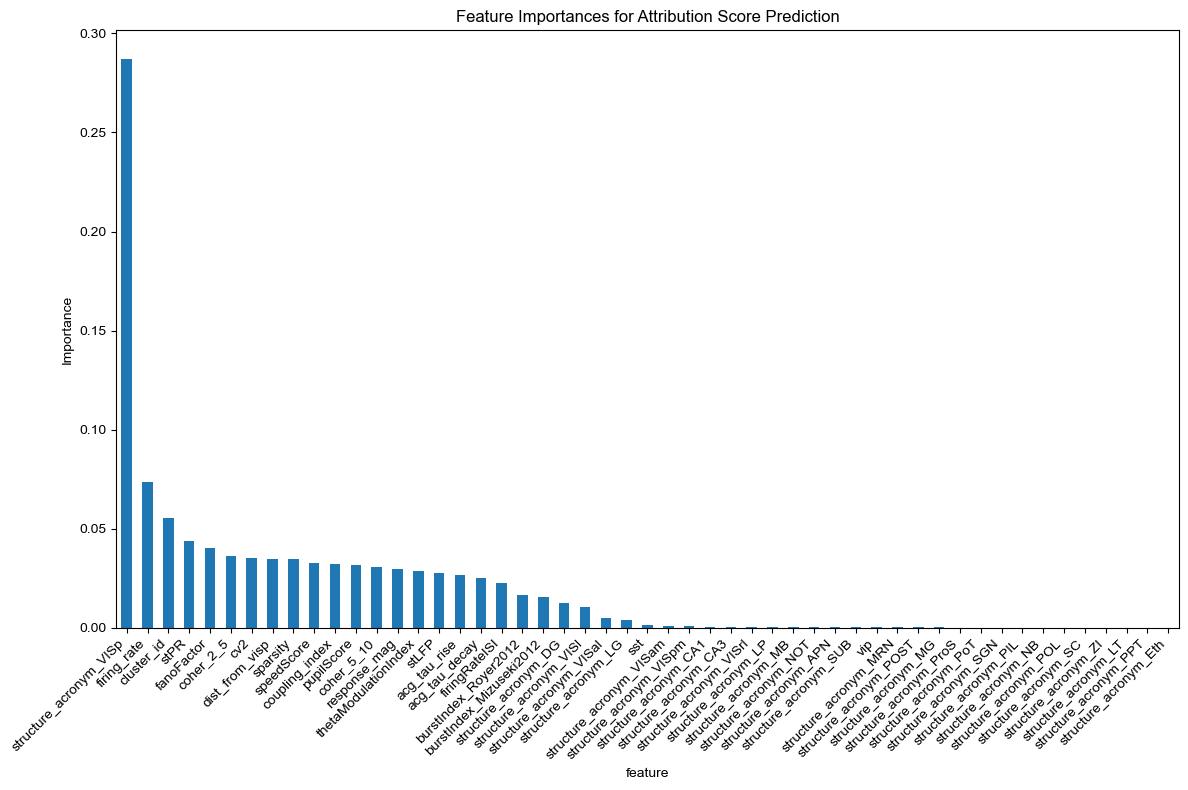

In [21]:
# regressor = DecisionTreeRegressor()
rf_model.fit(X_train, y_train)

# Evaluate the model
y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f'R^2 score of the regressor: {r2:.4f}')

# Get feature importances
importances = rf_model.feature_importances_
# Create a DataFrame for feature importances, remember to remove the area columns that were not kept
feature_names = encoder.get_feature_names_out(['structure_acronym']).tolist()
feature_names = [feature_names[i] for i in area_indices_to_keep] + metrics + ['cluster_id','sst', 'vip']
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Plot feature importances
fig, ax = plt.subplots(figsize=(12, 8))
importance_df.plot(kind='bar', x='feature', y='importance', ax=ax, legend=False)
ax.set_title('Feature Importances for Attribution Score Prediction')
ax.set_ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# plt.savefig(Path(figures_folder) / 'feature_importances_attribution_score_prediction_all.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

## Repeat the above process for each channel and band 


In [52]:
import tqdm

r2_df = pd.DataFrame(index=range(chans2keep), columns=[f'model_fit_{bandi}' for bandi in range(len(bands)+1)])

encoder = OneHotEncoder(sparse_output=False)
structure_encoded = encoder.fit_transform(df[['structure_acronym']])
feature_names = encoder.get_feature_names_out(['structure_acronym']) \
    .tolist() + metrics + ['cluster_id','sst', 'vip'] 
importance_df = pd.DataFrame({
    'feature': feature_names})

structure_encoded = encoder.fit_transform(df[['structure_acronym']])

X = np.hstack([structure_encoded, df[metrics + ['cluster_id','sst', 'vip']].values])
X[np.isinf(X)] = np.nan

for bandi in tqdm.tqdm(range(len(bands)+1), desc='Processing Bands'):
    for chani in range(chans2keep):
        # get the attribution scores for the channel and band
        y = df[f'attr_{chani}_{bandi}'].values
        
        # Remove rows with nan in y
        valid_mask = (~np.isnan(X).any(axis=1)) & (~np.isnan(y)) & (~np.isinf(y))
        y_clean = y[valid_mask]
        X_clean = X[valid_mask]
        
        X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)
        # study.optimize(objective, n_trials=20)
        # rf_model = RandomForestRegressor(
        #     n_estimators=study.best_params['n_estimators'],
        #     max_depth=study.best_params['max_depth'],
        #     n_jobs=-1
        # )
        rf_model = RandomForestRegressor(n_estimators=200, max_depth=19, n_jobs=-1)
        rf_model.fit(X_train, y_train)
        # Evaluate the model
        y_pred = rf_model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        importances = rf_model.feature_importances_
        importance_df[f'importance_{chani}_{bandi}'] = importances
        r2_df.at[chani, f'model_fit_{bandi}'] = r2


Processing Bands: 100%|██████████| 9/9 [2:00:58<00:00, 806.54s/it]


## Plot the r2 scores of all channels and bands in a heatmap


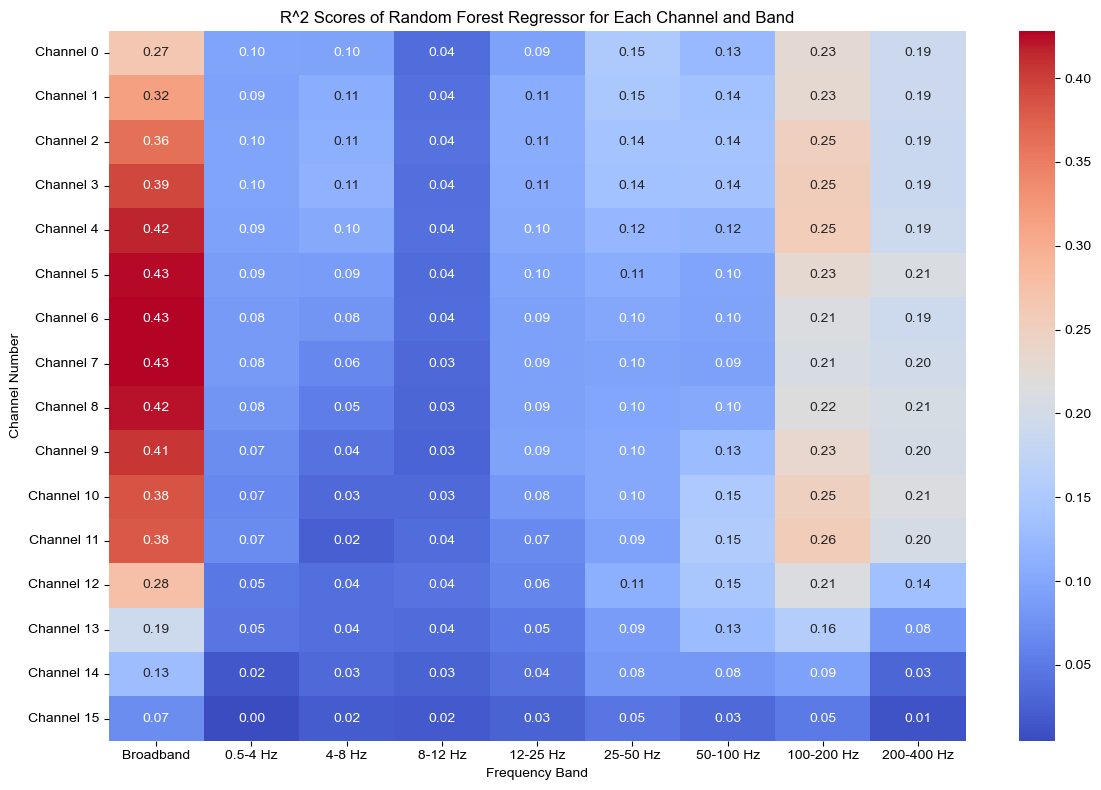

In [53]:
fig, ax = plt.subplots(figsize=(12, 8))
heatmap_data = r2_df.astype(float).values  # Convert to float
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap='coolwarm', ax=ax,
           xticklabels=['Broadband'] + [f'{band[0]}-{band[1]} Hz' for band in bands] ,
           yticklabels=[f'Channel {i}' for i in range(chans2keep)])
ax.set_title('R^2 Scores of Random Forest Regressor for Each Channel and Band')
ax.set_xlabel('Frequency Band') 
ax.set_ylabel('Channel Number')
plt.tight_layout()
plt.show()

## Loop through the bands and plot the feature importances for all channels using a heatmap


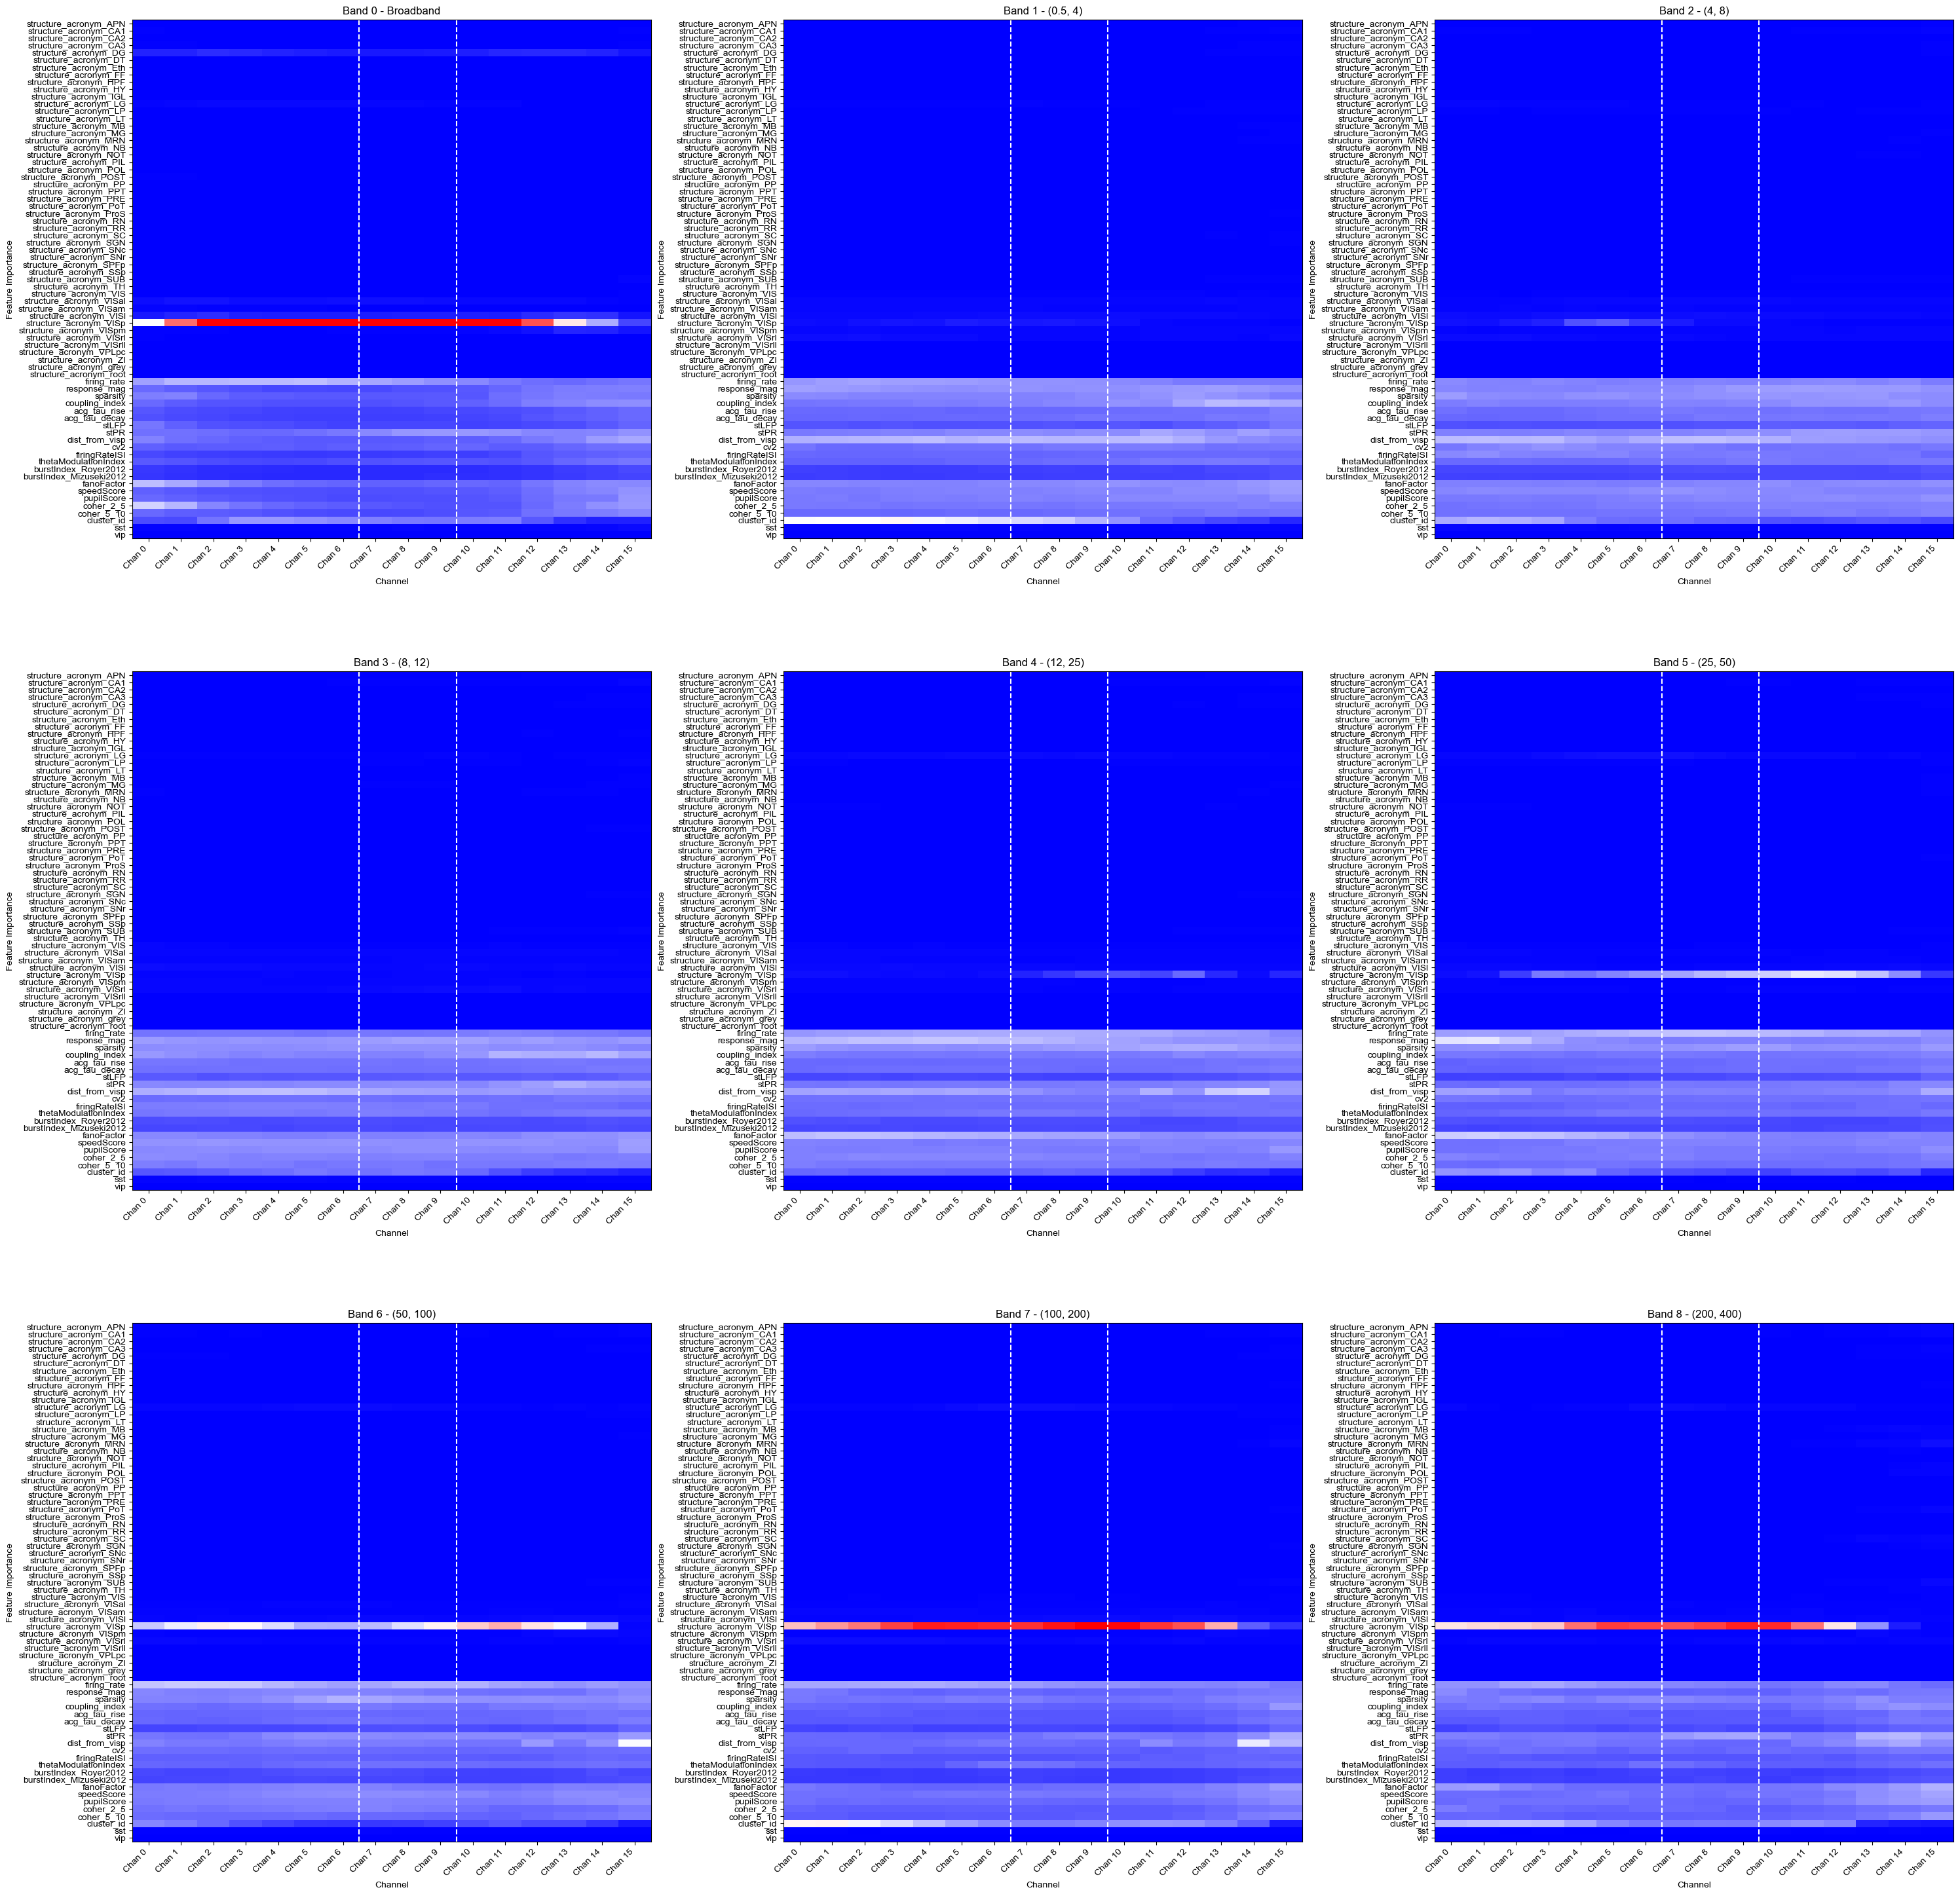

In [54]:
fig, ax = plt.subplots(3,3, figsize=(30, 30))

for bandi in range(len(bands)+1):
    data = importance_df[[f'importance_{chani}_{bandi}' for chani in range(chans2keep)]].values
    ax.flat[bandi].imshow(data, aspect='auto', cmap='bwr', vmin = 0, vmax=.2)
    ax.flat[bandi].set_xticks(range(chans2keep))
    ax.flat[bandi].set_xticklabels([f'Chan {i}' for i in range(chans2keep)], rotation=45, ha='right')
    ax.flat[bandi].set_yticks(range(len(feature_names)))
    ax.flat[bandi].set_yticklabels(feature_names)
    ax.flat[bandi].set_title(f'Band {bandi} - {bands[bandi-1] if bandi > 0 else "Broadband"}')
    ax.flat[bandi].set_ylabel('Feature Importance')
    ax.flat[bandi].set_xlabel('Channel')
    ax.flat[bandi].set_aspect(1.0/ax.flat[bandi].get_data_ratio(), adjustable='box')
    ax.flat[bandi].axvline(x=6.5, color='w', linestyle='--')
    ax.flat[bandi].axvline(x=9.5, color='w', linestyle='--')

    
plt.tight_layout()
plt.show()

In [ ]:
# # plot a few seconds of raw LFP/ power and model prediction for an example session and channel
# from process_session import session as ps
# from preprocess_data import *
# import models as models

# output_dir  = Path(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022')

# session_id  = 1044385384
# session_obj = ps(session_id, df, output_dir)
# bands = [(0.5, 4), (4, 8), (8, 12), (12, 25), (25, 50), (50, 100), (100, 200), (200, 400)]
# input_size = len(session_obj.units)

# # hyperparameters
# hidden_size = 50 
# num_layers = 1
# seqlength = 750
# bin_size = 0.004

In [ ]:
# # spikes_obj_active = pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=bin_size)
# # spikes_obj_active.getSpkMat(session_obj.active_times[0], session_obj.active_times[1]) 
# # spikes_obj_active.minmax()

# lfp_obj_active = pre_process_lfp(session_id, session_obj.channels, session_obj.active_times[0],
#                         session_obj.active_times[1], output_dir)
# # lfp_obj_active.filter_lfp(take_power = True)
# # lfp_obj_active.downsample_lfp(5)
# # lfp_obj_active.truncate(seqlength)
# # lfp_obj_active.align_lfp(spikes_obj_active.spkMat.shape[0])

# first_chan = borders[borders['session']==session_id]['first_channel_index'].values[0]
# last_chan = borders[borders['session']==session_id]['last_channel_index'].values[0]
# lfp_obj_active.data = lfp_obj_active.data[:, first_chan:last_chan+1]

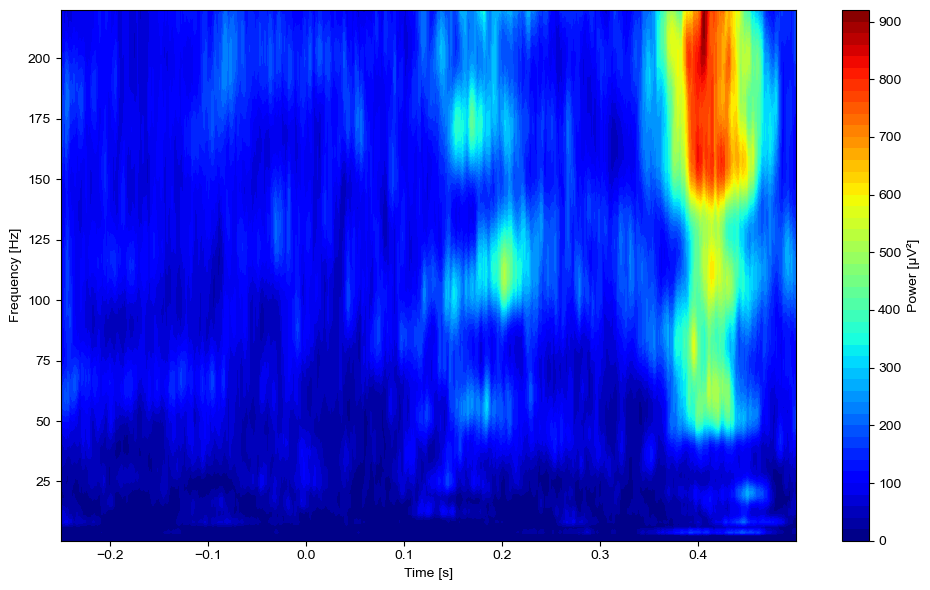

In [ ]:
# stim_st = session_obj.stimulus_presentation[session_obj.stimulus_presentation['omitted'] == False].start_time
# stim_st = stim_st[(stim_st > session_obj.active_times[0]) & (stim_st < session_obj.active_times[1])]
# stim_st = stim_st.values
# # randomly select 300 stimulus presentations to speed up the analysis
# stim_st = np.random.choice(stim_st, size=300, replace=False)

# time_win = [-0.25, 0.5]
# fs = 1250
# bin_size = 1/fs

# snippets = np.zeros((len(stim_st), int((time_win[1] - time_win[0]+bin_size) / bin_size), lfp_obj_active.data.shape[1])) # stim x time x channels
# t = np.arange(time_win[0], time_win[1], bin_size)
# for i, st in enumerate(stim_st):
#     start_idx = int((st + time_win[0] - session_obj.active_times[0]) / bin_size)
#     end_idx = start_idx + snippets.shape[1]
#     if start_idx >= 0 and end_idx <= lfp_obj_active.data.shape[0]:
#         snippets[i, :, :] = lfp_obj_active.data[start_idx:end_idx, :]

# snippets = snippets * 1e6 # convert to microvolts
# # permute to be time x stim x channels for the wavelet analysis
# snippets = np.transpose(snippets, (1, 0, 2)) # time x stim x channels
# from spectral_analysis import wavelet_power
# tf, tf_all, itpc, frex = wavelet_power(snippets, t)


In [ ]:
# # select only the 16 channels that are in the borders table
# power_data = lfp_obj_active.lfpMat.copy() # shape is channels x time
# first_chan = borders[borders['session']==session_id]['first_channel_index'].values[0]
# last_chan = borders[borders['session']==session_id]['last_channel_index'].values[0]
# power_data = power_data[:,first_chan:last_chan+1,1:] # time, channels, bands

# time_win = [-0.25, 0.5]
# bin_size = 0.004
# # for each of the 8 bands, get the peri-stimulus average power around the stimulus
# power_psth = np.zeros((len(stim_st),len(bands),chans2keep , int((time_win[1] - time_win[0]) / bin_size))) # events x bands x channel x time
# t = np.arange(time_win[0], time_win[1], bin_size)
# for i, st in enumerate(stim_st):
#     st_idx = int((st - session_obj.active_times[0]) / bin_size)
#     if st_idx + int(time_win[1]/bin_size) >= power_data.shape[0] or st_idx + int(time_win[0]/bin_size) < 0:
#         continue
#     for bandi, band in enumerate(bands):
#         power_psth[i,bandi,:,:] = power_data[st_idx + int(time_win[0]/bin_size) : st_idx + int(time_win[1]/bin_size), :, bandi].T
        

# print(f"Power PSTH shape: {power_psth.shape}, Time vector shape: {t.shape}")

In [ ]:
# time_points = [0.04, 0.15, 0.3, 0.375]
# time_indices = [int((tp - time_win[0]) / bin_size) for tp in time_points]

# # plot the power_psth for each band across channels for the selected time points
# # channels on the y axis and power on the x axis, with a different subplot for each time point and different lines for each band
# fig, ax = plt.subplots(1, len(time_points), figsize=(15, 10))
# for i, time_idx in enumerate(time_indices):
#     for bandi in range(len(bands)):
#         band_mean = np.mean(power_psth[:,bandi, :, time_idx], axis=0)
#         band_sem = np.std(power_psth[:,bandi, :, time_idx], axis=0) / np.sqrt(power_psth.shape[0])
#         y = np.arange(chans2keep)
#         ax[i].plot(gaussian_filter1d(band_mean, sigma=1), y, label=f'Band {bands[bandi][0]}-{bands[bandi][1]} Hz')
#         ax[i].fill_betweenx(y, 
#                             gaussian_filter1d(band_mean - band_sem, sigma=1), 
#                             gaussian_filter1d(band_mean + band_sem, sigma=1), 
#                             alpha=0.3)
#     ax[i].set_title(f'Time = {time_points[i]:.3f} s')
#     ax[i].set_xlabel('Power')
#     ax[i].set_ylabel('Channel')
# ax[0].legend()
# plt.tight_layout()
# # plt.savefig(Path(figures_folder) / f'power_psth_across_channels_at_time_points.pdf', format='pdf', dpi=300, bbox_inches='tight')
# plt.show()

In [ ]:
# chani = 6

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# criterion = torch.nn.MSELoss()

# yHat = np.zeros((lfp_obj_active.lfpMat.shape[0], len(bands)+1))

# for bandi in range(len(bands)+1):
#     model = models.process_model(models.LSTMnet(input_size, hidden_size, num_layers,seqlength), criterion, device)
#     model_weights_dir = Path(output_dir / 'spikes2lfp' / 'models' / str(session_id) / f'lstm_model_chan{chani}_band{bandi}.pt')
#     model.model.load_state_dict(torch.load(model_weights_dir))
#     model.model.to(device)
#     yHat[:, bandi] = model.evaluate(torch.tensor(spikes_obj_active.spkMat).float().to(device)).cpu().detach().numpy()


In [ ]:
# fig, ax = plt.subplots(int(np.ceil((len(bands)+1)/2)),2, figsize=(16, 16))
# time = spikes_obj_active.timestamps - spikes_obj_active.timestamps[0]
# for bandi in range(len(bands)+1):
#     ax.flat[bandi].plot(time, lfp_obj_active.lfpMat[:,chani, bandi], label='Actual', color='black')
#     ax.flat[bandi].plot(time, yHat[:, bandi], label='Predicted', color='red', linestyle='--')
#     ax.flat[bandi].set_title(f'Channel {chani} - ' + (f'Broadband' if bandi==0 else f'Band {bands[bandi-1]} Hz'))
#     ax.flat[bandi].set_xlabel('Time (s)')
#     ax.flat[bandi].set_ylabel('LFP Amplitude [z-score]' if bandi==0 else 'LFP Power [z-score]')
#     ax.flat[bandi].legend()
#     ax.flat[bandi].set_xlim(time[0]+.5, time[0]+5.5)
#     ax.flat[bandi].set_xticks(np.arange(time[0]+.5, time[0]+6))
#     ax.flat[bandi].set_xticklabels([f'{x:.1f}' for x in np.arange(time[0], time[0]+6)])
# fig.delaxes(ax.flat[-1])
# plt.tight_layout()
# plt.show()

# plt.savefig(Path(figures_folder) / f'lfp_vs_model_prediction_session_{session_id}_channel_{chani}.pdf', format='pdf', dpi=300, bbox_inches='tight')

In [84]:
# Define paths
downsampling_results_dir = Path(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\spikes2lfp\downsampling_results')
figures_folder = Path(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\spikes2lfp\figures')

# Find all downsampling result files
result_files = sorted(downsampling_results_dir.glob('*_attribution_firing_rate_resampling_results.npy'))
print(f"Found {len(result_files)} downsampling result files")

# Dictionary to store aggregated results across all sessions
all_sessions_results = {}
all_sessions_summary = []

# Process each file
for result_file in result_files:
    session_id = result_file.stem.split('_')[0]
    print(f"Processing session {session_id}...")
    
    try:
        res = np.load(result_file, allow_pickle=True).item()
        
        # Extract key data
        original_attr = res['original_attributions']
        top_neuron_areas = res['top_neuron_areas']
        downsampled_attr = res['downsampled_attributions']
        area_avg = res['area_population_attributions']
        
        n_neurons = len(original_attr)
        results_summary = []
        
        # Analyze each neuron
        for neuron_idx in range(n_neurons):
            area = top_neuron_areas[neuron_idx]
            area_mean = area_avg[area]
            downsampled_dist = np.array(downsampled_attr[neuron_idx])
            
            mean_downsampled = np.mean(downsampled_dist)
            std_downsampled = np.std(downsampled_dist)
            sem_downsampled = std_downsampled / np.sqrt(len(downsampled_dist))
            
            original = original_attr[neuron_idx]
            
            # Statistical test
            t_stat, p_val = stats.ttest_1samp(downsampled_dist, area_mean)
            
            # Cohen's d with improved handling of edge cases
            # 1. Add a minimum threshold for std to avoid near-zero division
            # 2. Cap extreme values
            min_std_threshold = np.percentile(np.abs(downsampled_dist - area_mean), 5) + 1e-8
            std_for_cohens = max(std_downsampled, min_std_threshold)
            
            cohens_d = (mean_downsampled - area_mean) / std_for_cohens
            
            # Cap outlier effect sizes (optional but recommended)
            cohens_d = np.clip(cohens_d, -5, 5)  # Reasonable bounds for Cohen's d
            
            results_summary.append({
                'session_id': int(session_id),
                'neuron_idx': neuron_idx,
                'area': area,
                'original_attribution': original,
                'area_average': area_mean,
                'mean_downsampled': mean_downsampled,
                'std_downsampled': std_downsampled,
                'sem_downsampled': sem_downsampled,
                't_statistic': t_stat,
                'p_value': p_val,
                'cohens_d': cohens_d,  # Now bounded
                'percent_change': ((original - area_mean) / (area_mean + 1e-10)) * 100,
                'significant': p_val < 0.05
            })
        
        results_df = pd.DataFrame(results_summary)
        all_sessions_results[int(session_id)] = results_df
        
        # Session-level summary
        session_summary = {
            'session_id': int(session_id),
            'n_neurons_analyzed': n_neurons,
            'n_significant_neurons': (results_df['p_value'] < 0.05).sum(),
            'percent_significant': (results_df['p_value'] < 0.05).sum() / n_neurons * 100,
            'mean_original_attr': results_df['original_attribution'].mean(),
            'mean_downsampled_attr': results_df['mean_downsampled'].mean(),
            'mean_cohens_d': results_df['cohens_d'].mean(),
            'mean_p_value': results_df['p_value'].mean(),
            'n_positive_effect': (results_df['cohens_d'] > 0).sum(),
            'n_negative_effect': (results_df['cohens_d'] < 0).sum()
        }
        all_sessions_summary.append(session_summary)
        
    except Exception as e:
        print(f"  Error processing {session_id}: {str(e)}")

# Create summary dataframe
summary_df = pd.DataFrame(all_sessions_summary)
summary_df.to_csv(downsampling_results_dir / 'all_sessions_summary.csv', index=False)
print(f"\nProcessed {len(all_sessions_results)} sessions successfully")

# Concatenate all neurons across sessions
all_neurons_df = pd.concat(all_sessions_results.values(), ignore_index=True)
all_neurons_df.to_csv(downsampling_results_dir / 'all_neurons_across_sessions.csv', index=False)

print(f"Total neurons analyzed: {len(all_neurons_df)}")
print(f"Total neurons with significant effect (p<0.05): {(all_neurons_df['p_value'] < 0.05).sum()}")
print(f"Overall percent significant: {(all_neurons_df['p_value'] < 0.05).sum() / len(all_neurons_df) * 100:.1f}%")

Found 89 downsampling result files
Processing session 1044385384...
Processing session 1044594870...
Processing session 1047969464...
Processing session 1047977240...
Processing session 1048189115...
Processing session 1048196054...
Processing session 1049273528...
Processing session 1049514117...
Processing session 1051155866...
Processing session 1052342277...
Processing session 1052533639...
Processing session 1053709239...
Processing session 1053718935...
Processing session 1053925378...
Processing session 1053941483...
Processing session 1055221968...
Processing session 1055240613...
Processing session 1055403683...
Processing session 1055415082...
Processing session 1062755779...
Processing session 1063010385...
Processing session 1064400234...
Processing session 1064415305...
Processing session 1064639378...
Processing session 1064644573...
Processing session 1065437523...
Processing session 1065449881...
Processing session 1065905010...
Processing session 1065908084...
Processi

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

downsampling_results_dir = Path(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\spikes2lfp\downsampling_results')
figures_folder = Path(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\spikes2lfp\figures')

# Load summary data
summary_df = pd.read_csv(downsampling_results_dir / 'all_sessions_summary.csv')
all_neurons_df = pd.read_csv(downsampling_results_dir / 'all_neurons_across_sessions.csv')

# Filter out areas that are in areas2remove
print(f"Original number of neurons: {len(all_neurons_df)}")
all_neurons_df = all_neurons_df[~all_neurons_df['area'].isin(areas2remove)]
print(f"Number of neurons after filtering areas2remove: {len(all_neurons_df)}")

# Create comprehensive PDF with multiple pages
pdf_path = figures_folder / 'batch_downsampling_analysis.pdf'
with PdfPages(pdf_path) as pdf:
    
    # PAGE 1: Session-level overview
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    ax = axes[0, 0]
    ax.bar(range(len(summary_df)), summary_df['n_neurons_analyzed'], color='steelblue', alpha=0.7)
    ax.set_xlabel('Session Index')
    ax.set_ylabel('Number of Neurons Analyzed')
    ax.set_title('Neurons Analyzed per Session')
    ax.grid(axis='y', alpha=0.3)
    
    ax = axes[0, 1]
    ax.bar(range(len(summary_df)), summary_df['percent_significant'], color='coral', alpha=0.7)
    ax.axhline(50, color='r', linestyle='--', label='50% baseline')
    ax.set_xlabel('Session Index')
    ax.set_ylabel('% Neurons with Significant Effect')
    ax.set_title('Significance Rate by Session')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    ax = axes[1, 0]
    ax.plot(range(len(summary_df)), summary_df['mean_original_attr'], 'o-', label='Original Attribution', linewidth=2)
    ax.plot(range(len(summary_df)), summary_df['mean_downsampled_attr'], 's-', label='Downsampled Attribution', linewidth=2)
    ax.set_xlabel('Session Index')
    ax.set_ylabel('Mean Attribution Score')
    ax.set_title('Attribution Before and After Firing Rate Matching')
    ax.legend()
    ax.grid(alpha=0.3)
    
    ax = axes[1, 1]
    ax.scatter(summary_df['mean_original_attr'], summary_df['percent_significant'], s=100, alpha=0.6)
    ax.set_xlabel('Mean Original Attribution')
    ax.set_ylabel('% Significant Neurons')
    ax.set_title('Correlation: Attribution Level vs Significance')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()
    
    # PAGE 2: Effect size distribution across all neurons
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    # Filter extreme values for visualization
    cohens_d_filtered = all_neurons_df['cohens_d'][(all_neurons_df['cohens_d'] > -5) & (all_neurons_df['cohens_d'] < 5)]
    ax.hist(cohens_d_filtered, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    ax.axvline(0, color='r', linestyle='--', linewidth=2, label='No Effect')
    ax.axvline(all_neurons_df['cohens_d'].mean(), color='g', linestyle='--', linewidth=2, 
            label=f'Mean: {all_neurons_df["cohens_d"].mean():.3f}')
    ax.set_xlabel("Cohen's d")
    ax.set_ylabel('Number of Neurons')
    ax.set_title('Distribution of Effect Sizes (All Neurons)')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    # Add text noting filtered range
    ax.text(0.98, 0.97, f'n={len(cohens_d_filtered)}/{len(all_neurons_df)} shown\n(range: ±5)', 
            transform=ax.transAxes, ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    ax = axes[1]
    # P-value distribution (log scale) - FIXED: Filter out inf values
    log_pvals = -np.log10(all_neurons_df['p_value'])
    # Remove infinite values (caused by p-value = 0)
    log_pvals_finite = log_pvals[np.isfinite(log_pvals)]

    ax.hist(log_pvals_finite, bins=30, color='coral', alpha=0.7, edgecolor='black')
    ax.axvline(-np.log10(0.05), color='r', linestyle='--', linewidth=2, label='p=0.05 threshold')
    ax.set_xlabel('-log10(p-value)')
    ax.set_ylabel('Number of Neurons')
    ax.set_title('Statistical Significance Distribution')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()
    
    # PAGE 3: Brain area comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    ax = axes[0]
    area_stats = all_neurons_df.groupby('area').agg({
        'cohens_d': 'mean',
        'p_value': lambda x: (x < 0.05).sum() / len(x) * 100
    }).sort_values('cohens_d', ascending=False)
    
    area_stats['cohens_d'].plot(kind='barh', ax=ax, color='steelblue', alpha=0.7)
    ax.set_xlabel("Mean Cohen's d")
    ax.set_title('Effect Size by Brain Area (Filtered)')
    ax.grid(axis='x', alpha=0.3)
    
    ax = axes[1]
    area_stats['p_value'].plot(kind='barh', ax=ax, color='coral', alpha=0.7)
    ax.set_xlabel('% Neurons with Significant Effect (p<0.05)')
    ax.set_title('Significance Rate by Brain Area (Filtered)')
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()
    
    # PAGE 4: Correlation between original and downsampled attributions
    fig, ax = plt.subplots(figsize=(10, 8))
    
    scatter = ax.scatter(all_neurons_df['original_attribution'], 
                        all_neurons_df['mean_downsampled'], 
                        c=all_neurons_df['p_value'],
                        cmap='RdYlGn_r', alpha=0.6, s=50, vmin=0, vmax=0.05)
    
    # Add unity line
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),
        np.max([ax.get_xlim(), ax.get_ylim()]),
    ]
    ax.plot(lims, lims, 'k--', alpha=0.5, zorder=0, label='Unity line')
    
    ax.set_xlabel('Original Attribution Score')
    ax.set_ylabel('Mean Downsampled Attribution Score')
    ax.set_title('Attribution Before vs After Firing Rate Matching')
    ax.set_aspect('equal')
    
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('p-value', rotation=270, labelpad=20)
    
    ax.legend()
    
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()
    
    
    # PAGE 5: Distribution of high-contributing neurons across brain areas
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Define thresholds for high contributors
    top_percentiles = [90, 95, 99]
    colors = ['lightblue', 'orange', 'red']

    # Subplot 1: Stacked bar chart showing top contributors by area
    ax = axes[0, 0]
    area_counts = all_neurons_df['area'].value_counts()
    top_contributor_counts = {}

    for i, percentile in enumerate(top_percentiles):
        threshold = np.percentile(all_neurons_df['original_attribution'], percentile)
        top_mask = all_neurons_df['original_attribution'] >= threshold
        top_contributors = all_neurons_df[top_mask]['area'].value_counts()
        
        # Align with all areas (fill missing with 0)
        top_contributor_counts[percentile] = area_counts.index.map(
            lambda x: top_contributors.get(x, 0)
        )

    # Calculate total high contributors per area and filter out areas with zero
    total_high_contributors = np.sum([top_contributor_counts[p] for p in top_percentiles], axis=0)
    areas_with_contributors_mask = total_high_contributors > 0
    filtered_areas = area_counts.index[areas_with_contributors_mask]
    filtered_totals = total_high_contributors[areas_with_contributors_mask]

    # Sort areas by total number of high contributors (descending)
    sort_indices = np.argsort(filtered_totals)[::-1]
    sorted_areas = filtered_areas[sort_indices]

    # Create stacked bar chart with filtered and sorted data
    bottom = np.zeros(len(sorted_areas))
    for i, percentile in enumerate(top_percentiles):
        # Get counts for sorted areas only
        sorted_counts = [top_contributor_counts[percentile][area_counts.index.get_loc(area)] 
                        for area in sorted_areas]
        ax.bar(range(len(sorted_areas)), sorted_counts, 
            bottom=bottom, label=f'Top {100-percentile}%', color=colors[i], alpha=0.7)
        bottom += sorted_counts

    ax.set_xticks(range(len(sorted_areas)))
    ax.set_xticklabels(sorted_areas, rotation=45, ha='right')
    ax.set_ylabel('Number of High-Contributing Neurons')
    ax.set_title('Distribution of High-Contributing Neurons by Brain Area (Filtered & Sorted)')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    # Subplot 3: Distribution of original attribution by area (violin plot)
    ax = axes[1, 0]
    # Filter areas with sufficient neurons for meaningful violin plots
    min_neurons_per_area = 20
    areas_with_enough_neurons = area_counts[area_counts >= min_neurons_per_area].index.tolist()

    violin_data = []
    violin_labels = []
    for area in areas_with_enough_neurons:
        area_attr = all_neurons_df[all_neurons_df['area'] == area]['original_attribution'].values
        if len(area_attr) > 0:
            violin_data.append(area_attr)
            violin_labels.append(f"{area}\n(n={len(area_attr)})")

    if violin_data:
        parts = ax.violinplot(violin_data, positions=range(len(violin_data)), 
                            showmeans=True, showmedians=True)
        
        # Color the violins
        for pc, color in zip(parts['bodies'], plt.cm.Set3(np.linspace(0, 1, len(violin_data)))):
            pc.set_facecolor(color)
            pc.set_alpha(0.7)
        
        ax.set_xticks(range(len(violin_labels)))
        ax.set_xticklabels(violin_labels, rotation=45, ha='right')
        ax.set_ylabel('Original Attribution Score')
        ax.set_title('Attribution Score Distributions by Brain Area (Filtered)')
        ax.grid(axis='y', alpha=0.3)

    # Subplot 4: Effect size (Cohen's d) vs. original attribution colored by area
    ax = axes[1, 1]
    # Get unique areas and assign colors (now filtered)
    unique_areas = all_neurons_df['area'].unique()
    area_colors = plt.cm.tab20(np.linspace(0, 1, len(unique_areas)))
    area_color_map = dict(zip(unique_areas, area_colors))

    for area in unique_areas:
        area_mask = all_neurons_df['area'] == area
        if area_mask.sum() > 10:  # Only plot areas with sufficient data
            ax.scatter(all_neurons_df[area_mask]['original_attribution'], 
                    all_neurons_df[area_mask]['cohens_d'],
                    c=[area_color_map[area]], label=area, alpha=0.6, s=30)

    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Original Attribution Score')
    ax.set_ylabel("Cohen's d (Effect Size)")
    ax.set_title('Effect Size vs Original Attribution by Brain Area (Filtered)')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

print(f"PDF saved to: {pdf_path}")

# Print summary statistics (now filtered)
print("\n" + "="*60)
print("BATCH DOWNSAMPLING ANALYSIS SUMMARY (FILTERED)")
print("="*60)
print(f"\nTotal sessions: {len(summary_df)}")
print(f"Total neurons (after filtering areas2remove): {len(all_neurons_df)}")
print(f"Areas removed: {areas2remove}")
print(f"Remaining areas: {sorted(all_neurons_df['area'].unique().tolist())}")

print(f"\nSignificance Statistics:")
print(f"  Neurons with p < 0.05: {(all_neurons_df['p_value'] < 0.05).sum()} ({(all_neurons_df['p_value'] < 0.05).sum()/len(all_neurons_df)*100:.1f}%)")
print(f"  Mean p-value: {all_neurons_df['p_value'].mean():.2e}")
print(f"  Median p-value: {all_neurons_df['p_value'].median():.2e}")

print(f"\nEffect Size Statistics:")
print(f"  Mean Cohen's d: {all_neurons_df['cohens_d'].mean():.3f}")
print(f"  Std Cohen's d: {all_neurons_df['cohens_d'].std():.3f}")
print(f"  Neurons with positive effect (d > 0): {(all_neurons_df['cohens_d'] > 0).sum()}")
print(f"  Neurons with negative effect (d < 0): {(all_neurons_df['cohens_d'] < 0).sum()}")

print(f"\nAttribution Changes:")
print(f"  Mean original attribution: {all_neurons_df['original_attribution'].mean():.2e}")
print(f"  Mean downsampled attribution: {all_neurons_df['mean_downsampled'].mean():.2e}")
print(f"  Mean percent change: {all_neurons_df['percent_change'].mean():.1f}%")

Original number of neurons: 890
Number of neurons after filtering areas2remove: 848
PDF saved to: Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\spikes2lfp\figures\batch_downsampling_analysis.pdf

BATCH DOWNSAMPLING ANALYSIS SUMMARY (FILTERED)

Total sessions: 89
Total neurons (after filtering areas2remove): 848
Areas removed: ['root', 'CA2', 'RR', 'VISrll', 'RN', 'FF', 'grey', 'PRE', 'HY', 'IGL', 'DT', 'SSp', 'VPLpc', 'SPFp', 'HPF', 'VIS', 'SNr', 'SNc', 'PP', 'TH']
Remaining areas: ['APN', 'CA1', 'CA3', 'DG', 'Eth', 'LG', 'LP', 'LT', 'MB', 'MG', 'MRN', 'NB', 'NOT', 'PIL', 'POL', 'POST', 'PPT', 'PoT', 'ProS', 'SCig', 'SCiw', 'SGN', 'SUB', 'VISal', 'VISam', 'VISl', 'VISp', 'VISpm', 'VISrl', 'ZI']

Significance Statistics:
  Neurons with p < 0.05: 846 (99.8%)
  Mean p-value: 6.30e-05
  Median p-value: 3.14e-14

Effect Size Statistics:
  Mean Cohen's d: 1.554
  Std Cohen's d: 0.433
  Neurons with positive effect (d > 0): 846
  Neurons with negative effect (d < 0)